# Multiphase n-point statistical descriptors

Tests how the standard n-point statistical descriptors (S₂, lineal path L,
pore-size F, chord length, cluster C₂) discriminate microstructures across
samples and across **multiple mineral phases**.  Generalizes the original
quartz-only notebook (`npcf_quartz_kmz.ipynb`) so any phase declared in
the EBSD scan can be the target — useful for polymineralic aggregates
(feldspar mylonite, eclogite, peridotite, etc.) where multiple phases
carry deformation signal, or for samples that have no quartz at all.

**Usage**:
- Load datasets via the interactive picker.
- Set `TARGET_PHASE_NAME` to substring-match the phase you want to analyze
  (e.g. `'quartz'`, `'albite'`, `'forsterite'`, `'biotite'`).
- All downstream n-point cells consume `samples[tag]['target_mask']`
  exactly as the quartz notebook used `quartz_mask`.

**Per-phase loop**: for samples with multiple declared phases, loop
`TARGET_PHASE_NAME` across all phase names and re-run the n-point cells
to get per-phase descriptors for the same sample.

**Cross-phase 2-point correlation** (`S_AB(r) = Pr(point at x is A AND
x+r is B)`): see the dedicated cell at the bottom for feldspar-quartz,
mica-quartz, etc. interface analysis.

**Key diagnostic** (preserved from quartz notebook): the **C₂/S₂ ratio**
quantifies how much of the target phase is connected at scale *r*:
- C₂/S₂ → 1 at all r: target phase forms a single connected framework.
- C₂/S₂ drops at large r: target phase is fragmented into disconnected
  islands.

*Kernel*: `xsmurf` (porespy, numpy, scipy, scikit-image, numba, mlx).


In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import porespy as ps
from pathlib import Path
from scipy.fft import fft2, ifft2
from scipy.ndimage import label as _ndi_label
print('porespy', ps.__version__, ' numpy', np.__version__)

porespy 3.0.4  numpy 2.4.3


## EBSD reader

Copied inline so the notebook is self-contained in the xsmurf env
(doesn't require recurrence2d to be importable here).

In [2]:
import re as _re
import pandas as pd

# --- CPR/CRC binary reader (Oxford Instruments Channel 5 format) ---
_CPR_FIELDS = {
    3: ('ph1', 'float32'), 4: ('phi', 'float32'), 5: ('ph2', 'float32'),
    6: ('MAD', 'float32'), 7: ('BC', 'uint8'), 8: ('BS', 'uint8'),
    10: ('numBands', 'uint8'), 11: ('AFI', 'uint8'), 12: ('IB6', 'float32'),
}

def _parse_cpr_ini(cpr_path):
    text = Path(cpr_path).read_text(errors='replace')
    groups = {}; current = None
    group_re = _re.compile(r'^\[(.+)\]\s*$')
    for line in text.splitlines():
        line = line.strip()
        if not line or line.startswith(';'): continue
        m = group_re.match(line)
        if m:
            current = m.group(1); groups.setdefault(current, {}); continue
        if current is None: continue
        if '=' in line:
            k, v = line.split('=', 1); groups[current][k.strip()] = v.strip()
    return groups

def read_cpr(filepath):
    filepath = Path(filepath)
    cpr = filepath.with_suffix('.cpr'); crc = filepath.with_suffix('.crc')
    g = _parse_cpr_ini(cpr)
    job = g.get('Job', {})
    nx, ny = int(job['xCells']), int(job['yCells'])
    xstep = float(job.get('GridDistX', 1.0))
    ystep = float(job.get('GridDistY', xstep))
    pg = g.get('Phases', {}); n_phases = int(pg.get('Count', 0))
    phases = {}
    for i in range(1, n_phases + 1):
        pi = g.get(f'Phase{i}', {})
        phases[i] = [f"{pi.get('a','?')};{pi.get('b','?')};{pi.get('c','?')}",
                     f"{pi.get('alpha','?')};{pi.get('beta','?')};{pi.get('gamma','?')}",
                     pi.get('StructureName', f'phase_{i}'),
                     pi.get('LaueGroup', '?'), pi.get('SpaceGroup', '?')]
    fg = g.get('Fields', {}); n_fields = int(fg.get('Count', 0))
    dtype_items = [('phase', 'uint8')]
    for i in range(1, n_fields + 1):
        cd = int(fg[f'Field{i}'])
        dtype_items.append(_CPR_FIELDS.get(cd, (f'unknown_{cd}', 'float32')))
    raw = np.fromfile(str(crc), dtype=np.dtype(dtype_items), count=nx*ny)
    if raw.size != nx*ny: raw = raw[:nx*ny]
    shape = (ny, nx)
    data = {'meta': {'name': filepath.stem, 'xcells': nx, 'ycells': ny,
                      'xstep': xstep, 'ystep': ystep,
                      'phases': phases, 'n_phases': n_phases},
            'phase': raw['phase'].reshape(shape)}
    for src, dst in [('ph1','euler1'), ('phi','euler2'), ('ph2','euler3')]:
        if src in raw.dtype.names:
            data[dst] = np.rad2deg(raw[src].reshape(shape)).astype(np.float32)
    for src, dst in [('MAD','mad'), ('BC','bc'), ('BS','bs')]:
        if src in raw.dtype.names:
            data[dst] = raw[src].reshape(shape)
    return data


# --- CTF (Channel Text File) reader ---
def read_ctf(filepath):
    """Read an Oxford Instruments .ctf ASCII file. Returns the same dict shape
    as read_cpr() so downstream code is reader-agnostic."""
    filepath = Path(filepath)
    with open(filepath, 'r', errors='replace') as f:
        lines = f.readlines()
    meta = {'name': filepath.stem}
    phases = {}
    header_line = None
    for i, line in enumerate(lines):
        s = line.strip()
        if s.startswith('XCells'):       meta['xcells'] = int(s.split('\t')[1])
        elif s.startswith('YCells'):     meta['ycells'] = int(s.split('\t')[1])
        elif s.startswith('XStep'):      meta['xstep']  = float(s.split('\t')[1])
        elif s.startswith('YStep'):      meta['ystep']  = float(s.split('\t')[1])
        elif s.startswith('Phases'):
            nph = int(s.split('\t')[1])
            for j in range(1, nph + 1):
                phases[j] = lines[i + j].strip().split('\t')
            meta['phases'] = phases
            meta['n_phases'] = nph
        elif s.startswith('Phase\tX\tY'):
            header_line = i; break
    if header_line is None:
        raise ValueError(f'No data header in {filepath}')
    df = pd.read_csv(filepath, sep='\t', skiprows=header_line,
                      engine='python', on_bad_lines='skip')
    nx, ny = meta['xcells'], meta['ycells']
    if len(df) > nx * ny:
        df = df.iloc[:nx * ny]
    data = {'meta': meta, 'phase': df['Phase'].values.reshape(ny, nx).astype('uint8')}
    if 'Euler1' in df: data['euler1'] = df['Euler1'].values.reshape(ny, nx).astype('float32')
    if 'Euler2' in df: data['euler2'] = df['Euler2'].values.reshape(ny, nx).astype('float32')
    if 'Euler3' in df: data['euler3'] = df['Euler3'].values.reshape(ny, nx).astype('float32')
    if 'MAD'    in df: data['mad']    = df['MAD'].values.reshape(ny, nx).astype('float32')
    if 'BC'     in df: data['bc']     = df['BC'].values.reshape(ny, nx)
    if 'BS'     in df: data['bs']     = df['BS'].values.reshape(ny, nx)
    return data


# --- Dispatcher: read any EBSD file by extension ---
def read_ebsd(filepath):
    """Dispatch to read_cpr / read_ctf based on file extension."""
    p = Path(filepath)
    suffix = p.suffix.lower()
    if suffix == '.cpr': return read_cpr(p)
    if suffix == '.ctf': return read_ctf(p)
    raise ValueError(f'Unrecognized EBSD extension {suffix!r} (expected .cpr or .ctf)')

## Stitch splitting

The Protomylonite and Mylonite maps are two adjacent acquisitions
stitched together; the seam shows up as a near-100%-unindexed column
that would corrupt S₂, L, C₂, everything. The Ultramylonite is a single
acquisition so it passes through unchanged.

`split_stitched` detects the seam + trims the low-indexing strip at
the top and bottom of each map, and returns one dict per clean tile.

In [3]:
def split_stitched(ebsd, col_frac_thr=0.4, row_frac_thr=0.4,
                    buffer_px=3, min_side_px=64):
    # Return list of sub-ebsd dicts, one per tile (split on interior
    # stitch columns, top/bottom trimmed of unindexed strips).
    pm = ebsd['phase']
    ny, nx = pm.shape
    col_un = (pm == 0).mean(axis=0)
    row_un = (pm == 0).mean(axis=1)
    bad_c = col_un > max(col_frac_thr, 3 * np.median(col_un))
    bad_r = row_un > max(row_frac_thr, 3 * np.median(row_un))

    # Interior stitch runs
    cuts = []
    i = 0
    while i < nx:
        if bad_c[i]:
            j = i
            while j < nx and bad_c[j]:
                j += 1
            if i > buffer_px and j < nx - buffer_px:
                cuts.append((i, j))
            i = j
        else:
            i += 1

    if cuts:
        col_ranges, prev = [], 0
        for (a, b) in cuts:
            col_ranges.append((prev, a))
            prev = b
        col_ranges.append((prev, nx))
    else:
        col_ranges = [(0, nx)]

    # Top/bottom row trim
    top = 0
    while top < ny and bad_r[top]: top += 1
    bot = ny
    while bot > 0 and bad_r[bot - 1]: bot -= 1
    if bot - top < 0.5 * ny:
        top, bot = 0, ny

    tiles = []
    for ti, (c0, c1) in enumerate(col_ranges):
        if ti > 0: c0 += buffer_px
        if ti < len(col_ranges) - 1: c1 -= buffer_px
        if (c1 - c0) < min_side_px or (bot - top) < min_side_px:
            continue
        sub = {k: (v[top:bot, c0:c1].copy() if hasattr(v, 'shape') and v.ndim == 2 else v)
                for k, v in ebsd.items() if k != 'meta'}
        meta = dict(ebsd['meta'])
        meta['xcells'] = c1 - c0
        meta['ycells'] = bot - top
        meta['name'] = f"{ebsd['meta'].get('name', 'ebsd')}_tile{ti + 1}"
        meta['crop'] = {'rows': (top, bot), 'cols': (c0, c1)}
        sub['meta'] = meta
        tiles.append(sub)
    return tiles

In [4]:
# ===== Dataset selection: pick from any EBSD file in EBSD/ =====
# Lists all .ctf / .cpr files (real or inside zip archives), prints them
# with indices, and loads the ones you select.  Multiphase-aware: builds
# a phase_masks dict per sample so any declared phase can be the analysis
# target.  TARGET_PHASE_NAME selects the default target.

import sys
sys.path.insert(0, str(Path('.').resolve()))
from wtmm.ebsd_zip import list_ebsd_files, ZipEntry, open_ebsd

EBSD_DIR = Path('EBSD')
all_files = list_ebsd_files(EBSD_DIR)

# ---- USER PARAMETERS ----
SELECTED_INDICES = []           # which files to load (empty = print listing)
SAMPLE_ROTATIONS = {}           # 90° rotations, keyed by index OR sample name
MAD_CUTOFF_DEG   = 1.5          # mask quality cutoff (None to disable)
DO_SPLIT_STITCHED = True        # split Aztec stitch-of-projects scans

# Target phase: substring match against declared phase names (case-insensitive).
# Examples: 'quartz', 'albite', 'forsterite', 'biotite', 'olivine'.  Set to
# None to skip target-phase setup; analysis cells then iterate per phase
# via samples[tag]['phase_masks'].
TARGET_PHASE_NAME = 'quartz'
# -------------------------

# Print the listing
print(f'Found {len(all_files)} EBSD files in {EBSD_DIR}/:\n')
for i, p in enumerate(all_files):
    rel = p.relative_to(EBSD_DIR) if hasattr(p, 'relative_to') else Path(str(p))
    kind = '[zip]' if isinstance(p, ZipEntry) else '     '
    print(f'  [{i:3d}] {kind} {rel}')

if not SELECTED_INDICES:
    print()
    print('SELECTED_INDICES is empty.  Pick file indices above and re-run.')
    print()
    print('Examples:')
    print('  # Single sample:        SELECTED_INDICES = [42]')
    print("  # Polymineralic mylonite (Kuckaus Ultramyl): TARGET_PHASE_NAME = 'orthoclase'")
    print("  # Peridotite (Josephine):                    TARGET_PHASE_NAME = 'forsterite'")
    samples = {}
else:
    samples = {}
    for idx in SELECTED_INDICES:
        if not (0 <= idx < len(all_files)):
            print(f'  ERROR: index {idx} out of range [0, {len(all_files)})'); continue
        p = all_files[idx]
        rel = p.relative_to(EBSD_DIR) if hasattr(p, 'relative_to') else Path(str(p))
        sample_name = (Path(p.entry).stem if isinstance(p, ZipEntry)
                        else Path(str(p)).stem)
        with open_ebsd(p) as real_path:
            e_full = read_ebsd(real_path)
        e_full['meta']['name'] = sample_name
        e_full['meta']['source_path'] = str(rel)
        e_full['meta']['source_idx']  = int(idx)

        k = SAMPLE_ROTATIONS.get(idx, SAMPLE_ROTATIONS.get(sample_name, 0))
        tiles = (split_stitched(e_full) if DO_SPLIT_STITCHED else [e_full])
        if len(tiles) == 1:
            tiles[0]['meta']['name'] = sample_name

        for ti, e in enumerate(tiles):
            if k:
                for key, v in list(e.items()):
                    if key == 'meta': continue
                    if hasattr(v, 'shape') and v.ndim == 2:
                        e[key] = np.rot90(v, k=k).copy()
                m = e['meta']
                m['xcells'], m['ycells'] = m['ycells'], m['xcells']
                m['xstep'],  m['ystep']  = m['ystep'],  m['xstep']
                m['rotated_k'] = k

            m = e['meta']
            pnames = {pid: info[2] for pid, info in m['phases'].items()}

            # Build per-phase masks (raw + MAD-cleaned) for ALL declared phases
            phase_masks_raw = {}
            phase_masks     = {}
            phi_phases      = {}
            for pid in pnames:
                mr = (e['phase'] == pid)
                if (MAD_CUTOFF_DEG is not None
                        and 'mad' in e and e['mad'] is not None):
                    mc = mr & (e['mad'] < MAD_CUTOFF_DEG)
                else:
                    mc = mr
                phase_masks_raw[pid] = mr
                phase_masks[pid]     = mc
                phi_phases[pid]      = float(mc.mean())

            # Build analysis_targets list: one entry per declared phase that
            # passes the minimum-fraction filter, optionally plus phase 0
            # ("unindexed", which for porous/cavity-bearing samples IS the
            # pore phase and should be analysed as such).
            # Default 0.0: keep every declared phase that has at least one
            # indexed pixel.  Set to 0.01 (or higher) to drop trace phases.
            # The filter is no longer silent — anything dropped is printed.
            ANALYSIS_TARGETS_MIN_PHI = globals().get('ANALYSIS_TARGETS_MIN_PHI', 0.0)
            INCLUDE_UNINDEXED_AS_PORE = globals().get('INCLUDE_UNINDEXED_AS_PORE', True)
            analysis_targets = []
            _dropped_phases = []
            for pid, nm in pnames.items():
                phi = phi_phases[pid]
                if phi <= ANALYSIS_TARGETS_MIN_PHI:
                    _dropped_phases.append((pid, nm, phi))
                    continue
                analysis_targets.append({
                    'phase_id': pid, 'phase_name': nm,
                    'mask':     phase_masks[pid],
                    'mask_raw': phase_masks_raw[pid],
                    'phi':      phi})
            if _dropped_phases:
                print(f'    DROPPED {len(_dropped_phases)} phase(s) with '
                       f'phi <= {ANALYSIS_TARGETS_MIN_PHI:.3g}:')
                for pid, nm, phi in _dropped_phases:
                    print(f'      phase {pid} ({nm}): phi = {100*phi:.3f}%')

            if INCLUDE_UNINDEXED_AS_PORE:
                pore_mask = (e['phase'] == 0)
                phi_pore = float(pore_mask.mean())
                if phi_pore >= ANALYSIS_TARGETS_MIN_PHI:
                    analysis_targets.append({
                        'phase_id': 0,
                        'phase_name': 'Unindexed (pore?)',
                        'mask':     pore_mask,
                        'mask_raw': pore_mask,
                        'phi':      phi_pore})
                    print(f'    + phase 0 included as pore (phi={100*phi_pore:.2f}%)')

            # Resolve TARGET_PHASE_NAME -> target_pid (substring match)
            target_pid = None
            target_mask = None
            target_mask_raw = None
            phi_target = phi_target_raw = 0.0
            n_drop_target = 0
            if TARGET_PHASE_NAME is not None:
                for pid, n in pnames.items():
                    if TARGET_PHASE_NAME.lower() in n.lower():
                        target_pid = pid; break
                if target_pid is not None:
                    target_mask     = phase_masks[target_pid]
                    target_mask_raw = phase_masks_raw[target_pid]
                    phi_target      = phi_phases[target_pid]
                    phi_target_raw  = float(target_mask_raw.mean())
                    n_drop_target   = int(target_mask_raw.sum() - target_mask.sum())

            tag = m['name'] if len(tiles) == 1 else f'{m["name"]}_t{ti}'
            samples[tag] = {
                'ebsd': e,
                'phase_names': pnames,
                'phase_masks':     phase_masks,        # MAD-cleaned, per pid
                'phase_masks_raw': phase_masks_raw,    # pre-MAD, per pid
                'phi_phases':      phi_phases,
                'analysis_targets': analysis_targets,         # area fraction per pid
                'target_phase_id':   target_pid,
                'target_phase_name': (pnames.get(target_pid) if target_pid else None),
                'target_mask':       target_mask,
                'target_mask_raw':   target_mask_raw,
                'phi_target':        phi_target,
                'phi_target_raw':    phi_target_raw,
                'n_dropped_by_mad':  n_drop_target,
                # Backward-compat aliases (only valid if target is quartz):
                'quartz_id':         target_pid,
                'quartz_mask':       target_mask,
                'quartz_mask_raw':   target_mask_raw,
                'phi_quartz':        phi_target,
                'phi_quartz_raw':    phi_target_raw,
                'mad_cutoff_deg':    MAD_CUTOFF_DEG,
                'source_idx':        int(idx),
                'source_path':       str(rel),
                'tile_index':        ti,
            }
            rot_tag = f'  rot={k*90}°' if k else ''
            tgt_str = (f'  target={pnames.get(target_pid, "n/a")} '
                        f'phi={phi_target:.3f}'
                        if target_pid else '  target=NONE')
            phases_str = ', '.join(f'{pid}:{nm}'
                                    for pid, nm in pnames.items())
            print(f'{tag:<30s} {m["xcells"]}x{m["ycells"]} @ {m["xstep"]:.2f} um  '
                  f'phases=[{phases_str}]{tgt_str}{rot_tag}')

    print(f'\nLoaded {len(samples)} sample tile(s).  TARGET_PHASE_NAME = '
          f'{TARGET_PHASE_NAME!r}.')
    print(f'Switch target: edit TARGET_PHASE_NAME and re-run this cell, '
          f'or assign per-sample via samples[tag]["target_mask"] = '
          f'samples[tag]["phase_masks"][<pid>].')


Found 94 EBSD files in EBSD/:

  [  0]       2013-05-16_Pearce_Mark_6535v1/data/Overview_Map_Processed.ctf
  [  1]       2013-05-16_Pearce_Mark_6535v1/data/Overview_Map_Raw.ctf
  [  2]       2013-05-16_Pearce_Mark_6535v1/data/Siderite_Detail_Processed.ctf
  [  3]       2013-05-16_Pearce_Mark_6535v1/data/Siderite_Detail_Raw.ctf
  [  4]       2015-06-19_Pearce_Mark_13960v1/data/Large_Albite.ctf
  [  5]       2015-06-19_Pearce_Mark_13960v1/data/Large_Albite_processed.ctf
  [  6]       2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_Original.ctf
  [  7]       2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_processed_Fig4ci.ctf
  [  8]       2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_processed_Fig4cii.ctf
  [  9]       2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_processed_Fig4ciii.ctf
  [ 10]       2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_processed_Fig4di.ctf
  [ 11]       2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_processed_Fig4dii.ctf
  [ 12]       2015-06-26_Pe

### Interactive dataset picker

Click files in the multi-select to choose them. **Inspect zip** shows the full content of the parent archive for any zip entry you click. **Peek metadata** prints phases declared, step size, magnification, etc. for the selected files. **Load selected** actually loads them and populates `samples`.

If you don't want widgets, ignore this cell and use cell 6's `SELECTED_INDICES = [...]` fallback.

In [ ]:
# ===== Interactive dataset picker (multiphase-aware) =====
import zipfile
import ipywidgets as widgets
from IPython.display import display, clear_output

def _file_label(p):
    rel = p.relative_to(EBSD_DIR) if hasattr(p, 'relative_to') else Path(str(p))
    kind = '[zip]' if isinstance(p, ZipEntry) else '     '
    return f'{kind} {rel}'

_dataset_select = widgets.SelectMultiple(
    options=[(f'[{i:3d}]  {_file_label(p)}', i) for i, p in enumerate(all_files)],
    rows=20, description='Files:',
    layout=widgets.Layout(width='95%'),
    style={'description_width': '60px'})

_target_phase_w = widgets.Text(value='quartz',
    description='Target phase (substring):',
    placeholder='e.g. quartz, albite, forsterite, biotite, or empty=skip',
    layout=widgets.Layout(width='95%'),
    style={'description_width': '180px'})
_mad_w   = widgets.FloatText(value=1.5, description='MAD cutoff:',
    layout=widgets.Layout(width='180px'),
    style={'description_width': '90px'})
_split_w = widgets.Checkbox(value=True, description='split_stitched',
    layout=widgets.Layout(width='150px'))
_rot_w   = widgets.Text(value='', description='Rotations:',
    placeholder='{"sample_name": -1, 5: 1}',
    layout=widgets.Layout(width='95%'),
    style={'description_width': '80px'})

_btn_peek_meta = widgets.Button(description='Peek metadata',
    layout=widgets.Layout(width='150px'))
_btn_peek_zip  = widgets.Button(description='Inspect zip',
    layout=widgets.Layout(width='150px'))
_btn_load      = widgets.Button(description='Load selected',
    button_style='success', layout=widgets.Layout(width='150px'))
_out = widgets.Output(layout=widgets.Layout(border='1px solid #ccc',
                                              max_height='400px',
                                              overflow='auto'))

def _on_peek_meta(_=None):
    with _out:
        clear_output(); idxs = list(_dataset_select.value)
        if not idxs:
            print('No files selected'); return
        for idx in idxs:
            p = all_files[idx]
            try:
                with open_ebsd(p) as real_path:
                    e = read_ebsd(real_path)
                m = e['meta']
                print(f'[{idx:3d}] {_file_label(p)}')
                print(f'      grid: {m["xcells"]}x{m["ycells"]} @ '
                      f'{m["xstep"]:.3f}x{m["ystep"]:.3f} um')
                print(f'      n_phases: {m["n_phases"]}')
                for pid, info in m['phases'].items():
                    laue = info[3] if len(info) > 3 else '?'
                    print(f'        phase {pid}: {info[2]} (Laue {laue})')
                p_arr = e['phase']
                tot = p_arr.size
                comp = ', '.join(
                    f'{pid}={100*(p_arr==pid).sum()/tot:.1f}%'
                    for pid in [0] + list(m['phases'].keys()))
                print(f'      composition: {comp}')
                # Highlight which phase the current target string would match
                tgt_query = _target_phase_w.value.strip().lower()
                if tgt_query:
                    matches = [(pid, info[2]) for pid, info in m['phases'].items()
                                if tgt_query in info[2].lower()]
                    if matches:
                        print(f'      target match: {matches}')
                    else:
                        print(f'      target match: NONE (query={tgt_query!r})')
                print()
            except Exception as exc:
                print(f'  ERROR reading {p}: {exc}\n')

def _on_peek_zip(_=None):
    with _out:
        clear_output(); idxs = list(_dataset_select.value)
        if not idxs:
            print('No files selected'); return
        zips_seen = set()
        for idx in idxs:
            p = all_files[idx]
            if not isinstance(p, ZipEntry):
                print(f'[{idx:3d}] not a zip entry: {_file_label(p)}\n'); continue
            zp = p.zip_path
            if zp in zips_seen: continue
            zips_seen.add(zp)
            print(f'=== {zp.name} ===')
            try:
                with zipfile.ZipFile(zp) as zf:
                    for info in zf.infolist():
                        if info.is_dir(): continue
                        sz_mb = info.file_size / 1024 / 1024
                        marker = ' *' if Path(info.filename).suffix.lower() in ('.cpr', '.ctf') else ''
                        print(f'  {sz_mb:8.2f} MB   {info.filename}{marker}')
            except Exception as exc:
                print(f'  ERROR opening {zp}: {exc}')
            print()

def _on_load(_=None):
    global samples, SELECTED_INDICES, SAMPLE_ROTATIONS, MAD_CUTOFF_DEG
    global DO_SPLIT_STITCHED, TARGET_PHASE_NAME
    with _out:
        clear_output()
        SELECTED_INDICES  = list(_dataset_select.value)
        rot_text = _rot_w.value.strip()
        if rot_text:
            try:
                SAMPLE_ROTATIONS = eval(rot_text, {'__builtins__': {}}, {})
                if not isinstance(SAMPLE_ROTATIONS, dict):
                    raise TypeError('rotation spec must be a dict')
            except Exception as exc:
                print(f'  ERROR parsing rotations: {exc}'); return
        else:
            SAMPLE_ROTATIONS = {}
        MAD_CUTOFF_DEG    = float(_mad_w.value) if _mad_w.value else None
        DO_SPLIT_STITCHED = bool(_split_w.value)
        TARGET_PHASE_NAME = (_target_phase_w.value.strip() or None)

        if not SELECTED_INDICES:
            print('No files selected'); return
        print(f'Loading {len(SELECTED_INDICES)} file(s)...')
        print(f'  TARGET_PHASE_NAME = {TARGET_PHASE_NAME!r}')
        print(f'  MAD_CUTOFF_DEG    = {MAD_CUTOFF_DEG}')
        print(f'  SAMPLE_ROTATIONS  = {SAMPLE_ROTATIONS}')
        print(f'  DO_SPLIT_STITCHED = {DO_SPLIT_STITCHED}')
        print()

        samples = {}
        for idx in SELECTED_INDICES:
            p = all_files[idx]
            rel = p.relative_to(EBSD_DIR) if hasattr(p, 'relative_to') else Path(str(p))
            sample_name = (Path(p.entry).stem if isinstance(p, ZipEntry)
                            else Path(str(p)).stem)
            try:
                with open_ebsd(p) as real_path:
                    e_full = read_ebsd(real_path)
            except Exception as exc:
                print(f'  ERROR loading {sample_name}: {exc}'); continue
            e_full['meta']['name'] = sample_name
            e_full['meta']['source_path'] = str(rel)
            e_full['meta']['source_idx']  = int(idx)

            k = SAMPLE_ROTATIONS.get(idx, SAMPLE_ROTATIONS.get(sample_name, 0))
            tiles = (split_stitched(e_full) if DO_SPLIT_STITCHED else [e_full])
            if len(tiles) == 1:
                tiles[0]['meta']['name'] = sample_name

            for ti, e in enumerate(tiles):
                if k:
                    for key, v in list(e.items()):
                        if key == 'meta': continue
                        if hasattr(v, 'shape') and v.ndim == 2:
                            e[key] = np.rot90(v, k=k).copy()
                    m = e['meta']
                    m['xcells'], m['ycells'] = m['ycells'], m['xcells']
                    m['xstep'],  m['ystep']  = m['ystep'],  m['xstep']
                    m['rotated_k'] = k

                m = e['meta']
                pnames = {pid: info[2] for pid, info in m['phases'].items()}

                # Per-phase masks
                phase_masks_raw = {}
                phase_masks     = {}
                phi_phases      = {}
                for pid in pnames:
                    mr = (e['phase'] == pid)
                    if (MAD_CUTOFF_DEG is not None
                            and 'mad' in e and e['mad'] is not None):
                        mc = mr & (e['mad'] < MAD_CUTOFF_DEG)
                    else:
                        mc = mr
                    phase_masks_raw[pid] = mr
                    phase_masks[pid]     = mc
                    phi_phases[pid]      = float(mc.mean())

                # Build analysis_targets list -- automatic per-phase looping for
                # downstream cells.
                ANALYSIS_TARGETS_MIN_PHI = globals().get('ANALYSIS_TARGETS_MIN_PHI', 0.0)
                analysis_targets = []
                _dropped_phases = []
                for pid, nm in pnames.items():
                    phi = phi_phases[pid]
                    if phi <= ANALYSIS_TARGETS_MIN_PHI:
                        _dropped_phases.append((pid, nm, phi))
                        continue
                    analysis_targets.append({
                        'phase_id': pid, 'phase_name': nm,
                        'mask':     phase_masks[pid],
                        'mask_raw': phase_masks_raw[pid],
                        'phi':      phi})
                if _dropped_phases:
                    print(f'    DROPPED {len(_dropped_phases)} phase(s) with '
                           f'phi <= {ANALYSIS_TARGETS_MIN_PHI:.3g}:')
                    for pid, nm, phi in _dropped_phases:
                        print(f'      phase {pid} ({nm}): phi = {100*phi:.3f}%')


                if globals().get('INCLUDE_UNINDEXED_AS_PORE', True):


                    pore_mask = (e['phase'] == 0)


                    phi_pore = float(pore_mask.mean())


                    if phi_pore >= ANALYSIS_TARGETS_MIN_PHI:


                        analysis_targets.append({


                            'phase_id': 0, 'phase_name': 'Unindexed (pore?)',


                            'mask': pore_mask, 'mask_raw': pore_mask, 'phi': phi_pore})


                        print(f'    + phase 0 included as pore (phi={100*phi_pore:.2f}%)')


                # Resolve target phase (case-insensitive substring)
                target_pid = None
                if TARGET_PHASE_NAME is not None:
                    for pid, n in pnames.items():
                        if TARGET_PHASE_NAME.lower() in n.lower():
                            target_pid = pid; break
                target_mask     = phase_masks.get(target_pid) if target_pid else None
                target_mask_raw = phase_masks_raw.get(target_pid) if target_pid else None
                phi_target      = (phi_phases[target_pid] if target_pid else 0.0)
                phi_target_raw  = (float(target_mask_raw.mean())
                                    if target_mask_raw is not None else 0.0)
                n_drop_target   = (int(target_mask_raw.sum() - target_mask.sum())
                                    if (target_mask is not None and target_mask_raw is not None)
                                    else 0)

                tag = m['name'] if len(tiles) == 1 else f'{m["name"]}_t{ti}'
                samples[tag] = {
                    'ebsd': e, 'phase_names': pnames,
                    'phase_masks':     phase_masks,
                    'phase_masks_raw': phase_masks_raw,
                    'phi_phases':      phi_phases,
                    'analysis_targets': analysis_targets,
                    'target_phase_id':   target_pid,
                    'target_phase_name': (pnames.get(target_pid) if target_pid else None),
                    'target_mask':       target_mask,
                    'target_mask_raw':   target_mask_raw,
                    'phi_target':        phi_target,
                    'phi_target_raw':    phi_target_raw,
                    'n_dropped_by_mad':  n_drop_target,
                    'quartz_id':         target_pid,
                    'quartz_mask':       target_mask,
                    'quartz_mask_raw':   target_mask_raw,
                    'phi_quartz':        phi_target,
                    'phi_quartz_raw':    phi_target_raw,
                    'mad_cutoff_deg':    MAD_CUTOFF_DEG,
                    'source_idx':        int(idx),
                    'source_path':       str(rel),
                    'tile_index':        ti,
                }
                phases_str = ', '.join(f'{pid}:{nm}' for pid, nm in pnames.items())
                tgt_str = (f'target={pnames.get(target_pid)} phi={phi_target:.3f}'
                            if target_pid else 'target=NONE')
                rot_tag = f'  rot={k*90}°' if k else ''
                print(f'{tag:<30s} {m["xcells"]}x{m["ycells"]} @ {m["xstep"]:.2f} um')
                print(f'   phases: [{phases_str}]')
                print(f'   {tgt_str}{rot_tag}')

        print(f'\n=> samples dict has {len(samples)} tile(s).  '
               f'Re-run downstream cells.')

_btn_peek_meta.on_click(_on_peek_meta)
_btn_peek_zip.on_click(_on_peek_zip)
_btn_load.on_click(_on_load)

display(_target_phase_w)
display(_dataset_select)
display(widgets.HBox([_mad_w, _split_w]))
display(_rot_w)
display(widgets.HBox([_btn_peek_meta, _btn_peek_zip, _btn_load]))
display(_out)


Text(value='quartz', description='Target phase (substring):', layout=Layout(width='95%'), placeholder='e.g. qu…

SelectMultiple(description='Files:', layout=Layout(width='95%'), options=(('[  0]        2013-05-16_Pearce_Mar…

Text(value='', description='Rotations:', layout=Layout(width='95%'), placeholder='{"sample_name": -1, 5: 1}', …

Output(layout=Layout(border_bottom='1px solid #ccc', border_left='1px solid #ccc', border_right='1px solid #cc…

### Switch the target phase

After loading samples, you can switch the analysis target without re-loading.
Each sample's `phase_masks` dict has the cleaned mask for every declared
phase, so swapping `target_mask` is just a dict lookup.

In [ ]:
# ===== Switch target phase across all samples =====
# Use this to re-target the n-point analysis without re-loading samples.
# All downstream cells consume samples[tag]["target_mask"], so once this
# cell runs they\'ll use the new target.

def switch_target_phase(samples, phase_query):
    """phase_query: str (substring match) or int (phase_id).  Returns the
    list of (sample_tag, target_pid, target_name, phi_target) actually set."""
    out = []
    for tag, info in samples.items():
        pnames = info['phase_names']
        target_pid = None
        if isinstance(phase_query, int):
            if phase_query in pnames:
                target_pid = phase_query
        else:
            for pid, nm in pnames.items():
                if str(phase_query).lower() in nm.lower():
                    target_pid = pid; break
        if target_pid is None:
            print(f'  {tag}: no phase matches {phase_query!r} (declared: {list(pnames.values())})')
            continue
        info['target_phase_id']   = target_pid
        info['target_phase_name'] = pnames[target_pid]
        info['target_mask']       = info['phase_masks'][target_pid]
        info['target_mask_raw']   = info['phase_masks_raw'][target_pid]
        info['phi_target']        = info['phi_phases'][target_pid]
        info['phi_target_raw']    = float(info['target_mask_raw'].mean())
        # Also update the backward-compat aliases
        info['quartz_id']      = target_pid
        info['quartz_mask']    = info['target_mask']
        info['quartz_mask_raw']= info['target_mask_raw']
        info['phi_quartz']     = info['phi_target']
        info['phi_quartz_raw'] = info['phi_target_raw']
        out.append((tag, target_pid, pnames[target_pid], info['phi_target']))
    return out

# Example -- uncomment and edit:
# results = switch_target_phase(samples, 'orthoclase')
# for tag, pid, nm, phi in results:
#     print(f"  {tag}: target -> phase {pid} ({nm}), phi={phi:.3f}")
print('Helper switch_target_phase(samples, "phase_name_or_id") defined.')
print('Currently active target per sample:')
for tag, info in samples.items() if 'samples' in dir() else []:
    print(f'  {tag}: {info.get("target_phase_name", "NONE")} '
          f'(phi={info.get("phi_target", 0):.3f})')


Helper switch_target_phase(samples, "phase_name_or_id") defined.
Currently active target per sample:
  SP78_Map_1: Quartz-new (phi=0.866)
  SP78_Map_2: Quartz-new (phi=0.897)
  SP78_Map_3: Quartz-new (phi=0.817)


### Auto multiphase iterator

Downstream n-point cells iterate over `iter_targets(samples)` which yields
`(sample_tag, target)` for every (sample × phase) combination above
`ANALYSIS_TARGETS_MIN_PHI` (default 0.01 = 1% area fraction). Each `target`
dict has `phase_id`, `phase_name`, `mask`, `mask_raw`, `phi`.

To restrict to a subset, filter inline:
```python
for tag, t in iter_targets(samples):
    if 'quartz' not in t['phase_name'].lower(): continue
    ...
```

In [ ]:
# ===== Multiphase iterator + per-phase visualization helpers =====

def iter_targets(samples_dict):
    """Yield (sample_tag, target_dict) for every (sample x phase) combo."""
    for tag, info in samples_dict.items():
        for t in info.get('analysis_targets', []):
            yield tag, t

def n_targets(samples_dict):
    return sum(len(info.get('analysis_targets', [])) for info in samples_dict.values())

# Phase color palette: stable color per phase NAME (so the same phase
# always gets the same color across plots).
import matplotlib.cm as _cm
_phase_colors_cache = {}
def phase_color(phase_name):
    key = str(phase_name).lower()
    if key not in _phase_colors_cache:
        idx = len(_phase_colors_cache) % 10
        _phase_colors_cache[key] = _cm.tab10(idx)
    return _phase_colors_cache[key]

# Quick summary
if 'samples' in dir():
    print(f'{len(samples)} sample(s),  {n_targets(samples)} (sample x phase) targets:')
    for tag, t in iter_targets(samples):
        print(f'  {tag:<30s}  phase {t["phase_id"]} {t["phase_name"]:<20s} '
              f'phi = {t["phi"]:.3f}')



# Pretty labelling for figures: drops the long file-name when there's only
# one sample loaded, abbreviates aggressively when there are several.
def short_tag(tag, max_len=18):
    """Compact display label for a sample tag.  If the tag is short enough,
    return as-is. Otherwise, take the first capitalised word + first char of
    each subsequent word (camel-style), or just truncate."""
    if len(tag) <= max_len:
        return tag
    # Split on common separators, keep the first chunk + initials of the rest
    import re as _re
    parts = _re.split(r'[-_ /.]+', tag)
    if len(parts) >= 2:
        # First word in full + initials of next 2
        head = parts[0][:max_len // 2]
        rest = ''.join(p[0].upper() for p in parts[1:4] if p)
        out = (head + rest)[:max_len]
        return out
    return tag[:max_len - 1] + '…'

def pretty_label(tag, target, samples_dict=None):
    """Legend / title label for a (sample, phase) pair.  Drops the sample
    name when only one sample is loaded."""
    n = len(samples_dict) if samples_dict is not None else len(samples)
    name = target['phase_name']
    return name if n <= 1 else f'{short_tag(tag)} / {name}'


# Sample-frame scalebar: draws a horizontal bar with µm label in the lower-right
# of an axes, given the per-pixel step size.  Auto-picks a "nice" round length.
def add_scalebar(ax, step_um, length_um=None, color='white',
                  pad=0.04, fontsize=9):
    """Add a bar scaled to step_um.  If length_um is None, picks a round value
    that is ~20% of the visible x-extent."""
    import matplotlib.patches as mpatches
    xlim = ax.get_xlim(); ylim = ax.get_ylim()
    extent_um = abs(xlim[1] - xlim[0])
    if length_um is None:
        # Pick from {1, 2, 5, 10, 20, 50, 100, 200, 500, 1000} to be ~15-25% of extent
        for c in [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000]:
            if c >= 0.15 * extent_um and c <= 0.30 * extent_um:
                length_um = c; break
        if length_um is None: length_um = max(1, int(0.20 * extent_um))
    # Bar in DATA coords; assumes ax extent is in µm.
    x0 = xlim[1] - pad * extent_um - length_um
    y_extent = abs(ylim[0] - ylim[1])
    y0 = max(ylim) - pad * y_extent
    import matplotlib.patheffects as _patheffects
    bar = mpatches.Rectangle((x0, y0), length_um, 0.012 * y_extent,
                              facecolor=color, edgecolor='black', lw=0.5,
                              zorder=20)
    ax.add_patch(bar)
    ax.text(x0 + length_um / 2, y0 - 0.025 * y_extent,
             f'{length_um:g} µm', ha='center', va='bottom',
             color=color, fontsize=fontsize, fontweight='bold',
             path_effects=[_patheffects.withStroke(linewidth=2.0,
                                                    foreground='black')],
             zorder=21)


3 sample(s),  6 (sample x phase) targets:
  SP78_Map_1                      phase 1 Quartz-new           phi = 0.866
  SP78_Map_1                      phase 0 Unindexed (pore?)    phi = 0.129
  SP78_Map_2                      phase 1 Quartz-new           phi = 0.897
  SP78_Map_2                      phase 0 Unindexed (pore?)    phi = 0.101
  SP78_Map_3                      phase 1 Quartz-new           phi = 0.817
  SP78_Map_3                      phase 0 Unindexed (pore?)    phi = 0.178


### Phase-composition + MAD diagnostic

Verifies whether the `quartz_mask` for each sample is trustworthy. Flags two issues:

1. **Phase composition**: Proto and Mylonite samples were acquired as single-phase scans (only quartz declared). For these, `phase == 0` mixes real bad-pixels with non-quartz minerals — the apparent "unindexed" fraction is heterogeneous across samples and should NOT be used as a measurement-quality proxy.
2. **MAD distribution within `qm`**: if the indexer used phase forcing on a single-phase scan, non-quartz patterns get mislabeled as Phase 1 with high MAD. Look for bimodal MAD histograms (good-match peak + heavy tail above 1.5°) → that tail is fake-quartz pixels.

sample                  phases declared                           phase composition             
----------------------------------------------------------------------------------------------------
SP78_Map_1              1:Quartz-new                              0=12.9%, 1=87.1%              
SP78_Map_2              1:Quartz-new                              0=10.1%, 1=89.9%              
SP78_Map_3              1:Quartz-new                              0=17.8%, 1=82.2%              


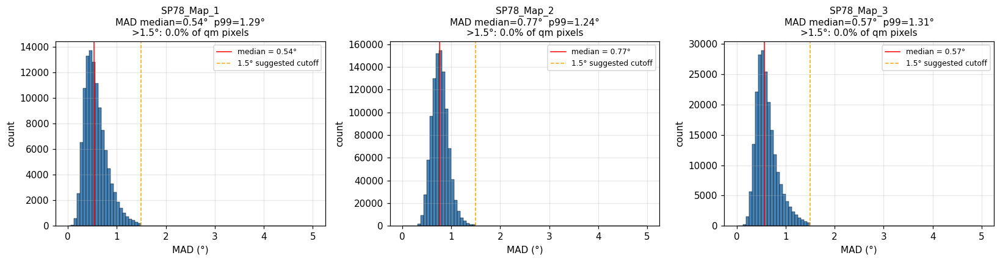


=== Diagnostic verdict ===
  SP78_Map_1: SINGLE-PHASE scan (only Quartz declared).
    phase-0 fraction = 12.9%. Borderline; check MAD distribution above.
    MAD tail is small (0.0% > 1.5°) — qm appears clean.
  SP78_Map_2: SINGLE-PHASE scan (only Quartz declared).
    phase-0 fraction = 10.1%. Borderline; check MAD distribution above.
    MAD tail is small (0.0% > 1.5°) — qm appears clean.
  SP78_Map_3: SINGLE-PHASE scan (only Quartz declared).
    phase-0 fraction = 17.8%. Borderline; check MAD distribution above.
    MAD tail is small (0.0% > 1.5°) — qm appears clean.

Suggested next step:
  If any sample shows >10% of qm pixels with MAD > 1.5°, apply
  qm_clean = qm & (e["mad"] < 1.5)
  before any quartz-specific analysis. Otherwise the qm includes
  fake-quartz (phase-forced non-quartz minerals).


In [ ]:
# ===== Phase-composition + MAD diagnostic =====
import numpy as np
import matplotlib.pyplot as plt

# Skip if any sample lacks a target_mask (no phase matched TARGET_PHASE_NAME)
_missing = [t for t, d in samples.items() if d.get('target_mask') is None]
if _missing:
    raise RuntimeError(f'No target phase set for {_missing}.  '
                        f'Edit TARGET_PHASE_NAME in cell 6 / 8 or call '
                        f'switch_target_phase(samples, "<phase>").')
fig, axes = plt.subplots(1, len(samples), figsize=(5 * len(samples), 4), dpi=110,
                          squeeze=False)
print(f'{"sample":<22s}  {"phases declared":<40s}  {"phase composition":<30s}')
print('-' * 100)
for k, (tag, info) in enumerate(samples.items()):
    e   = info['ebsd']
    qm  = info['target_mask']
    qid = info['target_phase_id']
    pnames = {pid: pinfo[2] for pid, pinfo in e['meta']['phases'].items()}
    phase_decl = ', '.join(f'{p}:{n}' for p, n in pnames.items())

    # Phase composition: 0 + each declared phase
    p_arr = e['phase']
    n_total = p_arr.size
    counts = {0: int((p_arr == 0).sum())}
    for pid in pnames:
        counts[pid] = int((p_arr == pid).sum())
    comp_str = ', '.join(f'{pid}={100*counts[pid]/n_total:.1f}%'
                          for pid in sorted(counts.keys()))
    print(f'{tag:<22s}  {phase_decl:<40s}  {comp_str:<30s}')

    # MAD histogram for qm pixels
    ax = axes[0, k]
    if 'mad' in e and e['mad'] is not None:
        mad_q = e['mad'][qm].astype(float)
        # Filter out absurd MAD values (>10°) which are usually invalid records
        mad_q = mad_q[(mad_q > 0) & (mad_q < 10.0)]
        if mad_q.size:
            ax.hist(mad_q, bins=80, range=(0, 5), color='steelblue',
                     edgecolor='black', linewidth=0.3)
            med = float(np.median(mad_q))
            p99 = float(np.percentile(mad_q, 99))
            ax.axvline(med, color='red', lw=1, label=f'median = {med:.2f}°')
            ax.axvline(1.5, color='orange', lw=1, ls='--',
                        label='1.5° suggested cutoff')
            n_above = int((mad_q > 1.5).sum())
            frac_above = 100 * n_above / max(mad_q.size, 1)
            ax.set_title(f'{tag}\nMAD median={med:.2f}°  '
                          f'p99={p99:.2f}°\n'
                          f'>1.5°: {frac_above:.1f}% of qm pixels',
                          fontsize=10)
            ax.set_xlabel('MAD (°)')
            ax.set_ylabel('count')
            ax.legend(fontsize=8)
            ax.grid(alpha=0.3)
        else:
            ax.text(0.5, 0.5, 'no valid MAD',
                     ha='center', va='center', transform=ax.transAxes)
    else:
        ax.text(0.5, 0.5, 'MAD not in CPR record',
                 ha='center', va='center', transform=ax.transAxes)

plt.tight_layout(); plt.show()

# ---- Verdict + suggested action ----
print()
print('=== Diagnostic verdict ===')
for tag, info in samples.items():
    e = info['ebsd']
    qm = info['target_mask']
    n_phases = e['meta']['n_phases']
    p_arr = e['phase']
    p0_frac = float((p_arr == 0).mean())

    if n_phases == 1:
        # Single-phase scan; check phase-0 fraction and MAD tail
        msg = []
        msg.append(f'  {tag}: SINGLE-PHASE scan (only Quartz declared).')
        if p0_frac < 0.05:
            msg.append(f'    ⚠ phase-0 fraction = {p0_frac*100:.1f}% — suspiciously LOW. '
                        f'Likely phase forcing: non-quartz minerals were forced into Phase 1.')
        elif p0_frac > 0.30:
            msg.append(f'    phase-0 fraction = {p0_frac*100:.1f}%. '
                        f'Looks like strict indexing — non-quartz minerals correctly '
                        f'left as unindexed.')
        else:
            msg.append(f'    phase-0 fraction = {p0_frac*100:.1f}%. '
                        f'Borderline; check MAD distribution above.')
        if 'mad' in e and e['mad'] is not None:
            mad_q = e['mad'][qm].astype(float)
            mad_q = mad_q[(mad_q > 0) & (mad_q < 10)]
            if mad_q.size:
                frac_high = float((mad_q > 1.5).mean())
                if frac_high > 0.10:
                    msg.append(f'    ⚠ {frac_high*100:.1f}% of qm pixels have MAD > 1.5° '
                                f'— likely fake-quartz contamination. Suggest qm &= (mad < 1.5).')
                else:
                    msg.append(f'    MAD tail is small ({frac_high*100:.1f}% > 1.5°) — '
                                f'qm appears clean.')
        for line in msg: print(line)
    else:
        # Multi-phase scan
        print(f'  {tag}: MULTI-PHASE scan ({n_phases} phases declared). '
              f'phase-0 ({p0_frac*100:.1f}%) is real bad-data; non-quartz '
              f'minerals are explicitly indexed.')

print()
print('Suggested next step:')
print('  If any sample shows >10% of qm pixels with MAD > 1.5°, apply')
print('  qm_clean = qm & (e["mad"] < 1.5)')
print('  before any quartz-specific analysis. Otherwise the qm includes')
print('  fake-quartz (phase-forced non-quartz minerals).')


## Quartz masks

Visual inventory. At this point the Mylonite and Protomylonite show
quartz as the only indexed phase (everything else is lumped as
"unindexed = non-quartz-or-damage"). The Ultramylonite has multi-phase
indexing — we still mask to quartz only for this analysis so all three
samples are compared on equal footing.

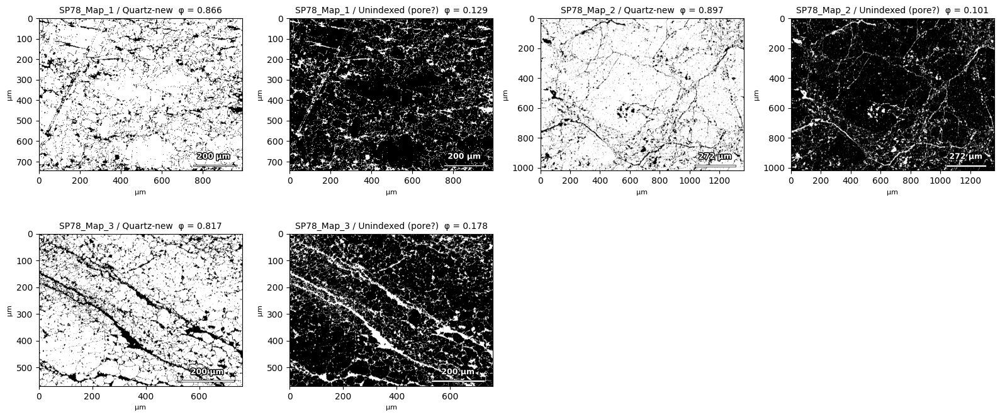

In [ ]:
# ===== Phase-mask visualization (auto multiphase) =====
# Auto-iterate every (sample, phase) combo. Set ANALYSIS_TARGETS_MIN_PHI
# at the top to filter out tiny phases.
_total_targets = sum(len(d.get('analysis_targets', [])) for d in samples.values())
if _total_targets == 0:
    raise RuntimeError('No analysis_targets found.  Re-run loader (cell 6 or 8).')

_all = list(iter_targets(samples))
n = len(_all)
ncols = min(4, n)
nrows = (n + ncols - 1) // ncols
fig, axs = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows),
                         squeeze=False)
for ax, (tag, t) in zip(axs.flat, _all):
    d = samples[tag]
    step = d['ebsd']['meta']['xstep']
    ny, nx = t['mask'].shape
    extent = [0, nx * step, ny * step, 0]
    ax.imshow(t['mask'], cmap='gray', extent=extent)
    ax.set_title(f"{pretty_label(tag, t)}  φ = {t['phi']:.3f}",
                  fontsize=10)
    ax.set_xlabel('µm', fontsize=8); ax.set_ylabel('µm', fontsize=8)
    add_scalebar(ax, step)
for ax in axs.flat[n:]: ax.set_visible(False)
fig.tight_layout(); plt.show()


## Isotropic Torquato descriptors via porespy

All of S₂(r), L(z), pore-size F(r), and chord length on the quartz
binary mask — one line per descriptor per sample.

In [ ]:
# ===== porespy n-point statistics: S2, F (pore-size), chord (auto multiphase) =====
import scipy.ndimage as ndi
# Auto-iterate every (sample, phase) combo. Set ANALYSIS_TARGETS_MIN_PHI
# at the top to filter out tiny phases.
_total_targets = sum(len(d.get('analysis_targets', [])) for d in samples.values())
if _total_targets == 0:
    raise RuntimeError('No analysis_targets found.  Re-run loader (cell 6 or 8).')

R_MAX_UM = 150.0
CHORD_MAX_UM = 200.0

def max_r_px(mask, frac=0.25):
    return int(min(mask.shape) * frac)

iso = {}                                # keyed by (tag, phase_id)
for tag, t in iter_targets(samples):
    mask = t['mask']
    step = samples[tag]['ebsd']['meta']['xstep']
    maxr = max_r_px(mask)

    s2 = ps.metrics.two_point_correlation(mask)
    dt = ndi.distance_transform_edt(mask)
    psd = ps.metrics.pore_size_distribution(dt, log=False, bins=50)
    chords_y = ps.filters.apply_chords(mask, axis=0)
    chords_x = ps.filters.apply_chords(mask, axis=1)
    cld_y = ps.metrics.chord_length_distribution(chords_y, bins=40, log=False,
                                                  voxel_size=step)
    cld_x = ps.metrics.chord_length_distribution(chords_x, bins=40, log=False,
                                                  voxel_size=step)

    # Omnidirectional chord-length survival (averaged x + y for an isotropic proxy)
    L_x = cld_x.L; S_x = cld_x.cdf
    L_y = cld_y.L; S_y = cld_y.cdf
    # Use the longer-range as the omni grid, interpolate the shorter onto it
    L_omni = L_x if L_x[-1] >= L_y[-1] else L_y
    surv_omni = 0.5 * (np.interp(L_omni, L_x, S_x, left=1.0, right=0.0) +
                        np.interp(L_omni, L_y, S_y, left=1.0, right=0.0))

    iso[(tag, t['phase_id'])] = dict(
        s2=s2, psd=psd, cld_y=cld_y, cld_x=cld_x,
        L_omni=L_omni, surv_omni=surv_omni,
        step=step, maxr=maxr, phi=t['phi'], phase_name=t['phase_name'])

print(f'iso dict has {len(iso)} (sample × phase) entries')


/Users/amasaryk/miniforge/envs/xsmurf/lib/python3.12/site-packages/porespy/metrics/_funcs.py:1154: FutureWarning: `RegionProperties.filled_area` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.area_filled` instead. 
  chord_lens = np.array([i.filled_area for i in props], dtype=int)


iso dict has 6 (sample × phase) entries


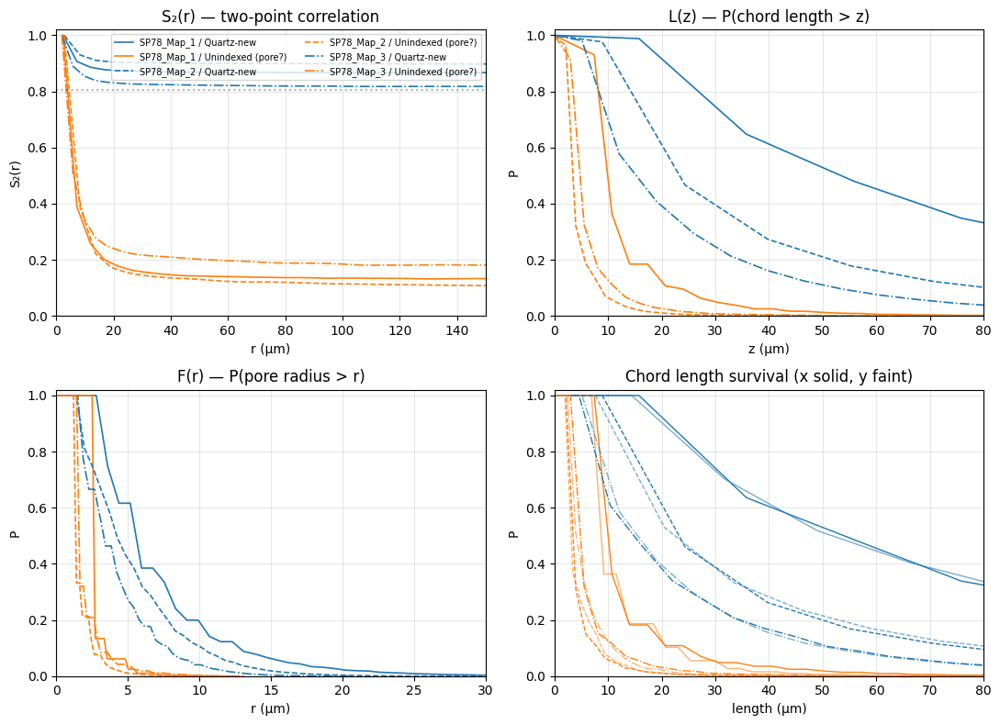

In [ ]:
# ===== Multi-panel n-point overlay (auto multiphase) =====
# S2(r), L(z), F(r), chord-length: each (sample × phase) is one curve.
# Color = phase (stable via phase_color); linestyle = sample (cycled).

_LS_BY_SAMPLE = {}     # cache linestyle per sample tag
_LS_CYCLE = ['-', '--', '-.', ':']
def sample_ls(tag):
    if tag not in _LS_BY_SAMPLE:
        _LS_BY_SAMPLE[tag] = _LS_CYCLE[len(_LS_BY_SAMPLE) % len(_LS_CYCLE)]
    return _LS_BY_SAMPLE[tag]

# Backward-compat alias for any code that still calls sample_style:
def sample_style(name):
    return phase_color('quartz'), sample_ls(name)

fig, axs = plt.subplots(2, 2, figsize=(11, 8))
for (tag, pid), r in iso.items():
    step = r['step']
    col = phase_color(r['phase_name'])
    ls  = sample_ls(tag)
    legend_label = pretty_label(tag, {'phase_name': r['phase_name']})
    axs[0, 0].plot(r['s2'].distance * step, r['s2'].probability,
                    label=legend_label, color=col, ls=ls, lw=1.2)
    L_z = np.concatenate([[0.0], r['L_omni'] * step])
    surv_z = np.concatenate([[1.0], r['surv_omni']])
    axs[0, 1].plot(L_z, surv_z, label=legend_label, color=col, ls=ls, lw=1.2)
    R_pore = np.concatenate([[0.0], r['psd'].R * step])
    S_pore = np.concatenate([[1.0], r['psd'].cdf])
    axs[1, 0].plot(R_pore, S_pore, label=legend_label, color=col, ls=ls, lw=1.2)
    Lx = np.concatenate([[0.0], r['cld_x'].L * step])
    Sx = np.concatenate([[1.0], r['cld_x'].cdf])
    Ly = np.concatenate([[0.0], r['cld_y'].L * step])
    Sy = np.concatenate([[1.0], r['cld_y'].cdf])
    axs[1, 1].plot(Lx, Sx, color=col, ls=ls, lw=1.0)
    axs[1, 1].plot(Ly, Sy, color=col, ls=ls, lw=1.0, alpha=0.6)

axs[0, 0].set(title='S₂(r) — two-point correlation', xlabel='r (µm)', ylabel='S₂(r)')
axs[0, 1].set(title='L(z) — P(chord length > z)',     xlabel='z (µm)', ylabel='P')
axs[1, 0].set(title='F(r) — P(pore radius > r)',      xlabel='r (µm)', ylabel='P')
axs[1, 1].set(title='Chord length survival (x solid, y faint)', xlabel='length (µm)', ylabel='P')

# Legend (just on the first panel)
axs[0, 0].legend(fontsize=7, ncol=2, loc='upper right')

axs[0, 0].set_xlim(0, R_MAX_UM)
axs[0, 1].set_xlim(0, 80)
axs[1, 0].set_xlim(0, 30)
axs[1, 1].set_xlim(0, 80)

if iso:
    phi_max = max(r['phi'] for r in iso.values())
    axs[0, 0].axhline(phi_max ** 2, ls=':', color='k', alpha=0.3)

for a in axs.ravel(): a.grid(True, alpha=0.3); a.set_ylim(0, 1.02)
fig.tight_layout(); plt.show()


## Anisotropic S₂(r, θ)

Porespy's built-in is radially averaged. For the directional version we
do FFT autocorrelation on the binary mask, then bin the 2D
autocorrelation by polar (r, θ). This mirrors what `compute_s2_directional`
in the companion `yield_surface_npoint` notebook does — kept inline here
so the notebook is self-contained.

In [ ]:
def s2_rtheta(mask, max_r, n_theta=36):
    # Anisotropic, *unbiased* S2(r, theta) via FFT autocorrelation of the
    # binary mask, normalised by the number of valid pairs at each lag.
    # With zero-padding, the overlap at lag (ry, rx) is (ny-ry)*(nx-rx),
    # not (ny*nx) — so dividing by the grid size as a global constant
    # biases S2 low by that geometric factor. The fix is to compute a
    # second autocorrelation of an all-ones support mask and divide.
    mask = mask.astype(np.float64)
    ny, nx = mask.shape
    padded_mask = np.zeros((2*ny, 2*nx))
    padded_mask[:ny, :nx] = mask
    padded_support = np.zeros((2*ny, 2*nx))
    padded_support[:ny, :nx] = 1.0
    F_m = fft2(padded_mask); F_s = fft2(padded_support)
    num = np.real(ifft2(F_m * np.conj(F_m)))
    den = np.real(ifft2(F_s * np.conj(F_s)))
    # Guard against near-zero denominators at lags beyond the image extent
    ac = num / np.maximum(den, 0.5)
    # Sample at small positive lags in the (r, theta) grid
    thetas = np.linspace(0, np.pi, n_theta, endpoint=False)
    rs = np.arange(0, max_r + 1)
    S2 = np.zeros((len(rs), n_theta))
    for ti, th in enumerate(thetas):
        cos_t, sin_t = np.cos(th), np.sin(th)
        for ri, r in enumerate(rs):
            dx = r * cos_t; dy = r * sin_t
            i0, j0 = int(np.floor(dy)), int(np.floor(dx))
            fi, fj = dy - i0, dx - j0
            # Bilinear interp within the padded autocorrelation (indices mod size)
            def _fetch(di, dj):
                return ac[(i0 + di) % (2*ny), (j0 + dj) % (2*nx)]
            S2[ri, ti] = ((1-fi)*(1-fj)*_fetch(0,0) + fi*(1-fj)*_fetch(1,0)
                          + (1-fi)*fj*_fetch(0,1) + fi*fj*_fetch(1,1))
    return S2, rs, thetas

def corr_length(S2_rth, rs, phi):
    # Integral correlation length, per direction:
    #   xi(theta) = (1/(phi - phi^2)) * integral_0^rmax (S2(r, theta) - phi^2) dr
    # The area under S2's decay to its asymptote phi^2, normalised so that
    # for a simple exponential S2(r) = phi^2 + (phi - phi^2) exp(-r/xi),
    # this integral equals xi. Robust to the noisy threshold-crossing
    # that was producing angular spikes for high-φ samples.
    baseline = phi * phi
    delta = np.maximum(S2_rth - baseline, 0.0)   # clip negatives from noise
    denom = max(phi - baseline, 1e-12)
    xi = np.trapezoid(delta, rs, axis=0) / denom
    return xi

In [ ]:
# ===== Anisotropic S2(r, θ) — directional 2-point correlation (auto multiphase) =====
# Auto-iterate every (sample, phase) combo. Set ANALYSIS_TARGETS_MIN_PHI
# at the top to filter out tiny phases.
_total_targets = sum(len(d.get('analysis_targets', [])) for d in samples.values())
if _total_targets == 0:
    raise RuntimeError('No analysis_targets found.  Re-run loader (cell 6 or 8).')

s2_aniso = {}                            # keyed by (tag, phase_id)
for tag, t in iter_targets(samples):
    mask = t['mask']
    maxr = max_r_px(mask, frac=0.20)
    S2, rs, ths = s2_rtheta(mask, maxr, n_theta=36)
    cl = corr_length(S2, rs, t['phi'])
    s2_aniso[(tag, t['phase_id'])] = dict(
        S2=S2, r=rs, theta=ths, corr_len=cl, maxr=maxr,
        phi=t['phi'], phase_name=t['phase_name'])
    print(f'{tag:<25s}  {t["phase_name"]:<14s}  S2(0)={S2[0,0]:.3f}  '
          f'corr length range {np.nanmin(cl):.1f}–{np.nanmax(cl):.1f} px')


SP78_Map_1                 Quartz-new      S2(0)=0.866  corr length range 3.1–6.8 px
SP78_Map_1                 Unindexed (pore?)  S2(0)=0.129  corr length range 1.5–2.9 px
SP78_Map_2                 Quartz-new      S2(0)=0.897  corr length range 11.1–15.7 px
SP78_Map_2                 Unindexed (pore?)  S2(0)=0.101  corr length range 5.2–6.7 px
SP78_Map_3                 Quartz-new      S2(0)=0.817  corr length range 3.8–10.3 px
SP78_Map_3                 Unindexed (pore?)  S2(0)=0.178  corr length range 2.8–9.8 px


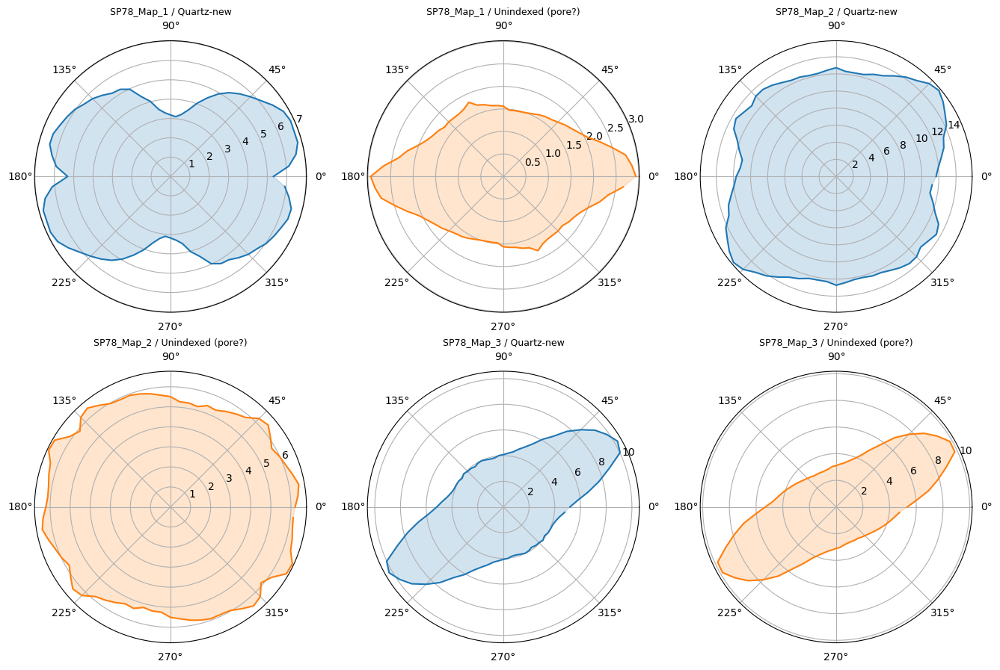

In [ ]:
# ===== Polar plot: directional correlation length per (sample × phase) =====
n = len(s2_aniso)
ncols = min(3, n)
nrows = (n + ncols - 1) // ncols
fig, axs = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4.5 * nrows),
                         subplot_kw={'projection': 'polar'}, squeeze=False)
for ax, ((tag, pid), d) in zip(axs.flat, s2_aniso.items()):
    cl = d['corr_len']    # (n_theta,) -- one per direction
    ths = d['theta']
    # Mirror to full circle
    th_full = np.concatenate([ths, ths + np.pi])
    cl_full = np.concatenate([cl, cl])
    ax.plot(th_full, cl_full, lw=1.5, color=phase_color(d['phase_name']))
    ax.fill(th_full, cl_full, alpha=0.2, color=phase_color(d['phase_name']))
    ax.set_title(pretty_label(tag, {"phase_name": d["phase_name"]}), fontsize=9)
for ax in axs.flat[n:]: ax.set_visible(False)
fig.tight_layout(); plt.show()


## Misorientation-aware grain reconstruction

The raw `scipy.ndimage.label(quartz_mask)` sees only two things: quartz
pixels and non-quartz pixels. Grain boundaries **inside the quartz
phase** are misorientation boundaries between same-phase pixels — they
don't show up in the phase mask at all, so connected-component
labelling on the mask merges hundreds of grains into a handful of
topologically-connected blobs. That's technically the right Torquato
C₂ on the phase indicator, but it's not what you'd call "grain count".

`grain_reconstruction()` below builds the MTEX-style grain map:
connected components on a graph where two same-phase pixels are linked
iff their symmetry-reduced misorientation is below 10°. Trigonal D3
symmetry for quartz, so Dauphiné twin boundaries (60° about c) count
as genuine boundaries.

In [ ]:
# ===== Grain reconstruction (wraps wtmm_ebsd.grains.identify_grains) =====
# Replaces the old in-notebook implementation with the packaged version,
# which has:
#   1. The corrected Laue-7 -> D3d mapping for alpha-quartz (the local
#      version had Laue-7 -> D3 with the wrong rotation set).
#   2. Optional Dauphine extension: treats the 180-deg-about-c twin domain
#      as the same grain in alpha-quartz.
#   3. Numba-accelerated misorientation kernel (~10x faster on big maps).
#   4. Smart fill of unindexed pixels and small clusters.
#
# The wrapper takes the same (threshold_deg, min_pixels) parameters as the
# old function, plus dauphine_aware and a smart_fill toggle.
import numpy as np
from wtmm_ebsd.grains import (
    identify_grains, fill_grain_aware,
    build_gb_mask, compute_dist_to_gb, gb_mask_at_scale,
)


def grain_reconstruction(ebsd, phase_id, threshold_deg=10.0, min_pixels=10,
                         dauphine_aware=True, smart_fill=True,
                         verbose=False):
    """Per-phase grain map.  Mask non-target pixels to phase=0 so
    identify_grains only segments within the target phase, then optionally
    apply smart-fill for cleaner GB networks."""
    ebsd_one = {k: v for k, v in ebsd.items()}
    ebsd_one['phase'] = np.where(ebsd['phase'] == phase_id, phase_id, 0)

    gid = identify_grains(
        ebsd_one,
        theta_c_deg=threshold_deg,
        min_pixels=min_pixels,
        dauphine_aware=dauphine_aware,
        verbose=verbose,
    )
    if smart_fill:
        res = fill_grain_aware(
            gid, ebsd_one,
            min_dissolve=min_pixels,
            edge_protect_min=3,
            diss_engulfed=True,
            diss_between=True,
            diss_isolated=False,    # don't dissolve isolated 1-pixel grains
        )
        gid = res.grain_id
    # CRITICAL: smart_fill propagates grain_id into every pixel where
    # ebsd_one['phase']==0 — but that includes pixels we masked to 0
    # because they belong to OTHER phases (or are pore).  Restrict the
    # output to pixels whose ORIGINAL phase is the target.  Without this,
    # fill_grain_aware Voronoi-fills across phase boundaries, producing
    # nonsense grain counts (e.g. 179k "albite grains" where the bulk of
    # the image is actually orthoclase + pore).
    gid = np.where(ebsd['phase'] == phase_id, gid, 0).astype(np.int32)
    return gid


In [ ]:
# Compute per-phase grain maps using the packaged grain_reconstruction
# wrapper above.  Each phase gets its own compact grain_id (1..N for that
# phase).  Then add the four GB-network scalar fields directly onto each
# analysis_target so the n-point statistics machinery picks them up:
#
#   gb_mask          - boolean GB pixel mask (1-px-thick GB skeleton)
#   gb_at_scale4     - GB band dilated by 4 px
#   gb_at_scale8     - GB band dilated by 8 px
#   dist_to_gb_um    - Euclidean distance to nearest GB (microns)
#
# All four stash on each target dict alongside `mask`, `phi`, etc., so
# downstream cells iterating analysis_targets see them automatically.
MIN_GRAIN_PIXELS    = 10
GRAIN_THRESHOLD_DEG = 10.0
DAUPHINE_AWARE      = True   # extends D3 -> D6 for alpha-quartz
SMART_FILL          = True   # absorbs engulfed / between small clusters

import time
for name, d in samples.items():
    if 'grain_id_by_phase' not in d:
        d['grain_id_by_phase'] = {}
    if 'n_grains_by_phase' not in d:
        d['n_grains_by_phase'] = {}
    if 'grain_size_map_by_phase' not in d:
        d['grain_size_map_by_phase'] = {}

    px_um = float(d['ebsd']['meta'].get('xstep', 1.0))

    for t in d.get('analysis_targets', []):
        pid   = t['phase_id']
        pname = t['phase_name']

        if pid == 0:
            # Phase 0 = unindexed (pore).  No orientation → no grain
            # reconstruction.  Treat each connected pore region as a
            # "grain" via 4-connected labelling so the GB-network
            # machinery (gb_mask, dist_to_gb) produces the pore *surface*
            # and pore-distance-transform consistently with crystalline
            # phases.  min_pixels still drops noise speckle.
            from scipy.ndimage import label as _ndi_label
            t0 = time.perf_counter()
            pore_mask = (d['ebsd']['phase'] == 0)
            gid_p, n_lab = _ndi_label(pore_mask, structure=np.ones((3, 3)))
            sizes_p = np.bincount(gid_p.ravel())
            keep = sizes_p >= MIN_GRAIN_PIXELS
            keep[0] = True
            if not keep.all():
                gid_p = np.where(keep[gid_p], gid_p, 0)
                _, compact = np.unique(gid_p, return_inverse=True)
                gid_p = compact.reshape(gid_p.shape).astype(np.int32)
            gid = gid_p
            dt_grain = time.perf_counter() - t0
        else:
            t0 = time.perf_counter()
            gid = grain_reconstruction(
                d['ebsd'], phase_id=pid,
                threshold_deg=GRAIN_THRESHOLD_DEG,
                min_pixels=MIN_GRAIN_PIXELS,
                dauphine_aware=DAUPHINE_AWARE,
                smart_fill=SMART_FILL,
                verbose=False,
            )
            dt_grain = time.perf_counter() - t0

        n_grains = int(gid.max())
        sizes = np.bincount(gid.ravel())
        size_map = sizes[gid].astype(np.float32)
        size_map[gid == 0] = np.nan
        d['grain_id_by_phase'][pid]       = gid
        d['n_grains_by_phase'][pid]       = n_grains
        d['grain_size_map_by_phase'][pid] = size_map

        # ----- GB-network scalar fields, stashed on the target -----
        t1 = time.perf_counter()
        gb1 = build_gb_mask(gid)
        gb4 = gb_mask_at_scale(gb1, scale_px=4.0)
        gb8 = gb_mask_at_scale(gb1, scale_px=8.0)
        dist = compute_dist_to_gb(gid, px_um=px_um, large_only=True,
                                    min_size=MIN_GRAIN_PIXELS)
        dt_gb = time.perf_counter() - t1

        t['grain_id']      = gid
        t['n_grains']      = n_grains
        t['grain_size_map'] = size_map
        t['gb_mask']       = gb1
        t['gb_at_scale4']  = gb4
        t['gb_at_scale8']  = gb8
        t['dist_to_gb_um'] = dist

        med_size = float(np.median(sizes[1:])) if n_grains > 0 else 0.0
        gb_frac  = 100.0 * float(gb1.mean())
        print(f'{name:<22s}  {pname:<14s}  '
              f'{n_grains:5d} grains  median={med_size:6.0f} px  '
              f'GB={gb_frac:5.1f}%  '
              f'(grain {dt_grain:4.1f}s, GB {dt_gb:4.1f}s)')

    # Backward-compat: 'grain_id' / 'n_grains' / 'grain_size_map' on the
    # sample dict point to the target-phase entry.
    pid_default = (d.get('target_phase_id')
                    or (d['analysis_targets'][0]['phase_id']
                         if d.get('analysis_targets') else None))
    if pid_default is not None and pid_default in d['grain_id_by_phase']:
        d['grain_id']       = d['grain_id_by_phase'][pid_default]
        d['n_grains']       = d['n_grains_by_phase'][pid_default]
        d['grain_size_map'] = d['grain_size_map_by_phase'][pid_default]


SP78_Map_1              Quartz-new       5575 grains  median=     0 px  GB= 46.9%  (grain  0.4s, GB  0.0s)
SP78_Map_1              Unindexed (pore?)    293 grains  median=    20 px  GB= 14.7%  (grain  0.0s, GB  0.0s)
SP78_Map_2              Quartz-new      14577 grains  median=     0 px  GB= 22.5%  (grain  4.2s, GB  0.1s)
SP78_Map_2              Unindexed (pore?)   1614 grains  median=    24 px  GB= 10.9%  (grain  0.0s, GB  0.1s)
SP78_Map_3              Quartz-new       6962 grains  median=     0 px  GB= 36.2%  (grain  0.7s, GB  0.0s)
SP78_Map_3              Unindexed (pore?)    491 grains  median=    23 px  GB= 20.3%  (grain  0.0s, GB  0.0s)


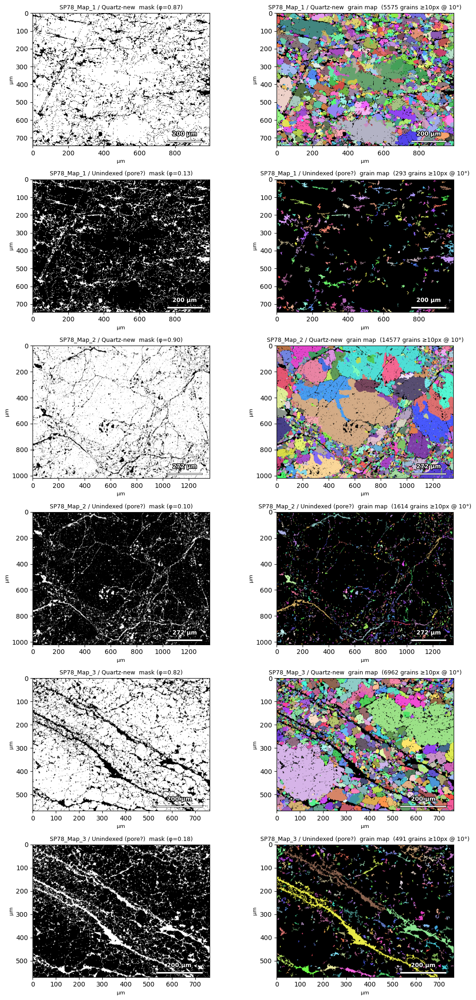

In [ ]:
# ===== Grain map + per-phase masks (auto multiphase, per-phase grain_id) =====
import matplotlib.colors as mc

_total_targets = sum(len(d.get('analysis_targets', [])) for d in samples.values())
if _total_targets == 0:
    raise RuntimeError('No analysis_targets found.  Re-run loader.')

_all = list(iter_targets(samples))
fig, axs = plt.subplots(len(_all), 2, figsize=(11, 3.6 * len(_all)),
                         squeeze=False)
for row, (tag, t) in enumerate(_all):
    d = samples[tag]
    step = d['ebsd']['meta']['xstep']
    pid = t['phase_id']
    gid = d.get('grain_id_by_phase', {}).get(pid)
    n_g = d.get('n_grains_by_phase', {}).get(pid, 0)
    if gid is None:
        axs[row, 0].text(0.5, 0.5, 'no grain_id (run cell 26 first)',
                         ha='center', va='center', transform=axs[row, 0].transAxes)
        axs[row, 1].text(0.5, 0.5, 'no grain_id', ha='center', va='center',
                         transform=axs[row, 1].transAxes)
        continue
    ny, nx = gid.shape
    extent = [0, nx * step, ny * step, 0]
    rng = np.random.default_rng(0)
    ncol = n_g + 1
    palette = np.vstack([[0, 0, 0],
                          rng.uniform(0.25, 1.0, (max(ncol - 1, 1), 3))])
    cmap_g = mc.ListedColormap(palette)

    axs[row, 0].imshow(t['mask'], cmap='gray', extent=extent)
    add_scalebar(axs[row, 0], step)
    axs[row, 0].set_title(f'{pretty_label(tag, t)}  mask (φ={t["phi"]:.2f})',
                           fontsize=9)
    axs[row, 1].imshow(gid, cmap=cmap_g, extent=extent)
    add_scalebar(axs[row, 1], step)
    axs[row, 1].set_title(f'{pretty_label(tag, t)}  grain map  '
                           f'({n_g} grains ≥{MIN_GRAIN_PIXELS}px @ {GRAIN_THRESHOLD_DEG:.0f}°)',
                           fontsize=9)
    for a in axs[row]: a.set_xlabel('µm', fontsize=8); a.set_ylabel('µm', fontsize=8)
fig.tight_layout(); plt.show()


## Kalidindi scalar-field gallery (n-point statistics targets)

Build the per-pixel scalar / boolean fields that feed into the Kalidindi
spatial-statistics pipeline.  Each `analysis_target` (one per phase per
sample, including the pore phase if `INCLUDE_UNINDEXED_AS_PORE`) gets a
`scalar_fields` dict containing — depending on `SCALAR_TIER`:

  * **fast**:    `kam`, `gb_mask`, `gb_at_scale4`, `gb_at_scale8`,
                  `dist_to_gb_um`, `phase_boundary_mask`, `sgb/lagb/hagb_mask`,
                  `misorient_max_deg`, `bc_damage`
  * **pantleon**: + `gnd_frob`, `gnd_sq` (requires Nye α — skipped if not
                  pre-computed in this notebook)
  * **cpo**:    + `theta_attractor`, `dauphine_mask`
  * **all**:    + per-slip-system densities

For npcf_multiphase we typically stop at `fast` (no Pantleon / TWTMM
machinery here); raise the tier if you've already pre-computed Nye α via
the wtmm_ebsd pipeline.

In [ ]:
import numpy as np
from wtmm_ebsd.scalar_fields import build_scalar_fields, field_summary

SCALAR_TIER       = 'cpo'      # fast | pantleon | cpo | all
NORMALIZE_P99     = True        # divide each scalar by its p99 finite-value

for tag, info in samples.items():
    e = info['ebsd']
    px_um = float(e['meta'].get('xstep', 1.0))
    print(f'\n=== {tag} ===')
    for t in info.get('analysis_targets', []):
        if t['phase_id'] == 0:
            # Phase 0 = unindexed.  Build a stripped-down field set —
            # most fields (KAM, misorient, GROD, alpha) are not defined
            # without orientation data.  We still compute the GB-network
            # fields (pore surface, dist-to-pore) and BC damage.
            from wtmm_ebsd.grains import (
                build_gb_mask, gb_mask_at_scale, compute_dist_to_gb,
            )
            gid = t['grain_id']
            sf = {}
            sf['gb_mask']      = build_gb_mask(gid).astype(bool)
            sf['gb_at_scale4'] = gb_mask_at_scale(sf['gb_mask'], scale_px=4.0)
            sf['gb_at_scale8'] = gb_mask_at_scale(sf['gb_mask'], scale_px=8.0)
            sf['dist_to_gb_um'] = compute_dist_to_gb(
                gid, px_um=px_um, large_only=True).astype(np.float32)
            if e.get('bc') is not None:
                bc = e['bc'].astype(np.float32)
                bc_max = float(bc.max()) if bc.size and bc.max() > 0 else 1.0
                sf['bc_damage'] = (1.0 - bc / bc_max).astype(np.float32)
            sf['_norm_p99'] = {k: 1.0 for k in sf}
        else:
            sf = build_scalar_fields(
                e, t['grain_id'],
                tier=SCALAR_TIER,
                px_um=px_um,
                misorient_phase_id=t['phase_id'],
                normalize_p99=NORMALIZE_P99,
                verbose=False,
            )
        t['scalar_fields'] = sf
        n_real = sum(1 for k in sf if not k.startswith('_'))
        # Flag Dauphine presence — for alpha-quartz phases this should be
        # populated automatically (now in 'fast' tier).
        dau_str = ''
        if 'dauphine_mask' in sf:
            dau_frac = float(sf['dauphine_mask'].mean())
            dau_str = f'  Dauphine: {100*dau_frac:.2f}% of pixels'
        print(f'  {t["phase_name"]:<28s}  {n_real:2d} fields{dau_str}')
print('\nScalar fields stashed under each target as t[\'scalar_fields\'].')



=== SP78_Map_1 ===
  Quartz-new                    13 fields  Dauphine: 2.71% of pixels
  Unindexed (pore?)              5 fields

=== SP78_Map_2 ===
  Quartz-new                    13 fields  Dauphine: 0.02% of pixels
  Unindexed (pore?)              5 fields

=== SP78_Map_3 ===
  Quartz-new                    13 fields  Dauphine: 0.28% of pixels
  Unindexed (pore?)              5 fields

Scalar fields stashed under each target as t['scalar_fields'].


### Discretise continuous scalar fields

Each continuous scalar (`kam`, `gnd_frob`, `dist_to_gb_um`, ...) is
quantile-binned into `N_BINS_CONTINUOUS` ordinal classes (default 3 =
low / mid / high tertiles).  Boolean fields are kept as-is.

The resulting class maps and one-hot stacks land alongside the original
fields so the 2-point cells below can iterate over them directly.

Quantile binning ensures balanced classes per scan — important for 2-pt
statistics so each class has the same global volume fraction φ regardless
of the scan's overall scalar distribution.

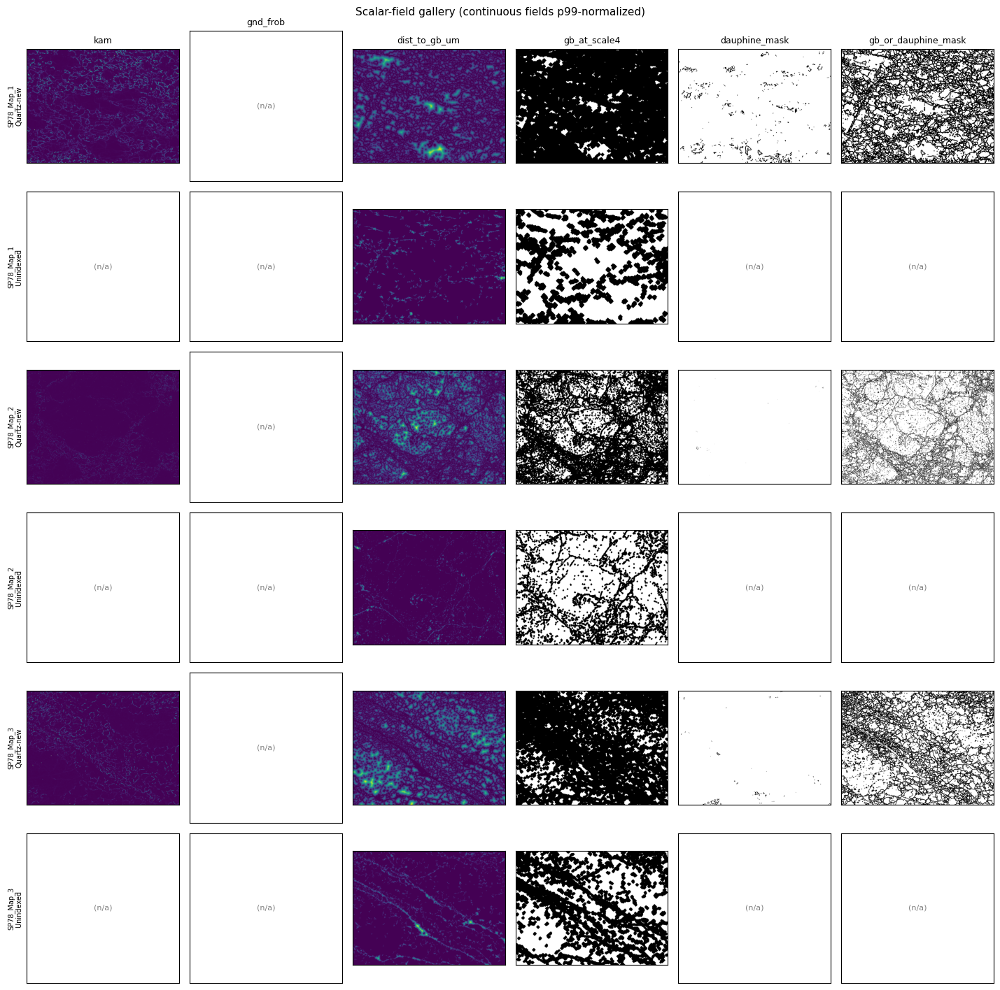

In [ ]:
from wtmm_ebsd.spatial_stats import discretise_field, one_hot_stack
import matplotlib.pyplot as plt

N_BINS_CONTINUOUS = 3
CONTINUOUS_FIELDS = ['kam', 'grod', 'gnd_frob', 'gnd_sq',
                      'dist_to_gb_um', 'theta_attractor', 'bc_damage',
                      'misorient_max_deg']

for tag, info in samples.items():
    e = info['ebsd']
    for t in info.get('analysis_targets', []):
        sf = t['scalar_fields']
        # The "valid" pixel set is the phase mask (or pore mask for pid=0).
        valid = (e['phase'] == t['phase_id']) if t['phase_id'] != 0 else (e['phase'] == 0)
        for fname in CONTINUOUS_FIELDS:
            if fname not in sf: continue
            f = sf[fname]
            if f.dtype == bool: continue
            cls, edges = discretise_field(
                f, n_bins=N_BINS_CONTINUOUS,
                quantile_edges=True, valid_mask=valid)
            sf[f'{fname}_cls']   = cls
            sf[f'{fname}_edges'] = edges
            # Top-tertile binary mask is what most cross-correlations want
            sf[f'{fname}_high']  = (cls == N_BINS_CONTINUOUS - 1)

# ---- gallery viz: one row per target, one col per requested field ----
GALLERY_FIELDS = ['kam', 'gnd_frob', 'dist_to_gb_um',
                   'gb_at_scale4', 'dauphine_mask', 'gb_or_dauphine_mask']
all_targets = [(tag, t) for tag, info in samples.items()
                for t in info.get('analysis_targets', [])]
n_rows = len(all_targets)
n_cols = len(GALLERY_FIELDS)
fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(2.4 * n_cols, 2.4 * n_rows),
                          squeeze=False)
for row, (tag, t) in enumerate(all_targets):
    sf = t['scalar_fields']
    for col, fk in enumerate(GALLERY_FIELDS):
        ax = axes[row, col]
        if fk in sf:
            arr = sf[fk]
            cmap = 'gray_r' if arr.dtype == bool else 'viridis'
            ax.imshow(arr, cmap=cmap, aspect='equal',
                       vmin=0 if arr.dtype != bool else None,
                       vmax=None if arr.dtype != bool else 1)
        else:
            ax.text(0.5, 0.5, '(n/a)', ha='center', va='center',
                     transform=ax.transAxes, fontsize=8, color='0.5')
        if row == 0:
            ax.set_title(fk, fontsize=9)
        if col == 0:
            ax.set_ylabel(f'{tag[:10]}\n{t["phase_name"][:10]}', fontsize=7)
        ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Scalar-field gallery (continuous fields p99-normalized)', fontsize=11)
plt.tight_layout(); plt.show()


### 2-point spatial statistics — auto + cross

For a chosen (sample, phase) target, we build a binary mask set:

  * the phase mask itself
  * the GB-network masks at three scales
  * the high-class (top tertile) of every continuous field

then compute the full N×N pairwise 2-point correlations via
`wtmm_ebsd.spatial_stats.correlation_matrix`.  Each pair gets a 2D map
$f_r(\mathbf{r})$ and its azimuthal radial average $f_r(r)$.

The asymptote of $f_r$ at large $r$ should approach $\phi^A \phi^B$ (the
product of the two 1-point statistics).  Deviation from that asymptote
quantifies clustering: $f_r(r) > \phi^A \phi^B$ at small $r$ → A and
B are co-clustered at that lag.

Computing 12×12 2-point correlations for SP78_Map_1 / Quartz-new...
  done in 0.53s


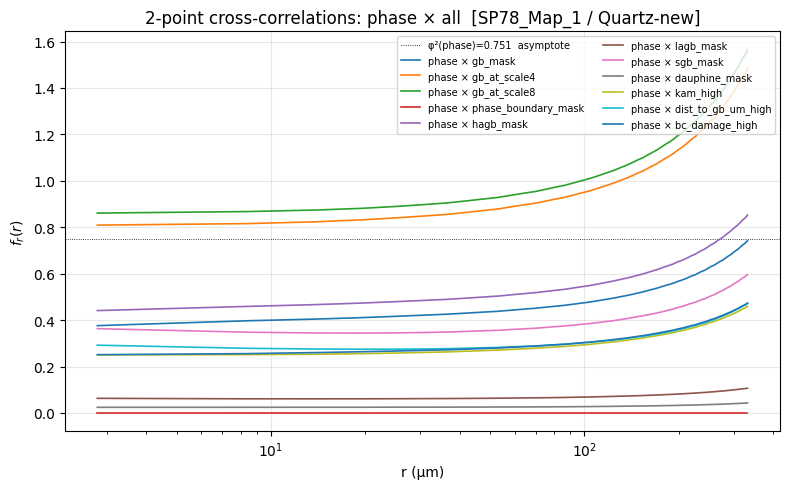

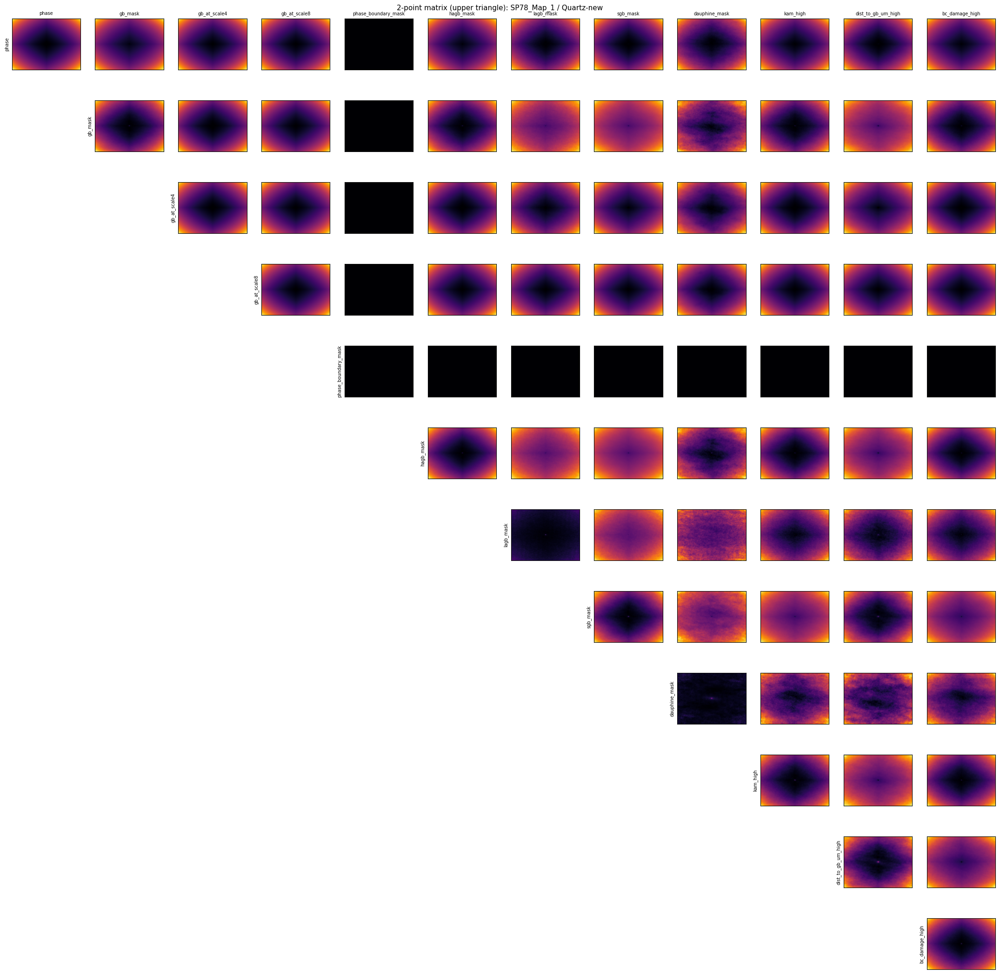

In [ ]:
from wtmm_ebsd.spatial_stats import (
    correlation_matrix, two_point, two_point_radial,
)
import matplotlib.pyplot as plt

# Build a binary mask set for one chosen (sample, phase) target.  Defaults
# to the first sample's first phase; change TAG_TO_PLOT / PHASE_TO_PLOT
# to inspect a different one.
TAG_TO_PLOT     = list(samples.keys())[0]
PHASE_TO_PLOT   = samples[TAG_TO_PLOT]['analysis_targets'][0]['phase_name']

def _binary_set(target):
    sf = target['scalar_fields']
    out = {'phase': target['mask'].astype(bool)}
    for k in ('gb_mask', 'gb_at_scale4', 'gb_at_scale8',
              'phase_boundary_mask', 'hagb_mask', 'lagb_mask', 'sgb_mask',
              'dauphine_mask'):
        if k in sf:
            out[k] = sf[k].astype(bool)
    for cont in ('kam', 'grod', 'gnd_frob', 'gnd_sq',
                  'dist_to_gb_um', 'theta_attractor', 'bc_damage'):
        hi_key = f'{cont}_high'
        if hi_key in sf:
            out[hi_key] = sf[hi_key].astype(bool)
    return out

target = next(t for t in samples[TAG_TO_PLOT]['analysis_targets']
               if t['phase_name'] == PHASE_TO_PLOT)
masks  = _binary_set(target)
names  = list(masks.keys())
px_um  = float(samples[TAG_TO_PLOT]['ebsd']['meta'].get('xstep', 1.0))

print(f'Computing {len(names)}×{len(names)} 2-point correlations '
       f'for {TAG_TO_PLOT} / {PHASE_TO_PLOT}...')
import time
_t0 = time.perf_counter()
cm = correlation_matrix(masks, periodic=False, radial_bins=60)
print(f'  done in {time.perf_counter() - _t0:.2f}s')

# ---- plot 1: phase × everything radial ----
fig, ax = plt.subplots(figsize=(8, 5))
phi = float(masks['phase'].mean())
ax.axhline(phi * phi, color='black', lw=0.6, ls=':',
            label=f'φ²(phase)={phi*phi:.3g}  asymptote')
for nm in names:
    if nm == 'phase': continue
    entry = cm[('phase', nm)]
    r_um = entry['r_px'] * px_um
    ax.plot(r_um, entry['f_rad'], lw=1.2,
            label=f'phase × {nm}')
ax.set(xlabel='r (µm)', ylabel='$f_r(r)$', xscale='log',
        title=f'2-point cross-correlations: phase × all  '
              f'[{TAG_TO_PLOT} / {PHASE_TO_PLOT}]')
ax.legend(fontsize=7, ncols=2, loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ---- plot 2: full correlation matrix as a triangular grid of 2D maps ----
fig, axes = plt.subplots(len(names), len(names),
                          figsize=(1.8 * len(names), 1.8 * len(names)),
                          squeeze=False)
for i, n in enumerate(names):
    for j, p in enumerate(names):
        ax = axes[i, j]
        if j < i:
            ax.set_visible(False)
            continue
        f_r = cm[(n, p)]['f_r']
        ax.imshow(f_r, cmap='inferno', aspect='equal')
        if i == 0: ax.set_title(p, fontsize=7)
        if j == i: ax.set_ylabel(n, fontsize=7)
        ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f'2-point matrix (upper triangle): '
              f'{TAG_TO_PLOT} / {PHASE_TO_PLOT}', fontsize=11)
plt.tight_layout(); plt.show()


### Coherence length / RVE-size adequacy check

For each (sample × phase × field) combo, compute the coherence length C —
the smallest $r$ at which the autocorrelation $f_r(r)$ has decayed to
within 5% of $\phi^2$.  If C is greater than a substantial fraction of
the scan dimension, the 2-point statistics for that field are
**sample-size-biased** and you'd need a larger scan to characterise that
phase / observable.

Adams-Kalidindi-Fullwood (2012, "Microstructure-Sensitive Design of
Structural Materials") use coherence length as the formal RVE-size
criterion: scan side length should be ≥ 2C.

Output table flags fields where C > 0.5 × min(ny, nx) / 2 in red.

In [ ]:
from wtmm_ebsd.spatial_stats import two_point, coherence_length

print(f'{"sample":<22s}  {"phase":<22s}  {"field":<18s}  '
       f'{"C (µm)":>10s}  {"f_rad/φ² @edge":>14s}  status')
print('-' * 100)
for tag, info in samples.items():
    e = info['ebsd']
    px_um = float(e['meta'].get('xstep', 1.0))
    ny, nx = e['euler1'].shape
    L_max_um = 0.45 * min(ny, nx) * px_um
    for t in info.get('analysis_targets', []):
        sf = t['scalar_fields']
        for fname in ('mask',) + tuple(k for k in sf
                                         if k.endswith('_high')
                                         or k in ('gb_mask', 'phase_boundary_mask',
                                                   'dauphine_mask', 'hagb_mask')):
            arr = (t['mask'] if fname == 'mask' else sf.get(fname))
            if arr is None: continue
            arr_f = arr.astype(np.float64)
            phi = float(arr_f.mean())
            if phi <= 0 or phi >= 1: continue
            f_r = two_point(arr_f, periodic=False)
            C, frac = coherence_length(f_r, phi, threshold_frac=0.05,
                                         px_um=px_um)
            if not np.isfinite(C):
                status = 'NOT REACHED on this scan'
                C_str = '∞'
            elif C > 0.5 * L_max_um:
                status = 'borderline'
                C_str = f'{C:.1f}'
            else:
                status = 'ok'
                C_str = f'{C:.1f}'
            print(f'{tag[:22]:<22s}  {t["phase_name"][:22]:<22s}  '
                   f'{fname:<18s}  {C_str:>10s}  {frac:>14.3f}  {status}')


sample                  phase                   field                   C (µm)  f_rad/φ² @edge  status
----------------------------------------------------------------------------------------------------
SP78_Map_1              Quartz-new              mask                       8.4           1.827  ok
SP78_Map_1              Quartz-new              gb_mask                      ∞           1.829  NOT REACHED on this scan
SP78_Map_1              Quartz-new              hagb_mask                    ∞           1.826  NOT REACHED on this scan
SP78_Map_1              Quartz-new              dauphine_mask            125.5           1.771  ok
SP78_Map_1              Quartz-new              kam_high                     ∞           1.832  NOT REACHED on this scan
SP78_Map_1              Quartz-new              dist_to_gb_um_high           ∞           1.833  NOT REACHED on this scan
SP78_Map_1              Quartz-new              bc_damage_high               ∞           1.826  NOT REACHED on thi

### PCA on 2-point statistics across samples (Adams-Kalidindi)

If multiple samples are loaded, project each onto the same 2-point
auto-correlation of a chosen field, then run PCA on the stack.  Samples
that look similar in microstructure end up close in PC space.  If only
one sample is loaded, this cell is a no-op.

Useful for comparing scans at different stages of deformation, or
sub-regions of a heterogeneously deformed scan.

PCA: 6 samples, first 2 PCs explain 100.0% of variance


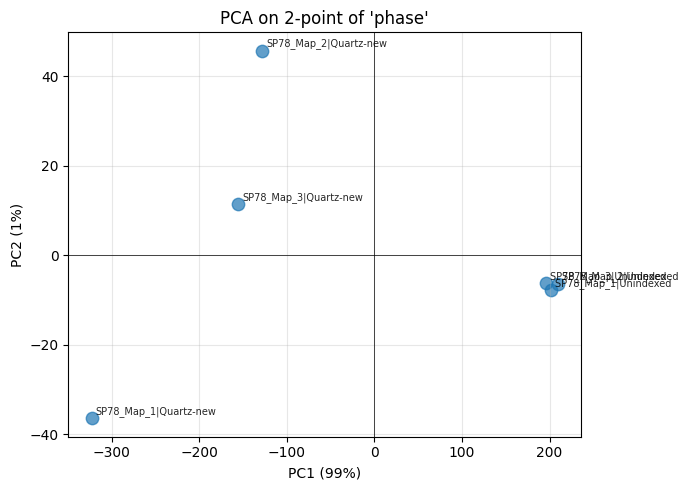

In [ ]:
from wtmm_ebsd.spatial_stats import two_point, pca_on_2pt
import matplotlib.pyplot as plt

PCA_FIELD     = 'phase'        # which field to PCA on across samples/phases
PCA_PHASE     = None             # None = all phases; or e.g. 'Quartz-new'
PCA_N_COMPONENTS = 2

# Collect (label, f_r) pairs
items = []
for tag, info in samples.items():
    for t in info.get('analysis_targets', []):
        if PCA_PHASE is not None and t['phase_name'] != PCA_PHASE:
            continue
        if PCA_FIELD == 'phase':
            arr = t['mask'].astype(np.float64)
        else:
            arr = t['scalar_fields'].get(PCA_FIELD)
            if arr is None: continue
            arr = arr.astype(np.float64)
        f_r = two_point(arr, periodic=False)
        label = f"{tag[:14]}|{t['phase_name'][:10]}"
        items.append((label, f_r))

if len(items) < 2:
    print(f'PCA skipped: only {len(items)} sample(s)/phase(s) for field '
           f'{PCA_FIELD!r}.  Load more samples to enable PCA.')
else:
    # All f_r must share shape -> crop to the smallest
    min_ny = min(f.shape[0] for _, f in items)
    min_nx = min(f.shape[1] for _, f in items)
    def _crop(f):
        ny, nx = f.shape
        cy, cx = ny // 2, nx // 2
        h = min_ny // 2; w = min_nx // 2
        return f[cy-h:cy+h, cx-w:cx+w]
    f_stack = np.stack([_crop(f) for _, f in items], axis=0)
    labels  = [lbl for lbl, _ in items]
    pca = pca_on_2pt(f_stack, n_components=PCA_N_COMPONENTS, centre=True)
    print(f'PCA: {len(items)} samples, '
           f'first {PCA_N_COMPONENTS} PCs explain '
           f'{100 * pca["explained"].sum():.1f}% of variance')
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(pca['scores'][:, 0], pca['scores'][:, 1], s=80, c='tab:blue', alpha=0.7)
    for (x, y), lbl in zip(pca['scores'], labels):
        ax.annotate(lbl, (x, y), fontsize=7, alpha=0.85,
                     xytext=(3, 3), textcoords='offset points')
    ax.set(xlabel=f'PC1 ({100*pca["explained"][0]:.0f}%)',
            ylabel=f'PC2 ({100*pca["explained"][1]:.0f}%)',
            title=f'PCA on 2-point of {PCA_FIELD!r}'
                   + (f' / phase={PCA_PHASE}' if PCA_PHASE else ''))
    ax.grid(alpha=0.3); ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
    plt.tight_layout(); plt.show()


## Continuous-field PCF — KAM, GND_F, CPO θ, etc.

Auto-correlation $f_r(\mathbf{r}) = \langle f(\mathbf{x})\,f(\mathbf{x}+\mathbf{r})\rangle$ for each
continuous scalar field on each (sample, phase) target.  Unlike the
discretised version (cell 33), this is the **direct** PCF on the
continuous field — what Latypov & Kalidindi (2017) call the "primary"
2-point statistic.

Asymptote at large $r$ is $\langle f \rangle^2$ (mean squared).
Peak at $r=0$ is $\langle f^2 \rangle$ (mean of squared).
Decay scale = correlation length of the field's heterogeneity.

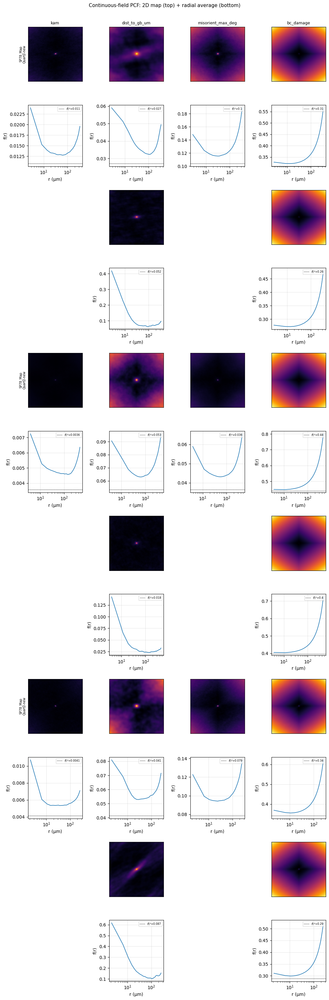

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from wtmm_ebsd.spatial_stats import two_point, two_point_radial

# Pick which fields to plot.  Skips silently if a field isn't present
# (e.g. theta_attractor on a non-quartz scan).
PCF_FIELDS = ['kam', 'gnd_frob', 'theta_attractor', 'dist_to_gb_um',
              'misorient_max_deg', 'bc_damage', 'grod']

all_targets = [(tag, t) for tag, info in samples.items()
                for t in info.get('analysis_targets', [])
                if t.get('scalar_fields') is not None]

# Filter to fields actually present in at least one target
present_fields = []
for fk in PCF_FIELDS:
    if any(fk in t['scalar_fields'] and
            t['scalar_fields'][fk].dtype != bool
            for _, t in all_targets):
        present_fields.append(fk)

n_targets = len(all_targets)
n_fields  = len(present_fields)
if n_targets == 0 or n_fields == 0:
    print('No (sample, phase, continuous-field) combos to plot. '
           'Run cells 28a + 28b first.')
else:
    # Two-row layout: 2D map + radial average for each field
    fig, axes = plt.subplots(
        2 * n_targets, n_fields,
        figsize=(2.6 * n_fields, 2.6 * 2 * n_targets),
        squeeze=False,
    )
    for row, (tag, t) in enumerate(all_targets):
        sf = t['scalar_fields']
        e  = samples[tag]['ebsd']
        px_um = float(e['meta'].get('xstep', 1.0))
        for col, fk in enumerate(present_fields):
            ax_map = axes[2 * row,     col]
            ax_rad = axes[2 * row + 1, col]
            if fk not in sf or sf[fk].dtype == bool:
                ax_map.set_visible(False); ax_rad.set_visible(False)
                continue
            f = sf[fk].astype(np.float64)
            if not np.isfinite(f).any():
                ax_map.set_visible(False); ax_rad.set_visible(False)
                continue
            # Compute 2-pt — already centred (fftshifted)
            f_r = two_point(f, periodic=False)
            r_px, f_rad = two_point_radial(f_r, n_bins=60)
            r_um = r_px * px_um
            mean_sq = float(f.mean()) ** 2
            # 2D map (clip extreme tails for visibility)
            ny, nx = f_r.shape
            crop = min(ny // 4, nx // 4)
            f_r_disp = f_r[ny//2-crop:ny//2+crop, nx//2-crop:nx//2+crop]
            ax_map.imshow(f_r_disp, cmap='inferno', aspect='equal',
                           origin='lower')
            ax_map.set_xticks([]); ax_map.set_yticks([])
            if row == 0:
                ax_map.set_title(fk, fontsize=9)
            if col == 0:
                ax_map.set_ylabel(f'{tag[:8]}\n{t["phase_name"][:10]}', fontsize=7)
            # radial average
            ax_rad.plot(r_um, f_rad, lw=1.2, color='tab:blue')
            ax_rad.axhline(mean_sq, ls='--', lw=0.6, color='black',
                            label=f'⟨f⟩²={mean_sq:.2g}')
            ax_rad.set(xlabel='r (µm)', ylabel='f(r)')
            ax_rad.set_xscale('log')
            ax_rad.grid(alpha=0.3)
            ax_rad.legend(fontsize=6, loc='upper right', framealpha=0.7)
    fig.suptitle('Continuous-field PCF: 2D map (top) + radial average (bottom)',
                  fontsize=11, y=1.0)
    plt.tight_layout(); plt.show()


### Phase-restricted PCF — KAM in quartz vs in albite vs unrestricted

Three definitions of "PCF on field $f$ within phase $X$":

1. **Unrestricted**:  $f_r = \langle f(\mathbf{x})\,f(\mathbf{x}+\mathbf{r})\rangle$ over all pixels.
2. **Joint** (correlation of $f \cdot \mathbb{1}_X$): asymptote $\langle f\,\mathbb{1}_X\rangle^2$ — captures both
   "be in phase $X$" AND "have value $f$".
3. **Conditional** (joint divided by $\langle\mathbb{1}_X\,\mathbb{1}_X\rangle$): asymptote $\langle f \mid X\rangle^2$ —
   factors out the trivial geometric "two pixels both in $X$" likelihood,
   leaving the *intra-phase* correlation of $f$.

Conditional is what most papers mean by "PCF on $f$ in phase $X$" — it
isolates how the field varies *within the phase*, independent of the
phase's spatial layout.

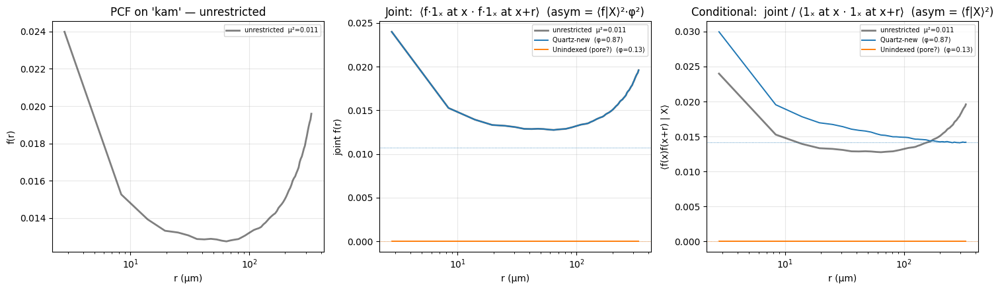

Conditional PCF asymptote per phase = ⟨'kam' | phase⟩².
Differences between phases tell you the field has phase-specific correlation length.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from wtmm_ebsd.spatial_stats import two_point, two_point_radial

PR_FIELD = 'kam'   # which field to compare across phases
PR_TAG   = list(samples.keys())[0]

if PR_TAG not in samples:
    print(f'Sample {PR_TAG!r} not loaded.')
elif not samples[PR_TAG].get('analysis_targets'):
    print(f'No analysis_targets for {PR_TAG!r}.  Run grain-recon cells first.')
else:
    e = samples[PR_TAG]['ebsd']
    px_um = float(e['meta'].get('xstep', 1.0))
    targets = samples[PR_TAG]['analysis_targets']

    # The unrestricted version uses the FIRST target's field array
    # (all phases share the same underlying ebsd field; only phase masks differ)
    base_field = None
    for t in targets:
        sf = t.get('scalar_fields') or {}
        if PR_FIELD in sf and sf[PR_FIELD].dtype != bool:
            base_field = sf[PR_FIELD].astype(np.float64)
            break

    if base_field is None:
        print(f'Field {PR_FIELD!r} not present (continuous) on any target.')
    else:
        fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), squeeze=False)
        ax_total, ax_joint, ax_cond = axes[0]

        # Unrestricted (single curve)
        f_r = two_point(base_field, periodic=False)
        r_px, f_rad = two_point_radial(f_r, n_bins=60)
        r_um = r_px * px_um
        mu = float(base_field.mean()); var = float(base_field.var())
        for ax in (ax_total, ax_joint, ax_cond):
            ax.plot(r_um, f_rad, lw=2, color='black',
                     label=f'unrestricted  μ²={mu*mu:.2g}', alpha=0.5)

        # Per-phase joint + conditional
        cmap = plt.cm.tab10
        for k, t in enumerate(targets):
            mask_X = (e['phase'] == t['phase_id']).astype(np.float64)
            field_X = base_field * mask_X
            f_r_joint = two_point(field_X, periodic=False)
            f_r_mask  = two_point(mask_X, periodic=False)
            f_r_cond  = f_r_joint / np.maximum(f_r_mask, 1e-30)

            r_px, joint_rad = two_point_radial(f_r_joint, n_bins=60)
            _,    mask_rad  = two_point_radial(f_r_mask,  n_bins=60)
            _,    cond_rad  = two_point_radial(f_r_cond,  n_bins=60)

            phi = float(mask_X.mean())
            mu_X = float(field_X.sum() / max(mask_X.sum(), 1))
            color = cmap(k % 10)

            label = f'{t["phase_name"]}  (φ={phi:.2g})'
            ax_joint.plot(r_um, joint_rad, color=color, lw=1.4, label=label)
            ax_joint.axhline((mu_X * phi) ** 2, ls=':', color=color, lw=0.6)
            ax_cond.plot(r_um, cond_rad, color=color, lw=1.4, label=label)
            ax_cond.axhline(mu_X * mu_X, ls=':', color=color, lw=0.6)

        ax_total.set(title=f'PCF on {PR_FIELD!r} — unrestricted',
                      xlabel='r (µm)', ylabel='f(r)', xscale='log')
        ax_joint.set(title=f'Joint:  ⟨f·1ₓ at x · f·1ₓ at x+r⟩  (asym = ⟨f|X⟩²·φ²)',
                      xlabel='r (µm)', ylabel='joint f(r)', xscale='log')
        ax_cond.set(title=f'Conditional:  joint / ⟨1ₓ at x · 1ₓ at x+r⟩  (asym = ⟨f|X⟩²)',
                     xlabel='r (µm)', ylabel='⟨f(x)f(x+r) | X⟩', xscale='log')
        for a in (ax_total, ax_joint, ax_cond):
            a.legend(fontsize=7, loc='best'); a.grid(alpha=0.3)
        plt.tight_layout(); plt.show()

        print(f'Conditional PCF asymptote per phase = ⟨{PR_FIELD!r} | phase⟩².')
        print('Differences between phases tell you the field has '
               'phase-specific correlation length.')


### Anisotropic PCF cuts — does the field have a preferred direction?

The 2D PCF $f_r(\mathbf{r})$ is a complete directional descriptor.  The
azimuthal radial average (used everywhere above) collapses it to a 1D
$f_r(r)$, throwing away anisotropy information.

For shear-zone fabrics, mylonites, fault rocks — **the foliation imposes
strong anisotropy** that the radial average hides.  This cell extracts
horizontal / vertical / diagonal slices through the 2D PCF, plotted on
the same axes.

If the three slices overlap → field is isotropic at this scale.  If they
diverge → preferred direction quantified.

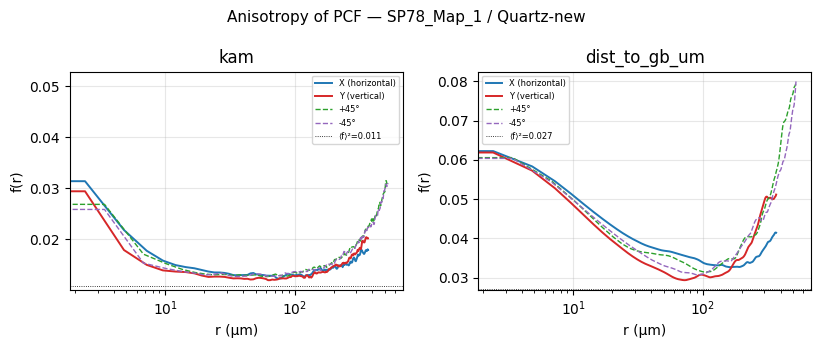

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from wtmm_ebsd.spatial_stats import two_point

ANISO_FIELDS = ['kam', 'gnd_frob', 'theta_attractor', 'dist_to_gb_um']
ANISO_TAG    = list(samples.keys())[0]
ANISO_PHASE  = (samples[ANISO_TAG]['analysis_targets'][0]['phase_name']
                if samples[ANISO_TAG].get('analysis_targets') else None)

target = next((t for t in samples[ANISO_TAG]['analysis_targets']
                if t['phase_name'] == ANISO_PHASE), None)
if target is None:
    print(f'No target {ANISO_PHASE!r} on {ANISO_TAG!r}.')
else:
    e = samples[ANISO_TAG]['ebsd']
    px_um = float(e['meta'].get('xstep', 1.0))
    sf = target.get('scalar_fields') or {}
    fields_avail = [f for f in ANISO_FIELDS if f in sf and sf[f].dtype != bool]
    if not fields_avail:
        print(f'No continuous fields available on this target: {list(sf)}')
    else:
        n = len(fields_avail)
        fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 3.5), squeeze=False)
        for col, fk in enumerate(fields_avail):
            ax = axes[0, col]
            f = sf[fk].astype(np.float64)
            f_r = two_point(f, periodic=False)
            ny, nx = f_r.shape
            cy, cx = ny // 2, nx // 2
            r_max = min(cy, cx)
            r_lags = np.arange(0, r_max)

            f_horizontal = f_r[cy, cx:cx + r_max]
            f_vertical   = f_r[cy:cy + r_max, cx]
            # +45° diagonal (lower-right from centre)
            r_diag = np.arange(0, min(ny - cy, nx - cx))
            f_diag_pos = f_r[cy + r_diag, cx + r_diag]
            # -45° (upper-right from centre)
            r_aneg = np.arange(0, min(cy + 1, nx - cx))
            f_diag_neg = f_r[cy - r_aneg, cx + r_aneg]

            r_um = r_lags * px_um
            r_diag_um = r_diag * px_um * np.sqrt(2)   # diagonal lag scales by √2
            r_aneg_um = r_aneg * px_um * np.sqrt(2)
            mean_sq = float(f.mean()) ** 2

            ax.plot(r_um, f_horizontal, label='X (horizontal)', lw=1.4, color='tab:blue')
            ax.plot(r_um, f_vertical,    label='Y (vertical)',  lw=1.4, color='tab:red')
            ax.plot(r_diag_um, f_diag_pos, label='+45°', lw=1.0, ls='--', color='tab:green')
            ax.plot(r_aneg_um, f_diag_neg, label='-45°', lw=1.0, ls='--', color='tab:purple')
            ax.axhline(mean_sq, ls=':', lw=0.6, color='black',
                        label=f'⟨f⟩²={mean_sq:.2g}')
            ax.set(xlabel='r (µm)', ylabel='f(r)',
                    title=f'{fk}', xscale='log')
            ax.legend(fontsize=6, loc='best'); ax.grid(alpha=0.3)
        fig.suptitle(f'Anisotropy of PCF — {ANISO_TAG} / {ANISO_PHASE}',
                      fontsize=11)
        plt.tight_layout(); plt.show()


### Sub-region SVE ensemble PCA — Latypov-Kalidindi 2017 §4.5

Generate a **statistical-volume-element ensemble** by tiling each
loaded scan into overlapping sub-regions, computing the 2-point
statistics for each tile, and running PCA across the tile-ensemble.

Each tile becomes one data point in the PC scatter, coloured by source
sample / phase.  Tiles from heterogeneously deformed regions of one
scan land at different points; tiles from similar microstructures
cluster.  This is the closest you can get to the Latypov-Kalidindi 2017
PC space without needing many physically-distinct EBSD scans.

If only one (sample, phase, field) combo is loaded, the cell still
populates the PC space with N tiles — useful for finding outlier
sub-regions of a single scan.

  SP78_Map_1 / Quartz-new        :   15 tiles
  SP78_Map_2 / Quartz-new        :  234 tiles
  SP78_Map_3 / Quartz-new        :   40 tiles

Total 289 tiles in ensemble; running PCA...


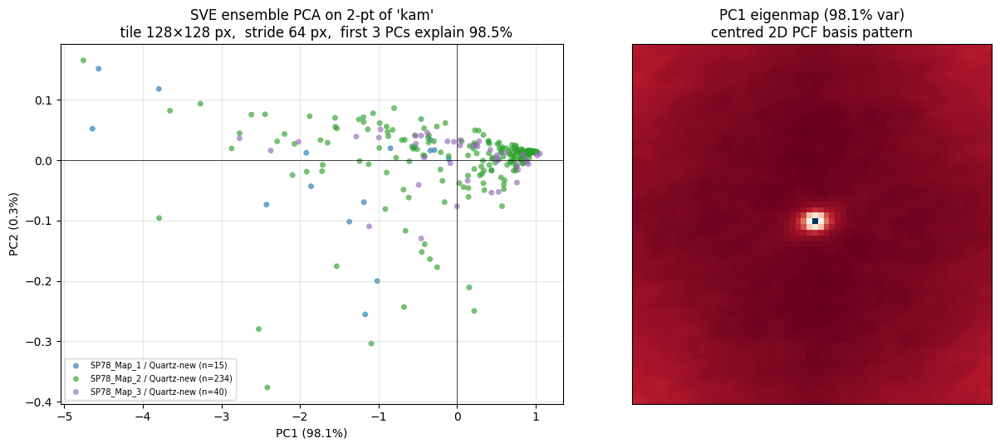

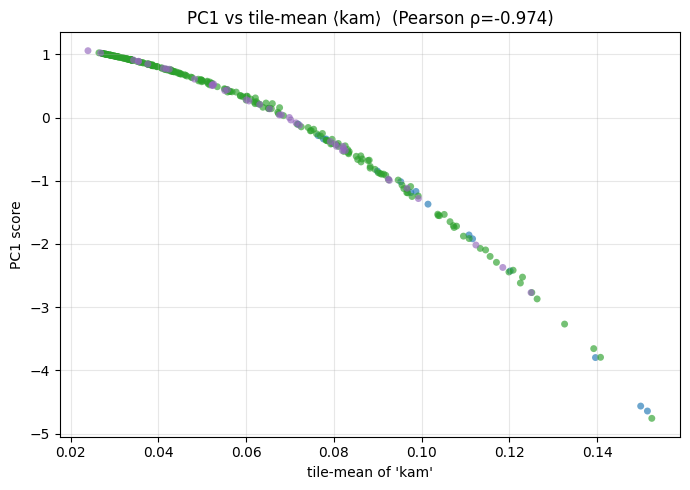


If PC1 correlates strongly with tile-mean (|ρ| > 0.95) the
first PC is just capturing the volume fraction / mean of the
field — typical of Kalidindi-style 2-pt PCA on volume-fraction-
dominated phases (cf. Latypov-Kalidindi 2017 Fig 3).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from wtmm_ebsd.spatial_stats import (
    tile_field, two_point, pca_on_2pt,
)

SVE_FIELD       = 'kam'      # which field to tile + PCA
SVE_TILE_PX     = 128         # tile side in pixels
SVE_STRIDE      = 64          # 50% overlap by default
SVE_N_PC        = 3
SVE_N_BINS_RAD  = 40          # not used directly here; PCA on full 2D

all_targets = [(tag, t) for tag, info in samples.items()
                for t in info.get('analysis_targets', [])
                if t.get('scalar_fields') is not None]

# Collect tile 2-pt stacks per (tag, phase) target
all_f_r = []
all_labels = []
all_colors = []
all_tile_means = []

cmap = plt.cm.tab10
target_color_map = {}
for k, (tag, t) in enumerate(all_targets):
    sf = t['scalar_fields']
    if SVE_FIELD not in sf or sf[SVE_FIELD].dtype == bool:
        continue
    field = sf[SVE_FIELD].astype(np.float64)
    if min(field.shape) < SVE_TILE_PX:
        print(f'  skip {tag}/{t["phase_name"]}: scan too small for tile size {SVE_TILE_PX}')
        continue
    tiles, coords = tile_field(field, tile_px=SVE_TILE_PX, stride=SVE_STRIDE)
    if len(tiles) == 0:
        continue
    target_color = cmap(k % 10)
    target_color_map[(tag, t['phase_name'])] = target_color
    print(f'  {tag} / {t["phase_name"]:<18s}: {len(tiles):4d} tiles')
    for ti, tile in enumerate(tiles):
        if not np.isfinite(tile).any() or tile.std() < 1e-12:
            continue
        f_r = two_point(tile, periodic=False)
        all_f_r.append(f_r)
        all_labels.append(f'{tag[:6]}|{t["phase_name"][:6]}|t{ti}')
        all_colors.append(target_color)
        all_tile_means.append(float(tile.mean()))

if len(all_f_r) < 2:
    print(f'\nPCA skipped: only {len(all_f_r)} tiles produced.  '
           f'Lower SVE_TILE_PX or load larger scans.')
else:
    print(f'\nTotal {len(all_f_r)} tiles in ensemble; running PCA...')
    f_stack = np.stack(all_f_r, axis=0)
    pca = pca_on_2pt(f_stack, n_components=SVE_N_PC, centre=True)
    scores = pca['scores']
    explained = pca['explained']

    # ---- PCA scatter coloured by source target ----
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
    ax_pc, ax_basis = axes
    for k, (tag, name) in enumerate(target_color_map):
        col = target_color_map[(tag, name)]
        sel = [i for i, c in enumerate(all_colors) if np.allclose(c, col)]
        if not sel: continue
        ax_pc.scatter(scores[sel, 0], scores[sel, 1],
                       c=[col], s=25, alpha=0.65, edgecolor='none',
                       label=f'{tag[:10]} / {name[:10]} (n={len(sel)})')
    ax_pc.set(xlabel=f'PC1 ({100 * explained[0]:.1f}%)',
              ylabel=f'PC2 ({100 * explained[1]:.1f}%)',
              title=f'SVE ensemble PCA on 2-pt of {SVE_FIELD!r}\n'
                     f'  tile {SVE_TILE_PX}×{SVE_TILE_PX} px,  '
                     f'stride {SVE_STRIDE} px,  '
                     f'first {SVE_N_PC} PCs explain '
                     f'{100*explained.sum():.1f}%')
    ax_pc.axhline(0, color='k', lw=0.5); ax_pc.axvline(0, color='k', lw=0.5)
    ax_pc.legend(fontsize=7, loc='best'); ax_pc.grid(alpha=0.3)

    # ---- First PC basis map (the eigen-pattern) ----
    pc1_basis = pca['components'][0]
    ny, nx = pc1_basis.shape
    crop = min(ny // 4, nx // 4)
    ax_basis.imshow(pc1_basis[ny//2-crop:ny//2+crop, nx//2-crop:nx//2+crop],
                     cmap='RdBu_r', aspect='equal', origin='lower')
    ax_basis.set(title=f'PC1 eigenmap ({100*explained[0]:.1f}% var)\n'
                        f'centred 2D PCF basis pattern',
                  xticks=[], yticks=[])
    plt.tight_layout(); plt.show()

    # ---- Optional: PC1 vs tile mean (does PC1 just reflect ⟨f⟩?) ----
    fig2, ax2 = plt.subplots(figsize=(7, 5))
    ax2.scatter(all_tile_means, scores[:, 0],
                 c=all_colors, s=25, alpha=0.65, edgecolor='none')
    if np.std(all_tile_means) > 0:
        from numpy import corrcoef
        rho = corrcoef(all_tile_means, scores[:, 0])[0, 1]
        ax2.set_title(f'PC1 vs tile-mean ⟨{SVE_FIELD}⟩  (Pearson ρ={rho:.3f})')
    else:
        ax2.set_title(f'PC1 vs tile-mean ⟨{SVE_FIELD}⟩')
    ax2.set(xlabel=f'tile-mean of {SVE_FIELD!r}',
             ylabel=f'PC1 score')
    ax2.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    print('\nIf PC1 correlates strongly with tile-mean (|ρ| > 0.95) the\n'
           'first PC is just capturing the volume fraction / mean of the\n'
           'field — typical of Kalidindi-style 2-pt PCA on volume-fraction-\n'
           'dominated phases (cf. Latypov-Kalidindi 2017 Fig 3).')


## Orientation 1-point statistics — ODF + pole figures

The book's core idea: orientation $g$ is the **primary local state** for
polycrystals.  Up to here we've been doing 2-pt statistics on phase masks
and on scalar projections (KAM, GROD).  Now we treat orientation itself
as the local state.

This cell computes the **1-point statistic** of the chosen crystal axis
(c-axis by default) — its Lambert equal-area pole-figure density.  This
is the ODF projected onto a single axis, identical in spirit to the
``stereonet_density_plot`` we use for CPO but using a histogram instead
of a vMF KDE so it composes naturally with the n-point machinery.

For α-quartz the c-axis $\vec c = [0001]$ is a symmetry axis of $D_{3d}$,
so its pole figure has a clean physical interpretation (the dominant
slip system's reference direction).  For other phases (orthoclase,
albite) it's the conventional fabric direction.

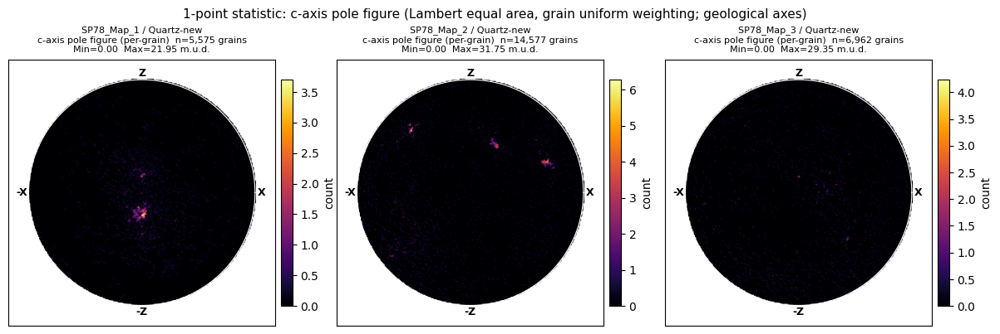

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from wtmm_ebsd.orientation_stats import (
    per_pixel_axis_sample, pole_figure_histogram, per_grain_weight_map,
)

# Weighting mode for the 1-point statistic:
#   'grain_uniform' (default): each grain contributes once regardless of size
#                              (number-weighted ODF — standard CPO convention)
#   'pixel': each pixel counts equally  (area-weighted ODF — naive histogram)
#   'grain_log_area': log-attenuated compromise
WEIGHT_MODE = 'grain_uniform' 

POLE_AXIS = 'c'             # 'a', 'b', or 'c'
POLE_GRID = 200             # Lambert disk resolution

# Sample-frame axis labels for the disk perimeter.
# 'geological' (default): X right / Z top / -X left / -Z bottom
#                          (Papeschi / MTEX / Bestmann convention — assumes
#                           scan-Y is aligned with foliation normal Z)
# 'ebsd_scan':            X right / Y top / -X left / -Y bottom
#                          (raw EBSD scan frame — use if your sample is
#                           mounted with scan-X = scan-Y = sample axes)
LABEL_FRAME = 'geological'

# Contour-line levels in *multiples of uniform density* (m.u.d.).
# uniform = mean of finite cells; e.g. levels [1, 2, 3] match Papeschi 2019.
CONTOUR_LEVELS_MUD = [1.0, 2.0, 3.0, 4.0]
SHOW_CONTOURS = True

all_targets = [(tag, t) for tag, info in samples.items()
                for t in info.get('analysis_targets', [])
                if t['phase_id'] != 0]    # skip pore phase

n = len(all_targets)
if n == 0:
    print('No crystalline-phase targets to plot.')
else:
    cols = min(4, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows),
                              squeeze=False)
    for ax, (tag, t) in zip(axes.flat, all_targets):
        e = samples[tag]['ebsd']
        # Per-pixel c-axis in sample frame, restricted to this phase
        v_smp = per_pixel_axis_sample(
            e, axis=POLE_AXIS, phase_id=t['phase_id'], fold_upper=True)
        gid = t.get('grain_id')
        if gid is None or WEIGHT_MODE == 'pixel':
            weights = None
        else:
            weights = per_grain_weight_map(gid, mode=WEIGHT_MODE)
        mask = np.isfinite(v_smp).all(axis=-1)
        rho, xe, ye = pole_figure_histogram(v_smp, mask=mask,
                                              weights=weights,
                                              n_grid=POLE_GRID)
        # Display: imshow with extent on the unit disk
        im = ax.imshow(rho, origin='lower', extent=(-1, 1, -1, 1),
                        cmap='inferno', aspect='equal',
                        interpolation='bilinear')

        # Convert to multiples of uniform density (m.u.d.) for contour levels.
        finite = np.isfinite(rho) & (rho > 0)
        mean_rho = float(rho[finite].mean()) if finite.any() else 1.0
        if SHOW_CONTOURS and finite.any() and mean_rho > 0:
            xx_g = np.linspace(-1, 1, rho.shape[1])
            yy_g = np.linspace(-1, 1, rho.shape[0])
            XG, YG = np.meshgrid(xx_g, yy_g)
            in_disk_g = XG ** 2 + YG ** 2 <= 1.0
            rho_mud = np.where(in_disk_g, rho / mean_rho, np.nan)
            try:
                ax.contour(XG, YG, rho_mud, levels=CONTOUR_LEVELS_MUD,
                            colors='black', linewidths=0.6, alpha=0.7)
            except Exception:
                pass

        # Disk boundary
        th = np.linspace(0, 2*np.pi, 200)
        ax.plot(np.cos(th), np.sin(th), color='white', lw=0.8)

        # Axis-label dictionary chosen by LABEL_FRAME
        if LABEL_FRAME == 'geological':
            # Top = +Z (foliation normal), Right = +X (lineation)
            labels_4 = [('Z',  (0, 1.06)),  ('X',  (1.06, 0)),
                         ('-Z', (0, -1.06)), ('-X', (-1.06, 0))]
        else:                                # 'ebsd_scan' or anything else
            labels_4 = [('Y',  (0, 1.06)),  ('X',  (1.06, 0)),
                         ('-Y', (0, -1.06)), ('-X', (-1.06, 0))]
        for label, (px, py) in labels_4:
            ax.text(px, py, label, ha='center', va='center',
                     fontsize=9, fontweight='bold', color='black',
                     bbox=dict(facecolor='white', edgecolor='none', alpha=0.6, pad=1))
        ax.set(xticks=[], yticks=[],
                xlim=(-1.18, 1.18), ylim=(-1.18, 1.18))
        wt_str = ('per-grain' if WEIGHT_MODE == 'grain_uniform'
                  else ('per-pixel' if WEIGHT_MODE == 'pixel' else 'log-area'))
        n_grains = t.get('n_grains', int(mask.sum()))
        n_unit = ('grains' if WEIGHT_MODE == 'grain_uniform' else 'px')
        n_count = (n_grains if WEIGHT_MODE == 'grain_uniform' else int(mask.sum()))
        # Min / Max in m.u.d. (Papeschi-style annotation)
        if finite.any():
            mud_max = float(np.nanmax(rho)) / mean_rho
            mud_min = float(np.nanmin(rho[finite])) / mean_rho
        else:
            mud_max = mud_min = 0.0
        ax.set_title(f'{tag[:14]} / {t["phase_name"][:14]}\n'
                      f'{POLE_AXIS}-axis pole figure ({wt_str})  '
                      f'n={n_count:,} {n_unit}\n'
                      f'Min={mud_min:.2f}  Max={mud_max:.2f} m.u.d.',
                      fontsize=8)
        plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02, label='count')
    for ax in axes.flat[n:]: ax.set_visible(False)
    fig.suptitle(f'1-point statistic: {POLE_AXIS}-axis pole figure '
                  f'(Lambert equal area, {WEIGHT_MODE.replace("_", " ")} weighting; '
                  f'{LABEL_FRAME} axes)',
                  fontsize=11, y=1.0)
    plt.tight_layout(); plt.show()


### Orientation 2-point statistics — c-axis bin PCFs

The Kalidindi-Niezgoda book's centrepiece for polycrystals: discretise
the c-axis pole figure into $N$ equal-area bins on the upper hemisphere,
treat each bin as a categorical local state, then run 2-point statistics
on the one-hot stack.

Each bin's autocorrelation $f_r^{nn}$ tells you whether grains with that
particular c-axis orientation **cluster spatially** (peak at small $r$
above the asymptote $\phi_n^2$) or are randomly distributed (flat at
$\phi_n^2$).  The **off-diagonal cross-correlations** $f_r^{np}$ tell
you whether two specific c-axis orientations co-cluster — a key
diagnostic for fabric domains.

This cell computes the full $N \times N$ correlation matrix for the
chosen target's c-axis bin field, then plots the autocorrelations of
the most-populated bins as radial-average overlays.

  phi_n weighting: grain_uniform
c-axis discretisation: 32 bins
  total covered: 100.0%
  per-grain weighting: each of 5,575 grains contributes equally
  top-6 bins by population:
    bin  2  phi=17.75%  centroid=(+0.19, -0.45, +0.88)
    bin  1  phi=17.36%  centroid=(-0.19, -0.45, +0.88)
    bin  6  phi=10.89%  centroid=(-0.19, +0.45, +0.88)
    bin  5  phi= 7.95%  centroid=(+0.19, +0.45, +0.88)
    bin  3  phi= 6.12%  centroid=(+0.45, -0.19, +0.88)
    bin  7  phi= 5.36%  centroid=(-0.45, +0.19, +0.88)


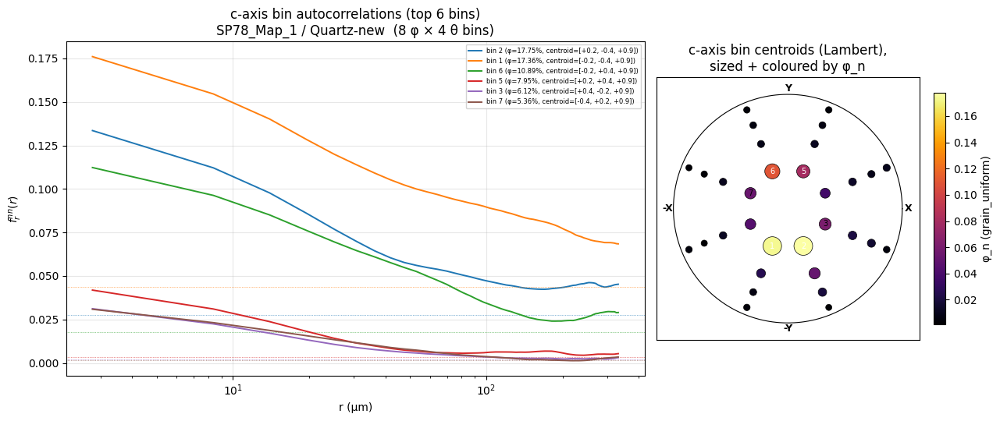


The autocorrelations exceed φ_n² near r=0 → that orientation
CLUSTERS spatially.  The asymptote at large r is φ_n² = bin
volume fraction squared (one-point statistic squared).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from wtmm_ebsd.orientation_stats import (
    per_pixel_axis_sample, bin_axis_hemisphere, bin_centroids_hemisphere,
    bin_volume_fractions, per_grain_weight_map,
)
from wtmm_ebsd.spatial_stats import one_hot_stack, two_point, two_point_radial

# Weighting mode for the 1-point statistic (φ_n = bin volume fraction).
# The 2-point statistic itself is *always* pixel-based (Niezgoda 2008
# convention — that's what makes the FFT machinery work), but the
# asymptote φ_n² we plot as a reference line uses the chosen weighting.
WEIGHT_MODE_PHI = 'grain_uniform' 

CAXIS_TAG       = list(samples.keys())[0]
CAXIS_PHASE     = next((t['phase_name'] for t in samples[CAXIS_TAG]
                          .get('analysis_targets', [])
                          if t['phase_id'] != 0), None)
CAXIS_N_PHI     = 8        # azimuthal bins around +Z pole
CAXIS_N_THETA   = 4        # colatitude bins from pole to equator
CAXIS_TOP_K     = 6        # plot autocorr for the K most-populated bins

target = next((t for t in samples[CAXIS_TAG].get('analysis_targets', [])
                if t['phase_name'] == CAXIS_PHASE), None)

if target is None or target['phase_id'] == 0:
    print(f'No crystalline target {CAXIS_PHASE!r} on {CAXIS_TAG!r}.')
else:
    e = samples[CAXIS_TAG]['ebsd']
    px_um = float(e['meta'].get('xstep', 1.0))

    # 1) Per-pixel c-axis (upper-hemi folded) restricted to this phase
    v_c = per_pixel_axis_sample(e, axis='c', phase_id=target['phase_id'],
                                  fold_upper=True)
    # 2) Bin -> categorical class map
    cls, n_bins = bin_axis_hemisphere(v_c, n_phi=CAXIS_N_PHI,
                                         n_theta=CAXIS_N_THETA)
    centroids = bin_centroids_hemisphere(n_phi=CAXIS_N_PHI,
                                            n_theta=CAXIS_N_THETA)
    # 3) One-hot stack (n_bins, ny, nx)
    stack = one_hot_stack(cls, n_bins)
    # Per-bin volume fractions, two flavours:
    #   phi_n_pixel : area-weighted (= the actual 2-pt asymptote)
    #   phi_n       : whichever weighting the user chose (for reporting)
    phi_n_pixel = stack.mean(axis=(1, 2))
    if WEIGHT_MODE_PHI == 'pixel' or target.get('grain_id') is None:
        phi_n = phi_n_pixel
    else:
        weights = per_grain_weight_map(target['grain_id'],
                                          mode=WEIGHT_MODE_PHI)
        phi_n = bin_volume_fractions(cls, n_bins, weights=weights)
    print(f'  phi_n weighting: {WEIGHT_MODE_PHI}')
    print(f'c-axis discretisation: {n_bins} bins')
    print(f'  total covered: {phi_n.sum() * 100:.1f}%')
    if WEIGHT_MODE_PHI == 'grain_uniform':
        print(f'  per-grain weighting: each of {target.get("n_grains", 0):,} grains contributes equally')
    top_idx = np.argsort(phi_n)[::-1][:CAXIS_TOP_K]
    print(f'  top-{CAXIS_TOP_K} bins by population:')
    for k in top_idx:
        print(f'    bin {k:2d}  phi={phi_n[k]*100:5.2f}%  centroid=({centroids[k,0]:+.2f}, '
               f'{centroids[k,1]:+.2f}, {centroids[k,2]:+.2f})')

    # 4) Autocorrelation per top-K bin + radial average
    fig = plt.figure(figsize=(13, 5.5 * FIG_SCALE if 'FIG_SCALE' in dir() else 5.5))
    gs = fig.add_gridspec(1, 2, width_ratios=[2, 1])
    ax_rad = fig.add_subplot(gs[0, 0])
    ax_pf  = fig.add_subplot(gs[0, 1])

    # Radial autocorrelations
    cmap = plt.cm.tab10
    for i, k in enumerate(top_idx):
        f_r = two_point(stack[k].astype(np.float64), periodic=False)
        r_px, f_rad = two_point_radial(f_r, n_bins=60)
        r_um = r_px * px_um
        col = cmap(i % 10)
        ax_rad.plot(r_um, f_rad, lw=1.4, color=col,
                     label=f'bin {k} (φ={phi_n[k]*100:.2f}%, '
                           f'centroid=[{centroids[k,0]:+.1f}, '
                           f'{centroids[k,1]:+.1f}, {centroids[k,2]:+.1f}])')
        # Asymptote of the 2-pt is always pixel-based phi_n² (FFT machinery)
        ax_rad.axhline(phi_n_pixel[k]**2, ls=':', lw=0.5, color=col)

    ax_rad.set(xlabel='r (µm)', ylabel='$f_r^{nn}(r)$',
                title=f'c-axis bin autocorrelations (top {CAXIS_TOP_K} bins)\n'
                      f'{CAXIS_TAG} / {CAXIS_PHASE}  '
                      f'({CAXIS_N_PHI} φ × {CAXIS_N_THETA} θ bins)',
                xscale='log')
    ax_rad.grid(alpha=0.3)
    ax_rad.legend(fontsize=6, loc='best', framealpha=0.85)

    # Pole figure with bin centroids labelled, sized by phi_n
    th = np.linspace(0, 2*np.pi, 200)
    ax_pf.plot(np.cos(th), np.sin(th), 'k-', lw=0.8)
    # Project centroids to Lambert disk
    n_z = centroids[:, 2]
    factor = np.sqrt(2.0 / np.maximum(1.0 + n_z, 1e-30)) / np.sqrt(2.0)
    Xc = centroids[:, 0] * factor
    Yc = centroids[:, 1] * factor
    sizes = 30 + phi_n * 1500
    sc = ax_pf.scatter(Xc, Yc, s=sizes, c=phi_n,
                        cmap='inferno', edgecolor='black', lw=0.5)
    for k, (x, y) in enumerate(zip(Xc, Yc)):
        if k in top_idx:
            ax_pf.annotate(str(k), (x, y), ha='center', va='center',
                            fontsize=7, color='white' if phi_n[k] > phi_n.max()*0.4 else 'black')
    plt.colorbar(sc, ax=ax_pf, fraction=0.04, label=f'φ_n ({WEIGHT_MODE_PHI})')
    for label, (px_, py_) in [('Y', (0, 1.05)), ('X', (1.05, 0)),
                                ('-Y', (0, -1.05)), ('-X', (-1.05, 0))]:
        ax_pf.text(px_, py_, label, ha='center', va='center',
                    fontsize=9, fontweight='bold')
    ax_pf.set(xlim=(-1.15, 1.15), ylim=(-1.15, 1.15),
              xticks=[], yticks=[],
              title='c-axis bin centroids (Lambert),\nsized + coloured by φ_n')
    ax_pf.set_aspect('equal')

    plt.tight_layout(); plt.show()

    print(f'\nThe autocorrelations exceed φ_n² near r=0 → that orientation')
    print(f'CLUSTERS spatially.  The asymptote at large r is φ_n² = bin')
    print(f'volume fraction squared (one-point statistic squared).')


### Misorientation distribution function (MODF)

Pairwise misorientation-angle histogram pooled over right- and
down-neighbour pairs.  This is the **1-point statistic of the
disorientation field** — the analogue of the ODF for misorientation
rather than orientation.

For α-quartz with strong CPO + Dauphine twinning you expect a peak
near 60°; for randomly textured aggregates it follows the Mackenzie
distribution (Mackenzie 1958).  Comparing MODFs across phases /
samples is the simplest way to ask "are the lattice rotations of this
sample dominated by random GBs, by Dauphine, or by something else?".

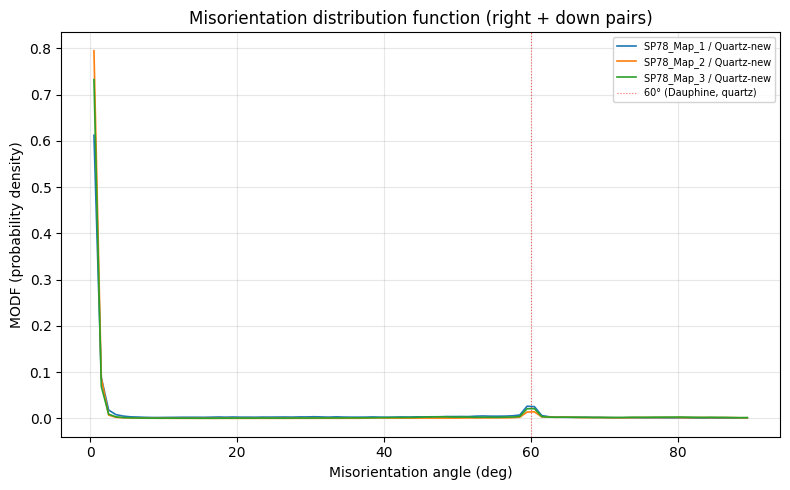

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from wtmm_ebsd.orientation_stats import misorientation_distribution
from wtmm_ebsd.symmetry import get_phase_symmetry

MODF_BINS = 90
MODF_RANGE = (0.0, 90.0)

all_targets = [(tag, t) for tag, info in samples.items()
                for t in info.get('analysis_targets', [])
                if t['phase_id'] != 0]

if not all_targets:
    print('No crystalline-phase targets for MODF.')
else:
    fig, ax = plt.subplots(figsize=(8, 5))
    cmap = plt.cm.tab10
    for k, (tag, t) in enumerate(all_targets):
        e = samples[tag]['ebsd']
        sym = get_phase_symmetry(e, phase_id=t['phase_id'])
        if sym is None:
            print(f'  no Laue mapping for {tag} / {t["phase_name"]} — skip')
            continue
        sym_q = sym.data.astype(np.float64)
        # NB: misorientation_distribution doesn't filter by phase mask;
        # it pools all pairs.  For a phase-restricted MODF, we'd need to
        # mask out cross-phase pairs upstream — fine to leave as-is for
        # the dominant phase per scan.
        centres, counts = misorientation_distribution(
            e, sym_q, bins=MODF_BINS, range_deg=MODF_RANGE)
        # Normalise to probability density
        density = counts / max(counts.sum(), 1) / np.diff(np.linspace(*MODF_RANGE, MODF_BINS+1))[0]
        col = cmap(k % 10)
        ax.plot(centres, density, lw=1.2, color=col,
                 label=f'{tag[:10]} / {t["phase_name"][:14]}')
    ax.axvline(60.0, color='red', ls=':', lw=0.8, alpha=0.6,
                label='60° (Dauphine, quartz)')
    ax.set(xlabel='Misorientation angle (deg)',
            ylabel='MODF (probability density)',
            title='Misorientation distribution function (right + down pairs)')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, loc='best', framealpha=0.85)
    plt.tight_layout(); plt.show()


## C₂(r) cluster function and C₂/S₂ connectivity ratio

For each quartz-mask, label connected components, sum the FFT
autocorrelation of each component, and normalise so C₂(0) = φ (same
as S₂). The ratio C₂/S₂ is the probability of being in the *same*
cluster given both pixels are in quartz.

**Expected behaviour**:
- If quartz is one big connected framework, C₂/S₂ ≈ 1 at all r.
- If quartz breaks into N smaller clusters of typical size ξ, then
  C₂/S₂ drops to roughly 1/⟨#clusters visible at scale r⟩ beyond ξ.

In [ ]:
def c2_rtheta_from_label(label_map, max_r, n_theta=36, min_cluster_px=4):
    # Cluster two-point function: sum of per-cluster FFT autocorrelations,
    # normalised by the pair-count support the same way as s2_rtheta
    # (unbiased at all lags). Takes a pre-computed label map where
    # 1..N = clusters and 0 = background.
    ny, nx = label_map.shape
    num_total = np.zeros((2*ny, 2*nx))
    # Single support autocorrelation (image extent): pairs-per-lag count.
    padded_support = np.zeros((2*ny, 2*nx))
    padded_support[:ny, :nx] = 1.0
    F_s = fft2(padded_support)
    den = np.real(ifft2(F_s * np.conj(F_s)))

    kept_clusters = 0
    total_px = 0
    n_clusters = int(label_map.max())
    sizes = np.bincount(label_map.ravel(), minlength=n_clusters + 1)
    for cid in range(1, n_clusters + 1):
        if sizes[cid] < min_cluster_px:
            continue
        cl = (label_map == cid)
        padded = np.zeros((2*ny, 2*nx))
        padded[:ny, :nx] = cl.astype(np.float64)
        F = fft2(padded)
        num_total += np.real(ifft2(F * np.conj(F)))
        kept_clusters += 1
        total_px += int(sizes[cid])
    ac_total = num_total / np.maximum(den, 0.5)

    thetas = np.linspace(0, np.pi, n_theta, endpoint=False)
    rs = np.arange(0, max_r + 1)
    C2 = np.zeros((len(rs), n_theta))
    for ti, th in enumerate(thetas):
        cos_t, sin_t = np.cos(th), np.sin(th)
        for ri, r in enumerate(rs):
            dx = r * cos_t; dy = r * sin_t
            i0, j0 = int(np.floor(dy)), int(np.floor(dx))
            fi, fj = dy - i0, dx - j0
            def _fetch(di, dj):
                return ac_total[(i0 + di) % (2*ny), (j0 + dj) % (2*nx)]
            C2[ri, ti] = ((1-fi)*(1-fj)*_fetch(0,0) + fi*(1-fj)*_fetch(1,0)
                          + (1-fi)*fj*_fetch(0,1) + fi*fj*_fetch(1,1))
    return C2, rs, thetas, kept_clusters, total_px

# Backwards-compatible wrapper: feed it a binary mask, get phase-mask C2.
def c2_rtheta(mask, max_r, n_theta=36, min_cluster_px=4):
    # Torquato C2 on the phase mask itself — a few giant clusters when
    # φ is high. Used as the "phase-mask connectivity" reference.
    labels, _ = _ndi_label(mask.astype(bool))
    return c2_rtheta_from_label(labels, max_r, n_theta, min_cluster_px)

In [ ]:
# ===== C₂ cluster correlation: phase-mask vs grain-wise (auto multiphase) =====
# Auto-iterate every (sample, phase) combo. Set ANALYSIS_TARGETS_MIN_PHI
# at the top to filter out tiny phases.
_total_targets = sum(len(d.get('analysis_targets', [])) for d in samples.values())
if _total_targets == 0:
    raise RuntimeError('No analysis_targets found.  Re-run loader (cell 6 or 8).')

# Skip clusters smaller than this -- noise singletons are dominant in raw EBSD
# and contribute O(1000s) of FFTs each that don't carry useful signal.
# Bump higher (e.g. 500) on dense scans; lower (e.g. 50) if you have lots of
# small real subgrains you actually want to characterize.
C2_MIN_CLUSTER_PX = 200

c2 = {}                              # keyed by (tag, phase_id)
import time as _time
for tag, t in iter_targets(samples):
    aniso_key = (tag, t['phase_id'])
    if aniso_key not in s2_aniso:
        print(f'  {aniso_key}: no s2_aniso entry, skipping'); continue
    maxr = s2_aniso[aniso_key]['maxr']

    print(f'{tag:<25s} {t["phase_name"]:<14s} maxr={maxr}px  '
          f'computing phase-mask C2...', end='', flush=True)
    _t0 = _time.perf_counter()
    # Phase-mask C2 (Torquato): clusters of the binary phase mask itself
    C2_ph, rs, ths, n_cl_ph, n_px_ph = c2_rtheta(
        t['mask'], maxr, n_theta=36, min_cluster_px=C2_MIN_CLUSTER_PX)
    print(f' {_time.perf_counter() - _t0:.1f}s', end='', flush=True)

    # Grain-wise C2 (MTEX-style): each misorientation-bounded grain is its own cluster
    # Now uses the PER-PHASE grain_id from cell 26.
    grain_id = samples[tag].get('grain_id_by_phase', {}).get(t['phase_id'])
    if grain_id is not None:
        # grain_id is already restricted to this phase's pixels
        print(f'  grain C2...', end='', flush=True)
        _t0 = _time.perf_counter()
        C2_g, _, _, n_cl_g, n_px_g = c2_rtheta_from_label(
            grain_id, maxr, n_theta=36, min_cluster_px=C2_MIN_CLUSTER_PX)
        print(f' {_time.perf_counter() - _t0:.1f}s')
    else:
        C2_g = np.zeros_like(C2_ph); n_cl_g = 0; n_px_g = 0
        print()
    c2[(tag, t['phase_id'])] = dict(
        C2_phase=C2_ph, C2_grain=C2_g, r=rs, theta=ths,
        n_clusters_phase=n_cl_ph, n_clusters_grain=n_cl_g,
        total_px=n_px_ph, phase_name=t['phase_name'])
    print(f'   -> phase clusters={n_cl_ph:5d}  grain clusters={n_cl_g:5d}  '
          f'C2_phase(0)={C2_ph[0,0]:.3f}')


Protomylonite_tile1     phase clusters=    6   grain clusters=  509   C2_phase(0)=0.955  C2_grain(0)=0.944
Protomylonite_tile2     phase clusters=  303   grain clusters=  702   C2_phase(0)=0.837  C2_grain(0)=0.828
Mylonite_tile1          phase clusters=   97   grain clusters= 1030   C2_phase(0)=0.884  C2_grain(0)=0.869
Mylonite_tile2          phase clusters=   74   grain clusters= 1028   C2_phase(0)=0.903  C2_grain(0)=0.888
Ultramylonite           phase clusters=  595   grain clusters=  773   C2_phase(0)=0.230  C2_grain(0)=0.228


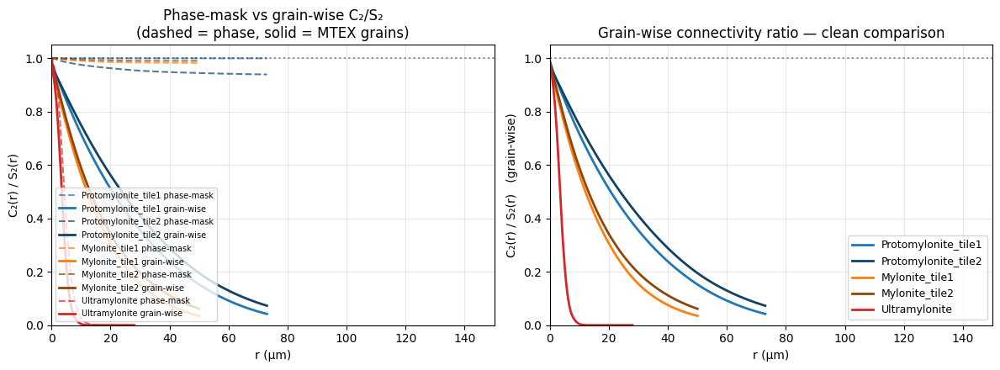

In [ ]:
# ===== C₂/S₂ ratio (θ-averaged) — per (sample × phase) =====
fig, ax = plt.subplots(figsize=(8, 5))
for (tag, pid), d in c2.items():
    if (tag, pid) not in s2_aniso: continue
    C2_g = d['C2_grain']; rs = d['r']
    S2 = s2_aniso[(tag, pid)]['S2']
    step = samples[tag]['ebsd']['meta']['xstep']
    # θ-average
    c_iso = C2_g.mean(axis=1)
    s_iso = S2.mean(axis=1)
    ratio = np.where(s_iso > 0, c_iso / s_iso, np.nan)
    col = phase_color(d['phase_name'])
    ls  = sample_ls(tag)
    ax.plot(rs * step, ratio, color=col, ls=ls, lw=1.4,
             label=pretty_label(tag, {'phase_name': d['phase_name']}))
ax.axhline(1.0, color='k', alpha=0.3, ls=':')
ax.set(xlabel='r (µm)', ylabel='C₂(r) / S₂(r)',
        title='Cluster connectivity ratio (grain-wise C₂)')
ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### Anisotropic C₂/S₂ — does quartz connectivity depend on direction?

The isotropic version above averages out the fabric anisotropy. Since
mylonitic quartz ribbons are preferentially oriented, the connectivity
ratio should drop faster **across** the foliation than along it for
samples whose ribbons are still intact. A sample where connectivity
becomes isotropic has lost the ribbon structure.

Text(0.5, 1.02, 'Directional connectivity ratio C₂(r, θ) / S₂(r, θ)')

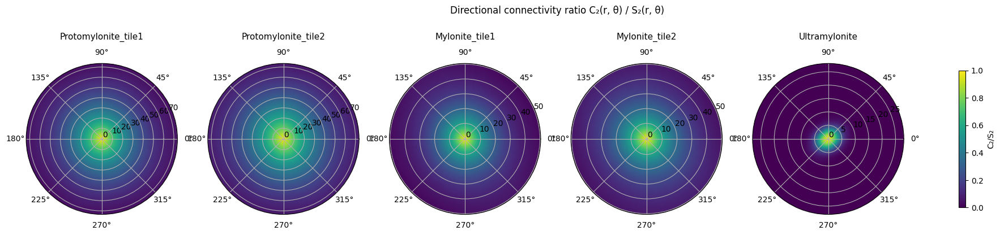

In [ ]:
# ===== C₂(r, θ) heatmap per (sample × phase) =====
n = len(c2)
ncols = min(3, n)
nrows = (n + ncols - 1) // ncols
fig, axs = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 4.0 * nrows),
                         squeeze=False)
for ax, ((tag, pid), d) in zip(axs.flat, c2.items()):
    if (tag, pid) not in s2_aniso:
        ax.text(0.5, 0.5, 'no aniso', ha='center', va='center',
                 transform=ax.transAxes); continue
    C2 = d['C2_grain']; S2 = s2_aniso[(tag, pid)]['S2']
    rs = d['r']; ths = d['theta']
    step = samples[tag]['ebsd']['meta']['xstep']
    ratio = np.where(S2 > 0, C2 / S2, 0.0)
    im = ax.imshow(ratio,
                    extent=[ths[0], ths[-1], rs[0]*step, rs[-1]*step],
                    aspect='auto', origin='lower',
                    cmap='RdYlGn_r', vmin=0, vmax=1)
    ax.set_xlabel('θ (rad)', fontsize=8)
    ax.set_ylabel('r (µm)', fontsize=8)
    ax.set_title(f'{pretty_label(tag, {"phase_name": d["phase_name"]})}  C₂/S₂', fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
for ax in axs.flat[n:]: ax.set_visible(False)
fig.tight_layout(); plt.show()


## Summary table

One row per sample: quartz volume fraction, number of clusters,
mean/max grain connectivity, correlation-length anisotropy, and the
half-radius of the C₂/S₂ ratio (the lag at which C₂/S₂ = 0.5,
equivalent to the scale beyond which half of the quartz-quartz pairs
are in *different* clusters).

In [ ]:
# ===== Connectivity half-radius summary (per sample × phase) =====
def c_over_s_halfradius(c2_iso, s2_iso, rs, step):
    ratio = np.where(s2_iso > 0, c2_iso / s2_iso, np.nan)
    # Find first r where ratio drops below 0.5
    below = np.where(ratio < 0.5)[0]
    return float(rs[below[0]] * step) if below.size else float('inf')

results = []
for (tag, pid), d in c2.items():
    if (tag, pid) not in s2_aniso: continue
    step = samples[tag]['ebsd']['meta']['xstep']
    cl = s2_aniso[(tag, pid)]['corr_len']
    c_iso = d['C2_grain'].mean(axis=1)
    s_iso = s2_aniso[(tag, pid)]['S2'].mean(axis=1)
    r_half = c_over_s_halfradius(c_iso, s_iso, d['r'], step)
    results.append({
        'sample': tag, 'phase': d['phase_name'],
        'phi': iso[(tag, pid)]['phi'] if (tag, pid) in iso else float('nan'),
        'corr_len_min_px': float(np.nanmin(cl)),
        'corr_len_max_px': float(np.nanmax(cl)),
        'r_half_um': r_half,
        'n_clusters_phase': d['n_clusters_phase'],
        'n_clusters_grain': d['n_clusters_grain'],
    })

print(f'{"sample":<22s} {"phase":<14s} {"phi":>6s} {"corr_min":>9s} '
      f'{"corr_max":>9s} {"r_half":>8s} {"n_cl_ph":>8s} {"n_cl_gr":>8s}')
print('-' * 90)
for r in results:
    print(f'{r["sample"]:<22s} {r["phase"]:<14s} {r["phi"]:>6.3f} '
          f'{r["corr_len_min_px"]:>9.1f} {r["corr_len_max_px"]:>9.1f} '
          f'{r["r_half_um"]:>8.1f} {r["n_clusters_phase"]:>8d} {r["n_clusters_grain"]:>8d}')

import pandas as pd
results_df = pd.DataFrame(results)


                     phi_quartz  n_grains  n_clusters_phase  corr_len_min_um  corr_len_max_um  anisotropy  c2_over_s2_halfradius_um
sample                                                                                                                             
Protomylonite_tile1       0.955      3032                 6            5.376           10.356       1.926                    21.000
Protomylonite_tile2       0.842      3532               303            5.639           13.671       2.425                    24.000
Mylonite_tile1            0.886      4322                97           10.442           13.258       1.270                    13.000
Mylonite_tile2            0.904      4421                74           11.441           14.709       1.286                    14.000
Ultramylonite             0.234      2920               595            1.397            2.263       1.620                     3.600


## Interpretation cribsheet

**If the KMZ deformation gradient is genuine** (Protomylonite → Mylonite
→ Ultramylonite = increasing strain):

- **φ(Qtz)**: should stay roughly constant if deformation is
  volumetrically conservative. Any large change flags either sampling
  bias or phase-specific transformations (dissolution-precipitation).
- **S₂ correlation length**: expected to **shorten** with strain as
  grain size reduces through recrystallisation. Tracks the mantle grain
  size in core-and-mantle microstructures.
- **S₂ anisotropy ratio**: expected to **increase** with strain as
  ribbons develop, *then* decrease again if ribbons break up in
  ultramylonite.
- **n_clusters**: should **increase** dramatically in the Ultramylonite
  if ribbons fragment; small in Proto/Mylonite where quartz is a
  connected framework.
- **C₂/S₂ half-radius**: the headline diagnostic. A **long** value
  means quartz connectivity extends far (ribbons intact); a **short**
  value means fragmentation. Predicted order:
  Protomylonite > Mylonite > Ultramylonite.

**If we see the opposite** (Ultramylonite has longer half-radius than
Mylonite): something unexpected. Either (a) the Ultramylonite was
sampled in a recrystallised domain where fine grains are all connected
because they're all touching, or (b) "Mylonite" is actually more
deformed than "Ultramylonite" and the sample naming reflects
microstructure rather than strain intensity.

## Caveats

- **Open boundary artefact**: porespy's two_point_correlation and our
  FFT approach both assume periodic images. Zero-padding mitigates but
  doesn't eliminate edge bias at large r. Don't trust r beyond ~1/4 of
  the shorter axis.
- **Different step sizes**: Protomylonite/Mylonite at 1 µm vs
  Ultramylonite at 0.2 µm. Plotting vs physical distance (µm) makes
  them directly comparable; pixel-level comparisons are NOT.
- **Quartz-only ignores mineralogy gradients**: if the Ultramylonite
  truly has more feldspar matrix than the Protomylonite, C₂/S₂
  differences may reflect mineralogical composition rather than
  strain-localisation mechanism. Can be tested by computing
  C₂/S₂ for all indexed phases in the Ultramylonite and seeing if
  quartz-specific connectivity is different from whole-sample
  connectivity.

In [ ]:
from scipy import stats
import numpy as np

def fit_grain_size_family(sizes_um, tail_quantile=0.90):
    # Drop the smallest bin (1-pixel "grains" = indexing noise)
    x = sizes_um[sizes_um > np.percentile(sizes_um, 2)]

    # --- 1) Full distribution: Generalised Gamma, MLE
    # scipy parameterisation: f(x) = |c|*x^(a*c - 1) * exp(-x^c) / (Γ(a) * scale^(ac))
    a, c, loc_gg, scale_gg = stats.gengamma.fit(x, floc=0)
    # Special cases:
    #   c ≈ 1  → Gamma
    #   a ≈ 1  → Weibull
    #   ac ≫ 1 + very spread a → Log-normal limit
    #   small c → heavy-tailed (power-law-like for small c)

    # --- 2) Tail: GPD via peaks-over-threshold
    u = np.quantile(x, tail_quantile)
    excesses = x[x > u] - u
    xi, loc_gpd, scale_gpd = stats.genpareto.fit(excesses, floc=0)
    # xi > 0   Fréchet (heavy tail, nonextensive)
    # xi ≈ 0   Gumbel (exponential tail)
    # xi < 0   Weibull (bounded tail, upper bound = u - scale/xi)

    # --- 3) Diagnostic: mean-residual-life at a few thresholds.
    # Stability across thresholds is the MLE validity check.
    thresholds = np.quantile(x, [0.75, 0.85, 0.90, 0.95])
    xi_by_thr = []
    for uu in thresholds:
        ex = x[x > uu] - uu
        if len(ex) < 30: continue
        xi_i, _, _ = stats.genpareto.fit(ex, floc=0)
        xi_by_thr.append((float(uu), int(len(ex)), float(xi_i)))

    return {
        'gg': {'a': a, 'c': c, 'scale': scale_gg},
        'pot': {'threshold_um': float(u), 'xi': float(xi), 'scale': float(scale_gpd),
                'n_excess': int(len(excesses))},
        'xi_stability': xi_by_thr,    # list of (threshold, n, xi) for sensitivity check
    }

sample                 n_grains  median µm    GG a    GG c   thr µm    ξ (GPD)     regime
Protomylonite_tile1        1016       2.26  13.225   0.219    29.15     -0.359    Weibull
Protomylonite_tile2        1357       2.26  18.912   0.228    13.15     -0.135    Weibull
Mylonite_tile1             1638       2.76  13.584   0.264    20.66     -0.126    Weibull
Mylonite_tile2             1664       2.52  12.872   0.265    20.52      0.004     Gumbel
Ultramylonite              1193       0.64  13.551   0.269     4.00     -0.107    Weibull


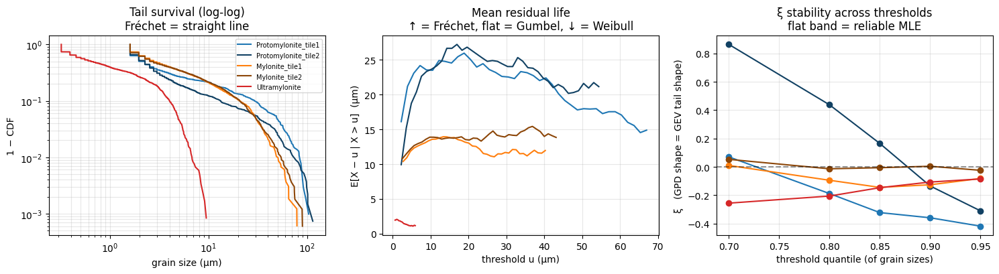

In [ ]:
# ──────────────────────────────────────────────────────────────────────
# Bruce Hobbs' "Tsallis entropy" framework — grain size distributions
#   full distribution  →  Generalised Gamma (MLE)
#   tail               →  Generalised Pareto via peaks-over-threshold
#                          (GPD shape = GEV shape ξ)
# Predicted regime shift with increasing deformation:
#   Fréchet (ξ > 0, heavy tail, connected / nonextensive)
#   Gumbel  (ξ ≈ 0, exponential tail)
#   Weibull (ξ < 0, bounded tail, constrained)
# ──────────────────────────────────────────────────────────────────────
from scipy import stats

def fit_grain_size_family(sizes_um, tail_quantile=0.90, min_excess=30):
    # Drop the bottom 2 % (single-pixel "grains" = indexing noise)
    x = sizes_um[sizes_um > np.percentile(sizes_um, 2)]
    try:
        a_gg, c_gg, _, scale_gg = stats.gengamma.fit(x, floc=0)
    except Exception:
        a_gg = c_gg = scale_gg = np.nan

    u = np.quantile(x, tail_quantile)
    excesses = x[x > u] - u
    try:
        xi, _, scale_gpd = stats.genpareto.fit(excesses, floc=0)
    except Exception:
        xi = scale_gpd = np.nan

    stability = []
    for q in (0.70, 0.80, 0.85, 0.90, 0.95):
        uu = np.quantile(x, q)
        ex = x[x > uu] - uu
        if len(ex) < min_excess:
            continue
        try:
            xi_i, _, sc_i = stats.genpareto.fit(ex, floc=0)
            stability.append((q, float(uu), len(ex), float(xi_i)))
        except Exception:
            pass

    return {'gg': (a_gg, c_gg, scale_gg), 'u': float(u), 'xi': float(xi),
            'scale_gpd': float(scale_gpd), 'n_excess': int(len(excesses)),
            'stability': stability, 'x': x}


# Per-sample fits
fits = {}
for name, d in samples.items():
    step = d['ebsd']['meta']['xstep']
    sizes_px = np.bincount(d['grain_id'].ravel())[1:]   # drop label 0 (background)
    sizes_px = sizes_px[sizes_px > 0]
    ecd = 2.0 * np.sqrt(sizes_px / np.pi) * step         # equivalent-circle diameter (µm)
    fits[name] = fit_grain_size_family(ecd)

# Summary table
print(f"{'sample':<22s} {'n_grains':>8s} {'median µm':>10s} "
      f"{'GG a':>7s} {'GG c':>7s} {'thr µm':>8s} "
      f"{'ξ (GPD)':>10s} {'regime':>10s}")
for name, f in fits.items():
    a_gg, c_gg, _ = f['gg']
    xi = f['xi']
    regime = 'Fréchet' if xi > 0.05 else ('Weibull' if xi < -0.05 else 'Gumbel')
    print(f"{name:<22s} {len(f['x']):>8d} {np.median(f['x']):>10.2f} "
          f"{a_gg:>7.3f} {c_gg:>7.3f} {f['u']:>8.2f} "
          f"{xi:>10.3f} {regime:>10s}")

# Diagnostic plots
fig, axs = plt.subplots(1, 3, figsize=(15, 4.2))
for name, f in fits.items():
    col, _ = sample_style(name)
    x_sorted = np.sort(f['x'])
    surv = 1.0 - np.arange(len(x_sorted)) / len(x_sorted)
    ok = surv > 0
    axs[0].loglog(x_sorted[ok], surv[ok], '-', color=col, lw=1.5, label=name)

    # Mean residual life
    u_grid = np.linspace(np.quantile(f['x'], 0.50),
                         np.quantile(f['x'], 0.98), 40)
    mrl = np.array([np.mean(f['x'][f['x'] > uu] - uu)
                    if (f['x'] > uu).sum() > 20 else np.nan
                    for uu in u_grid])
    axs[1].plot(u_grid, mrl, '-', color=col, lw=1.5, label=name)

    # ξ stability across thresholds
    if f['stability']:
        qs, _us, _ns, xis = zip(*f['stability'])
        axs[2].plot(qs, xis, 'o-', color=col, lw=1.5, label=name)

axs[0].set_xlabel('grain size (µm)'); axs[0].set_ylabel('1 − CDF')
axs[0].set_title('Tail survival (log-log)\nFréchet = straight line')
axs[0].grid(True, which='both', alpha=0.3); axs[0].legend(fontsize=7)

axs[1].set_xlabel('threshold u (µm)'); axs[1].set_ylabel('E[X − u | X > u]  (µm)')
axs[1].set_title('Mean residual life\n↑ = Fréchet, flat = Gumbel, ↓ = Weibull')
axs[1].grid(True, alpha=0.3)

axs[2].axhline(0.0, ls='--', color='k', alpha=0.4)
axs[2].set_xlabel('threshold quantile (of grain sizes)')
axs[2].set_ylabel('ξ   (GPD shape = GEV tail shape)')
axs[2].set_title('ξ stability across thresholds\nflat band = reliable MLE')
axs[2].grid(True, alpha=0.3)
fig.tight_layout()

sample                      n  median µm   GG a   GG c   u (µm)        ξ     regime
Protomylonite_tile1      1016       2.26  13.22   0.22    29.15   -0.359    Weibull
Protomylonite_tile2      1357       2.26  18.91   0.23    13.15   -0.135    Weibull
Mylonite_tile1           1638       2.76  13.58   0.26    20.66   -0.126    Weibull
Mylonite_tile2           1664       2.52  12.87   0.27    20.52   +0.004     Gumbel
Ultramylonite            1193       0.64  13.55   0.27     4.00   -0.107    Weibull


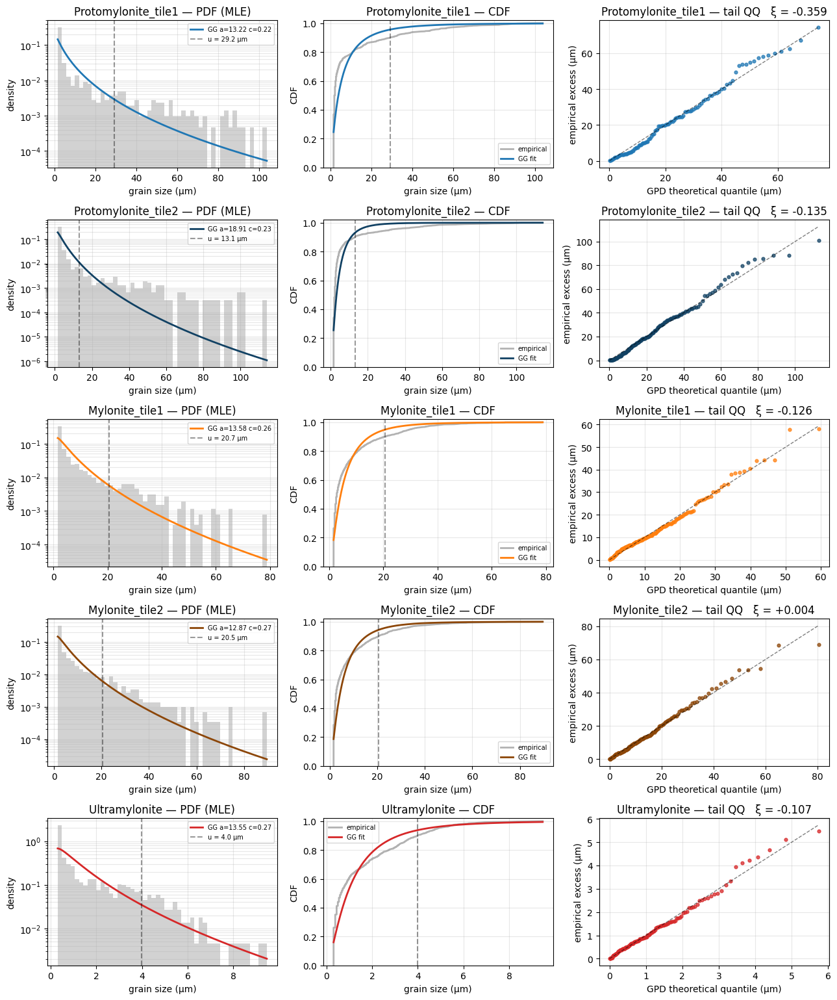

In [ ]:
# ──────────────────────────────────────────────────────────────────────
# Standard MLE diagnostics for the Bruce Hobbs framework
#
#   PDF  — grain-size histogram (gray) vs fitted Generalised-Gamma density
#          (colour). On log-y, the fitted curve should hug the histogram
#          through the bulk; deviation in the far right tail is where the
#          GPD fit takes over.
#   CDF  — empirical step CDF (gray) vs fitted GG CDF (colour). Sustained
#          gaps = the GG doesn't describe that part of the distribution.
#   QQ   — sorted empirical EXCESSES above threshold u vs the corresponding
#          GPD theoretical quantiles. If GPD models the tail, points fall on
#          the y = x line. Points curving UP at the right = real tail heavier
#          than fit (still headed Fréchet-wards); curving DOWN = bounded /
#          Weibull-like tail.
# ──────────────────────────────────────────────────────────────────────
from scipy import stats


def fit_grain_size_family(sizes_um, tail_quantile=0.90, min_excess=30):
    x = sizes_um[sizes_um > np.percentile(sizes_um, 2)]
    try:
        a_gg, c_gg, _, scale_gg = stats.gengamma.fit(x, floc=0)
    except Exception:
        a_gg = c_gg = scale_gg = np.nan
    u = float(np.quantile(x, tail_quantile))
    excesses = x[x > u] - u
    try:
        xi, _, scale_gpd = stats.genpareto.fit(excesses, floc=0)
    except Exception:
        xi = scale_gpd = np.nan
    return {'gg': (a_gg, c_gg, scale_gg), 'u': u, 'xi': float(xi),
            'scale_gpd': float(scale_gpd),
            'excesses': excesses, 'x': x, 'n_excess': int(len(excesses))}


# Per-sample fits
fits = {}
for name, d in samples.items():
    step = d['ebsd']['meta']['xstep']
    sizes_px = np.bincount(d['grain_id'].ravel())[1:]    # drop label 0 = background
    sizes_px = sizes_px[sizes_px > 0]
    ecd = 2.0 * np.sqrt(sizes_px / np.pi) * step          # equivalent-circle diameter (µm)
    fits[name] = fit_grain_size_family(ecd)


# Summary table
print(f"{'sample':<22s} {'n':>6s} {'median µm':>10s} "
      f"{'GG a':>6s} {'GG c':>6s} {'u (µm)':>8s} "
      f"{'ξ':>8s} {'regime':>10s}")
for name, f in fits.items():
    a_gg, c_gg, _ = f['gg']
    xi = f['xi']
    regime = 'Fréchet' if xi > 0.05 else ('Weibull' if xi < -0.05 else 'Gumbel')
    print(f"{name:<22s} {len(f['x']):>6d} {np.median(f['x']):>10.2f} "
          f"{a_gg:>6.2f} {c_gg:>6.2f} {f['u']:>8.2f} "
          f"{xi:>+8.3f} {regime:>10s}")


# Per-sample diagnostic plots (5 rows × 3 cols)
n = len(fits)
fig, axs = plt.subplots(n, 3, figsize=(13, 3.1 * n), squeeze=False)
for row, (name, f) in enumerate(fits.items()):
    col, _ = sample_style(name)
    x = f['x']
    a, c, scale = f['gg']
    u, xi, scale_gpd = f['u'], f['xi'], f['scale_gpd']

    # ----- PDF
    ax = axs[row, 0]
    bins = np.linspace(x.min(), x.max(), 50)
    ax.hist(x, bins=bins, density=True, alpha=0.35, color='gray', edgecolor='none')
    xr = np.linspace(max(x.min(), 1e-3), x.max(), 300)
    ax.plot(xr, stats.gengamma.pdf(xr, a, c, scale=scale),
            '-', color=col, lw=2, label=f'GG a={a:.2f} c={c:.2f}')
    ax.axvline(u, ls='--', color='k', alpha=0.4, label=f'u = {u:.1f} µm')
    ax.set(xlabel='grain size (µm)', ylabel='density',
           title=f'{name} — PDF (MLE)')
    ax.set_yscale('log')
    ax.legend(fontsize=7); ax.grid(True, which='both', alpha=0.3)

    # ----- CDF
    ax = axs[row, 1]
    x_sorted = np.sort(x)
    cdf_emp = np.arange(1, len(x_sorted) + 1) / len(x_sorted)
    ax.plot(x_sorted, cdf_emp, '-', color='gray', lw=2, alpha=0.6, label='empirical')
    ax.plot(xr, stats.gengamma.cdf(xr, a, c, scale=scale),
            '-', color=col, lw=2, label='GG fit')
    ax.axvline(u, ls='--', color='k', alpha=0.4)
    ax.set(xlabel='grain size (µm)', ylabel='CDF',
           title=f'{name} — CDF')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3); ax.set_ylim(0, 1.02)

    # ----- QQ plot of the GPD-fit tail
    ax = axs[row, 2]
    excesses = np.sort(f['excesses'])
    if len(excesses) >= 5 and np.isfinite(xi) and np.isfinite(scale_gpd):
        n_ex = len(excesses)
        q_th = stats.genpareto.ppf((np.arange(1, n_ex + 1) - 0.5) / n_ex,
                                    xi, loc=0, scale=scale_gpd)
        ax.plot(q_th, excesses, 'o', color=col, ms=3.5, alpha=0.75)
        mn = min(q_th.min(), excesses.min())
        mx = max(q_th.max(), excesses.max())
        ax.plot([mn, mx], [mn, mx], 'k--', alpha=0.5, lw=1)
    ax.set(xlabel='GPD theoretical quantile (µm)',
           ylabel='empirical excess (µm)',
           title=f'{name} — tail QQ   ξ = {xi:+.3f}')
    ax.grid(True, alpha=0.3)

fig.tight_layout()

In [ ]:
# Sanity checks: fit the three nested special cases and compare log-likelihoods
for name, f in fits.items():
    x = f['x']
    ll_gg   = stats.gengamma.logpdf(x, *f['gg'][:2], scale=f['gg'][2]).sum()
    p_w     = stats.weibull_min.fit(x, floc=0)
    ll_w    = stats.weibull_min.logpdf(x, *p_w).sum()
    p_g     = stats.gamma.fit(x, floc=0)
    ll_g    = stats.gamma.logpdf(x, *p_g).sum()
    p_ln    = stats.lognorm.fit(x, floc=0)
    ll_ln   = stats.lognorm.logpdf(x, *p_ln).sum()
    print(f"{name:<22s}  logL: GG={ll_gg:8.1f}  Weibull={ll_w:8.1f}  "
          f"Gamma={ll_g:8.1f}  LogN={ll_ln:8.1f}")

Protomylonite_tile1     logL: GG= -2977.9  Weibull= -3139.9  Gamma= -3199.9  LogN= -2917.0
Protomylonite_tile2     logL: GG= -3471.6  Weibull= -3783.3  Gamma= -3854.9  LogN= -3376.1
Mylonite_tile1          logL: GG= -4692.2  Weibull= -4903.2  Gamma= -4919.5  LogN= -4622.4
Mylonite_tile2          logL: GG= -4786.5  Weibull= -5000.8  Gamma= -5023.9  LogN= -4713.0
Ultramylonite           logL: GG= -1563.0  Weibull= -1663.2  Gamma= -1659.3  LogN= -1531.6


Ultramylonite: only 4 blocks — skipped
sample                  # blocks  block µm    GEV ξ   GEV loc  GEV scale    GPD ξ      regime
Protomylonite_tile1          105      50.0   -0.441     75.62      14.76   -0.359     Weibull
Protomylonite_tile2           98      50.0   -0.610     82.33      21.37   -0.135     Weibull
Mylonite_tile1                90      50.0   -0.208     47.93      14.27   -0.126     Weibull
Mylonite_tile2                95      50.0   -0.316     55.50      16.66   +0.004     Weibull


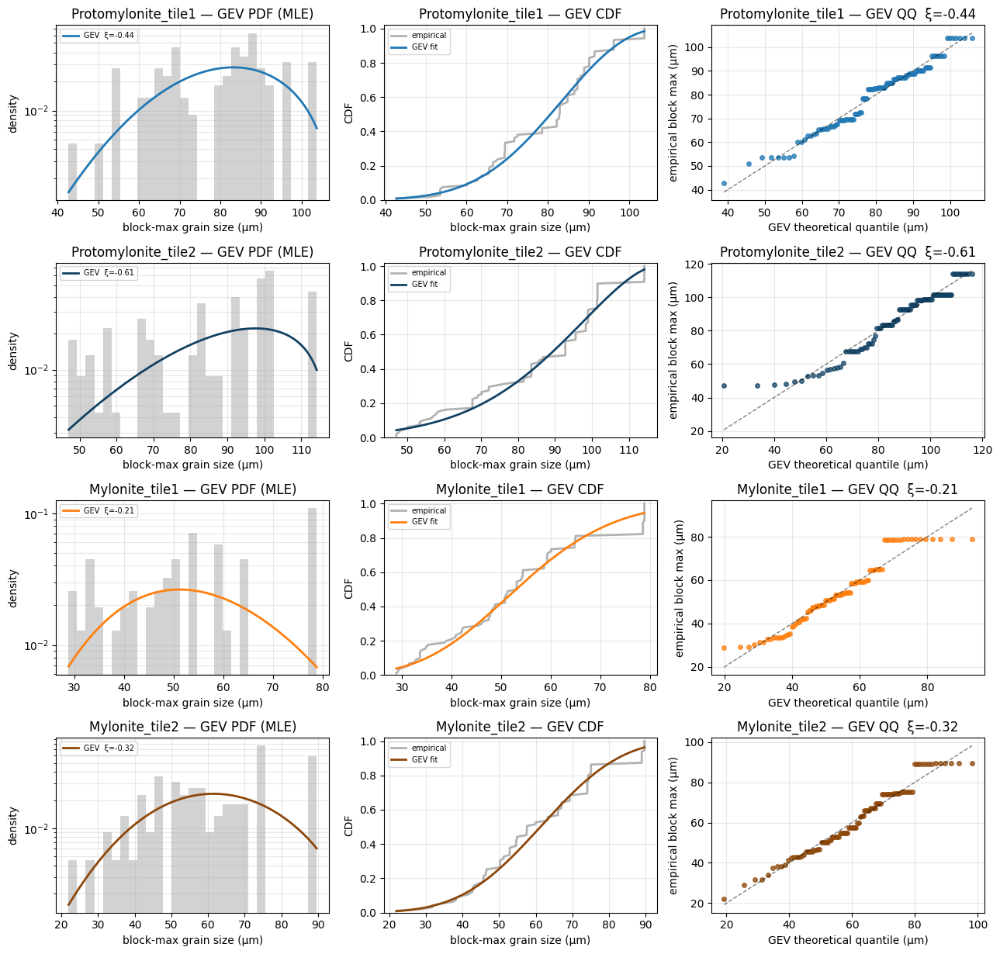

In [ ]:
# ──────────────────────────────────────────────────────────────────────
# GEV block-maxima fit — alternative to the GPD peaks-over-threshold
# approach in the previous cell. For i.i.d. exceedances the GEV shape ξ
# of the block-max distribution equals the GPD shape ξ of the tail, so
# getting the two fits to agree is a useful sanity check.
#
# Convention warning (important):
#   scipy.stats.genextreme.c = -ξ in the Coles (2001) / EV-textbook sense
#     scipy.c < 0  →  ξ > 0  →  Fréchet (heavy tail)
#     scipy.c = 0  →  ξ = 0  →  Gumbel
#     scipy.c > 0  →  ξ < 0  →  Weibull (bounded)
# We report ξ = -scipy.c so it matches the GPD ξ from the prev. cell.
# ──────────────────────────────────────────────────────────────────────
from scipy import stats

# Physical block size (µm). Rule of thumb: a few times the median grain
# size. Smaller = more blocks (better MLE) but less "independent"; larger
# = fewer blocks but each block more likely to contain a full grain.
BLOCK_UM = 50.0


def block_maxima_spatial(grain_id, block_size_px):
    # Max grain size (in pixels) found inside each non-overlapping square
    # block of side block_size_px. Skips blocks with no indexed grains.
    sizes = np.bincount(grain_id.ravel())
    ny, nx = grain_id.shape
    maxima = []
    for i in range(0, ny - block_size_px + 1, block_size_px):
        for j in range(0, nx - block_size_px + 1, block_size_px):
            b = grain_id[i:i+block_size_px, j:j+block_size_px]
            gids = np.unique(b)
            gids = gids[gids > 0]
            if len(gids) == 0:
                continue
            maxima.append(max(sizes[g] for g in gids))
    return np.array(maxima)


# Fit per sample
gev_fits = {}
for name, d in samples.items():
    step = d['ebsd']['meta']['xstep']
    block_px = max(5, int(round(BLOCK_UM / step)))
    max_px = block_maxima_spatial(d['grain_id'], block_px)
    if len(max_px) < 10:
        print(f'{name}: only {len(max_px)} blocks — skipped')
        continue
    ecd = 2.0 * np.sqrt(max_px / np.pi) * step          # ECD in µm
    try:
        c_sp, loc_gev, scale_gev = stats.genextreme.fit(ecd)
        xi = -c_sp                                        # Coles ξ
    except Exception:
        c_sp = loc_gev = scale_gev = xi = np.nan
    gev_fits[name] = {'maxima': ecd, 'n_blocks': len(ecd), 'block_px': block_px,
                      'c_scipy': c_sp, 'xi': xi,
                      'loc': loc_gev, 'scale': scale_gev}


# Summary: GEV ξ (block maxima) alongside the GPD ξ (POT) from the prev cell
print(f"{'sample':<22s} {'# blocks':>9s} {'block µm':>9s} "
      f"{'GEV ξ':>8s} {'GEV loc':>9s} {'GEV scale':>10s} "
      f"{'GPD ξ':>8s}  {'regime':>10s}")
for name, g in gev_fits.items():
    gpd_xi = fits[name]['xi'] if 'fits' in dir() and name in fits else float('nan')
    r = 'Fréchet' if g['xi'] > 0.05 else ('Weibull' if g['xi'] < -0.05 else 'Gumbel')
    print(f"{name:<22s} {g['n_blocks']:>9d} "
          f"{g['block_px'] * samples[name]['ebsd']['meta']['xstep']:>9.1f} "
          f"{g['xi']:>+8.3f} {g['loc']:>9.2f} {g['scale']:>10.2f} "
          f"{gpd_xi:>+8.3f}  {r:>10s}")


# Standard PDF / CDF / QQ diagnostics for the GEV fits
n = len(gev_fits)
fig, axs = plt.subplots(n, 3, figsize=(13, 3.1 * n), squeeze=False)
for row, (name, g) in enumerate(gev_fits.items()):
    col, _ = sample_style(name)
    x = g['maxima']
    c_sp, loc_gev, scale_gev, xi = g['c_scipy'], g['loc'], g['scale'], g['xi']

    # PDF
    ax = axs[row, 0]
    bins = np.linspace(x.min(), x.max(), 30)
    ax.hist(x, bins=bins, density=True, alpha=0.35, color='gray', edgecolor='none')
    xr = np.linspace(x.min(), x.max(), 400)
    ax.plot(xr, stats.genextreme.pdf(xr, c_sp, loc=loc_gev, scale=scale_gev),
            '-', color=col, lw=2, label=f'GEV  ξ={xi:+.2f}')
    ax.set(xlabel='block-max grain size (µm)', ylabel='density',
           title=f'{name} — GEV PDF (MLE)')
    ax.set_yscale('log')
    ax.legend(fontsize=7); ax.grid(True, which='both', alpha=0.3)

    # CDF
    ax = axs[row, 1]
    xs = np.sort(x)
    emp = np.arange(1, len(xs) + 1) / len(xs)
    ax.plot(xs, emp, '-', color='gray', lw=2, alpha=0.6, label='empirical')
    ax.plot(xr, stats.genextreme.cdf(xr, c_sp, loc=loc_gev, scale=scale_gev),
            '-', color=col, lw=2, label='GEV fit')
    ax.set(xlabel='block-max grain size (µm)', ylabel='CDF',
           title=f'{name} — GEV CDF')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3); ax.set_ylim(0, 1.02)

    # QQ
    ax = axs[row, 2]
    n_b = len(xs)
    q_th = stats.genextreme.ppf((np.arange(1, n_b + 1) - 0.5) / n_b,
                                  c_sp, loc=loc_gev, scale=scale_gev)
    ax.plot(q_th, xs, 'o', color=col, ms=4, alpha=0.75)
    mn = min(q_th.min(), xs.min()); mx = max(q_th.max(), xs.max())
    ax.plot([mn, mx], [mn, mx], 'k--', alpha=0.5, lw=1)
    ax.set(xlabel='GEV theoretical quantile (µm)',
           ylabel='empirical block max (µm)',
           title=f'{name} — GEV QQ  ξ={xi:+.2f}')
    ax.grid(True, alpha=0.3)

fig.tight_layout()

sample                  n tail   u (µm)    GEV ξ    GEV μ    GEV σ    GPD ξ      regime
Protomylonite_tile1         31    58.21   -0.063    70.17    10.28   -0.359     Weibull
Protomylonite_tile2         41    47.24   +0.671    55.25     8.88   -0.135     Fréchet
Mylonite_tile1              50    35.69   +0.470    41.03     5.61   -0.126     Fréchet
Mylonite_tile2              50    36.02   +0.323    44.25     7.55   +0.004     Fréchet
Ultramylonite               36     5.47   +0.499     5.99     0.55   -0.107     Fréchet


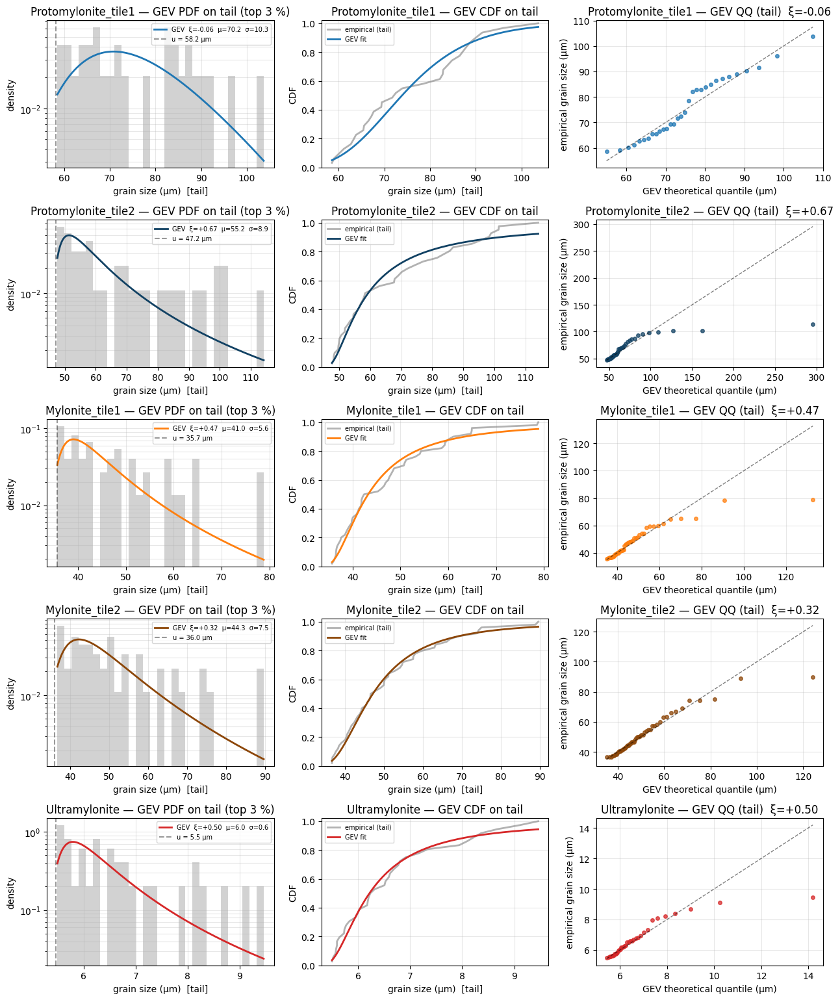

In [ ]:
# ──────────────────────────────────────────────────────────────────────
# GEV fit to the TAIL of the grain-size distribution (Hobbs framing:
# GEV describes the extremes, GG describes the bulk).
#
# Methodology: pick a tail threshold u (same quantile as the GPD POT fit
# in the previous cell so they're directly comparable), subset to
# x > u, MLE a GEV on that tail sample.
#
# Convention: ξ = -scipy.c  →  ξ > 0 Fréchet, ξ = 0 Gumbel, ξ < 0 Weibull.
# ──────────────────────────────────────────────────────────────────────
from scipy import stats

TAIL_QUANTILE = 0.97    # top 10 % = "the tail"

gev_tail_fits = {}
for name, d in samples.items():
    step = d['ebsd']['meta']['xstep']
    sizes_px = np.bincount(d['grain_id'].ravel())[1:]
    sizes_px = sizes_px[sizes_px > 0]
    ecd = 2.0 * np.sqrt(sizes_px / np.pi) * step
    x = ecd[ecd > np.percentile(ecd, 2)]     # drop single-pixel indexing noise
    u = float(np.quantile(x, TAIL_QUANTILE))
    tail = x[x > u]
    if len(tail) < 20:
        print(f'{name}: only {len(tail)} tail points, skipped')
        continue
    try:
        c_sp, loc_gev, scale_gev = stats.genextreme.fit(tail)
        xi = -c_sp
    except Exception:
        c_sp = loc_gev = scale_gev = xi = np.nan
    gev_tail_fits[name] = {'tail': tail, 'u': u, 'n_tail': len(tail),
                            'c_scipy': c_sp, 'xi': xi,
                            'loc': loc_gev, 'scale': scale_gev}


# Summary — GEV ξ on the tail, next to the GPD ξ from the POT cell
print(f"{'sample':<22s} {'n tail':>7s} {'u (µm)':>8s} "
      f"{'GEV ξ':>8s} {'GEV μ':>8s} {'GEV σ':>8s} "
      f"{'GPD ξ':>8s}  {'regime':>10s}")
for name, g in gev_tail_fits.items():
    gpd_xi = fits[name]['xi'] if 'fits' in dir() and name in fits else float('nan')
    r = 'Fréchet' if g['xi'] > 0.05 else ('Weibull' if g['xi'] < -0.05 else 'Gumbel')
    print(f"{name:<22s} {g['n_tail']:>7d} {g['u']:>8.2f} "
          f"{g['xi']:>+8.3f} {g['loc']:>8.2f} {g['scale']:>8.2f} "
          f"{gpd_xi:>+8.3f}  {r:>10s}")


# PDF / CDF / QQ diagnostics on the tail sample
n = len(gev_tail_fits)
fig, axs = plt.subplots(n, 3, figsize=(13, 3.1 * n), squeeze=False)
for row, (name, g) in enumerate(gev_tail_fits.items()):
    col, _ = sample_style(name)
    x = g['tail']
    c_sp, loc_gev, scale_gev, xi = g['c_scipy'], g['loc'], g['scale'], g['xi']

    # PDF
    ax = axs[row, 0]
    bins = np.linspace(x.min(), x.max(), 30)
    ax.hist(x, bins=bins, density=True, alpha=0.35, color='gray', edgecolor='none')
    xr = np.linspace(x.min(), x.max(), 400)
    ax.plot(xr, stats.genextreme.pdf(xr, c_sp, loc=loc_gev, scale=scale_gev),
            '-', color=col, lw=2,
            label=f'GEV  ξ={xi:+.2f}  μ={loc_gev:.1f}  σ={scale_gev:.1f}')
    ax.axvline(g['u'], ls='--', color='k', alpha=0.4, label=f'u = {g["u"]:.1f} µm')
    ax.set(xlabel='grain size (µm)  [tail]', ylabel='density',
           title=f'{name} — GEV PDF on tail (top {int(100*(1-TAIL_QUANTILE))} %)')
    ax.set_yscale('log')
    ax.legend(fontsize=7); ax.grid(True, which='both', alpha=0.3)

    # CDF
    ax = axs[row, 1]
    xs = np.sort(x)
    emp = np.arange(1, len(xs) + 1) / len(xs)
    ax.plot(xs, emp, '-', color='gray', lw=2, alpha=0.6, label='empirical (tail)')
    ax.plot(xr, stats.genextreme.cdf(xr, c_sp, loc=loc_gev, scale=scale_gev),
            '-', color=col, lw=2, label='GEV fit')
    ax.set(xlabel='grain size (µm)  [tail]', ylabel='CDF',
           title=f'{name} — GEV CDF on tail')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3); ax.set_ylim(0, 1.02)

    # QQ
    ax = axs[row, 2]
    n_b = len(xs)
    q_th = stats.genextreme.ppf((np.arange(1, n_b + 1) - 0.5) / n_b,
                                  c_sp, loc=loc_gev, scale=scale_gev)
    ax.plot(q_th, xs, 'o', color=col, ms=4, alpha=0.75)
    mn = min(q_th.min(), xs.min()); mx = max(q_th.max(), xs.max())
    ax.plot([mn, mx], [mn, mx], 'k--', alpha=0.5, lw=1)
    ax.set(xlabel='GEV theoretical quantile (µm)',
           ylabel='empirical grain size (µm)',
           title=f'{name} — GEV QQ (tail)  ξ={xi:+.2f}')
    ax.grid(True, alpha=0.3)

fig.tight_layout()

/Users/amasaryk/miniforge/envs/xsmurf/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:1325: RuntimeWarning: overflow encountered in power
  return np.log(c) + np.log(d) + sc.xlogy(c - 1, x) + sc.xlog1py(-d-1, x**c)


sample                  top-3 fits (AIC lower = better)                             
Protomylonite_tile1     GEV (ΔAIC=+0.0), Pareto I (ΔAIC=+6001.3), Pareto IV (ΔAIC=+6072.5)
Protomylonite_tile2     GEV (ΔAIC=+0.0), Pareto I (ΔAIC=+11254.8), Pareto IV (ΔAIC=+11368.4)
Mylonite_tile1          GEV (ΔAIC=+0.0), Pareto I (ΔAIC=+7914.4), Pareto IV (ΔAIC=+8007.8)
Mylonite_tile2          GEV (ΔAIC=+0.0), Pareto I (ΔAIC=+7626.8), Pareto IV (ΔAIC=+7725.9)
Ultramylonite           GEV (ΔAIC=+0.0), Pareto I (ΔAIC=+5302.9), Pareto IV (ΔAIC=+5360.7)


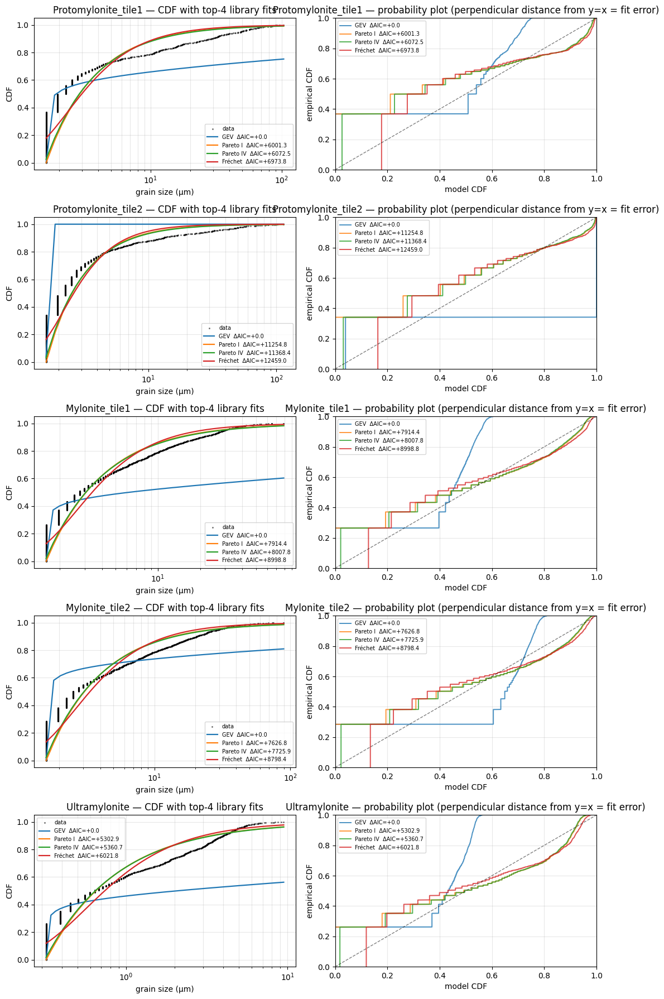

In [ ]:
# ──────────────────────────────────────────────────────────────────────
# Ord, Blenkinsop & Hobbs (2022) methodology — fit a LIBRARY of
# candidate distributions to each grain-size sample, rank by AIC, pick
# the winning family per sample. Report the top three fits with the
# standard PDF + probability-plot (Q-Q) diagnostics they show in Fig 6.
#
# Library (scipy equivalents of the Ord et al. Table 2 list):
#   Fréchet        — stats.invweibull        Weibull        — stats.weibull_min
#   Exponential    — stats.expon             Gamma          — stats.gamma
#   Gen. Gamma     — stats.gengamma          Gumbel         — stats.gumbel_r
#   Log-normal     — stats.lognorm           Pareto I       — stats.pareto
#   Pareto II/Lomax— stats.lomax             Pareto IV/Burr — stats.burr12
#   GEV            — stats.genextreme        Gen. Pareto    — stats.genpareto
# ──────────────────────────────────────────────────────────────────────
from scipy import stats

LIBRARY = {
    'Fréchet':     (stats.invweibull,  {'floc': 0}),
    'Weibull':     (stats.weibull_min, {'floc': 0}),
    'Exponential': (stats.expon,       {'floc': 0}),
    'Gamma':       (stats.gamma,       {'floc': 0}),
    'GenGamma':    (stats.gengamma,    {'floc': 0}),
    'Gumbel':      (stats.gumbel_r,    {}),
    'LogNormal':   (stats.lognorm,     {'floc': 0}),
    'Pareto I':    (stats.pareto,      {'floc': 0}),
    'Pareto II':   (stats.lomax,       {'floc': 0}),
    'Pareto IV':   (stats.burr12,      {'floc': 0}),
    'GEV':         (stats.genextreme,  {}),
    'GenPareto':   (stats.genpareto,   {'floc': 0}),
}

def rank_library(x):
    results = {}
    for name, (dist, kwargs) in LIBRARY.items():
        try:
            params = dist.fit(x, **kwargs)
            ll = dist.logpdf(x, *params).sum()
            k  = len(params) - sum(1 for kw in kwargs if kw.startswith('f'))
            if not np.isfinite(ll):
                continue
            aic = 2 * k - 2 * ll
            results[name] = {'dist': dist, 'params': params,
                             'll': float(ll), 'k': int(k), 'aic': float(aic)}
        except Exception:
            continue
    return results


# Fit + rank per sample
library_fits = {}
for name, d in samples.items():
    step = d['ebsd']['meta']['xstep']
    sizes_px = np.bincount(d['grain_id'].ravel())[1:]
    sizes_px = sizes_px[sizes_px > 0]
    ecd = 2.0 * np.sqrt(sizes_px / np.pi) * step
    x = ecd[ecd > np.percentile(ecd, 2)]
    results = rank_library(x)
    # Sort by AIC (lowest = best)
    ranked = sorted(results.items(), key=lambda kv: kv[1]['aic'])
    library_fits[name] = {'x': x, 'ranked': ranked}


# Report: per sample, top 3 fits
print(f"{'sample':<22s}  {'top-3 fits (AIC lower = better)':<60s}")
for name, f in library_fits.items():
    top3 = ', '.join(f"{nm} (ΔAIC={info['aic']-f['ranked'][0][1]['aic']:+.1f})"
                      for nm, info in f['ranked'][:3])
    print(f"{name:<22s}  {top3}")


# Per-sample diagnostic: probability plot (Q-Q) with the top 4 candidates
# overlaid, exactly like Ord et al. Fig 6(b). Points on the diagonal =
# good fit; systematic departure = poor fit.
n = len(library_fits)
fig, axs = plt.subplots(n, 2, figsize=(11, 3.6 * n), squeeze=False)
for row, (name, f) in enumerate(library_fits.items()):
    x = f['x']
    xs = np.sort(x)
    emp = (np.arange(1, len(xs) + 1) - 0.5) / len(xs)     # empirical CDF
    top4 = f['ranked'][:4]

    # -- (left) raw CDF with top-4 overlaid (like Ord Fig 6a)
    ax = axs[row, 0]
    ax.plot(xs, emp, 'k.', ms=2.5, alpha=0.4, label='data')
    xr = np.linspace(xs.min(), xs.max(), 400)
    for rk, (nm, info) in enumerate(top4):
        ax.plot(xr, info['dist'].cdf(xr, *info['params']),
                lw=1.6, label=f"{nm}  ΔAIC={info['aic']-top4[0][1]['aic']:+.1f}")
    ax.set(xlabel='grain size (µm)', ylabel='CDF',
           title=f'{name} — CDF with top-4 library fits')
    ax.set_xscale('log'); ax.legend(fontsize=7); ax.grid(True, which='both', alpha=0.3)

    # -- (right) probability plot (Q-Q) — Ord Fig 6b style
    ax = axs[row, 1]
    for rk, (nm, info) in enumerate(top4):
        # "probability axis": empirical CDF vs model CDF at each data point
        model_cdf = info['dist'].cdf(xs, *info['params'])
        ax.plot(model_cdf, emp, lw=1.4, alpha=0.8,
                label=f"{nm}  ΔAIC={info['aic']-top4[0][1]['aic']:+.1f}")
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, lw=1)
    ax.set(xlabel='model CDF', ylabel='empirical CDF',
           title=f'{name} — probability plot (perpendicular distance from y=x = fit error)',
           xlim=(0, 1), ylim=(0, 1))
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

fig.tight_layout()

sample                 edge grains  edge px %  ALL top-3                                 INTERIOR top-3                          
Protomylonite_tile1     123/3032 (4%)     26.2%  GEV, Pareto I, Pareto IV                  GEV, Pareto I, Pareto IV                
Protomylonite_tile2     112/3532 (3%)     30.5%  GEV, Pareto I, Pareto IV                  GEV, Pareto I, Pareto IV                
Mylonite_tile1          182/4322 (4%)     14.8%  GEV, Pareto I, Pareto IV                  GEV, Pareto I, Pareto IV                
Mylonite_tile2          255/4421 (6%)     12.7%  GEV, Pareto I, Pareto IV                  GEV, Pareto I, Pareto IV                
Ultramylonite            73/2920 (2%)      1.4%  GEV, Pareto I, Pareto IV                  GEV, Pareto I, Pareto IV                


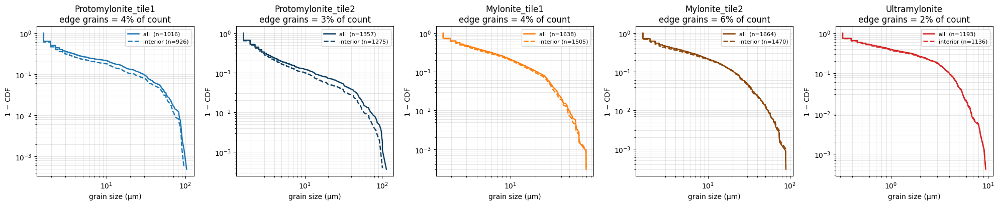

In [ ]:
# ──────────────────────────────────────────────────────────────────────
# Edge-grain bias check.
# A grain that touches row 0/row -1/col 0/col -1 is truncated: we report
# its intersection with the map rather than its true size. This biases
# the tail DOWN, because large grains are more likely to touch an edge.
# Compare library rankings on (a) ALL grains vs (b) INTERIOR grains only.
# ──────────────────────────────────────────────────────────────────────

def edge_grain_ids(grain_id):
    edges = np.concatenate([
        grain_id[0, :],   grain_id[-1, :],
        grain_id[:,  0],  grain_id[:,  -1],
    ])
    return np.unique(edges[edges > 0])


# Refit the library on (a) all grains and (b) interior-only
library_fits_cmp = {}
for name, d in samples.items():
    step = d['ebsd']['meta']['xstep']
    gid = d['grain_id']
    sizes = np.bincount(gid.ravel())         # idx 0 = background
    edge_ids = edge_grain_ids(gid)

    # (a) ALL grains (what we've been doing)
    sizes_all = sizes[1:].copy()
    sizes_all = sizes_all[sizes_all > 0]
    ecd_all = 2.0 * np.sqrt(sizes_all / np.pi) * step
    x_all = ecd_all[ecd_all > np.percentile(ecd_all, 2)]

    # (b) INTERIOR only
    interior_ids = np.setdiff1d(np.arange(1, len(sizes)), edge_ids)
    sizes_int = sizes[interior_ids]
    sizes_int = sizes_int[sizes_int > 0]
    ecd_int = 2.0 * np.sqrt(sizes_int / np.pi) * step
    x_int = ecd_int[ecd_int > np.percentile(ecd_int, 2)] if len(ecd_int) > 20 else ecd_int

    library_fits_cmp[name] = {
        'x_all': x_all,        'x_int': x_int,
        'ranked_all': sorted(rank_library(x_all).items(), key=lambda kv: kv[1]['aic']),
        'ranked_int': sorted(rank_library(x_int).items(), key=lambda kv: kv[1]['aic']),
        'n_edge': len(edge_ids),
        'n_total_grains': len(sizes) - 1,
        'edge_pixel_fraction': np.isin(gid, edge_ids).sum() / gid.size,
    }


# Report: what fraction are edge grains, and do the winning families shift?
print(f"{'sample':<22s} {'edge grains':>11s} {'edge px %':>10s}  "
      f"{'ALL top-3':<40s}  {'INTERIOR top-3':<40s}")
for name, f in library_fits_cmp.items():
    frac_grains = f['n_edge'] / max(f['n_total_grains'], 1)
    all3 = ', '.join(nm for nm, _ in f['ranked_all'][:3])
    int3 = ', '.join(nm for nm, _ in f['ranked_int'][:3])
    print(f"{name:<22s} {f['n_edge']:>4d}/{f['n_total_grains']:<4d} "
          f"({100*frac_grains:.0f}%) {100*f['edge_pixel_fraction']:>8.1f}%  "
          f"{all3:<40s}  {int3:<40s}")


# Overlay the CDFs from both versions on a single figure per sample,
# so you can see how much the tail actually shifts
n = len(library_fits_cmp)
fig, axs = plt.subplots(1, n, figsize=(4 * n, 4.2), squeeze=False)
for i, (name, f) in enumerate(library_fits_cmp.items()):
    col, _ = sample_style(name)
    ax = axs[0, i]
    xa = np.sort(f['x_all']);  ca = (np.arange(len(xa)) + 0.5) / len(xa)
    xb = np.sort(f['x_int']);  cb = (np.arange(len(xb)) + 0.5) / len(xb)
    ax.plot(xa, 1 - ca, '-',  color=col, lw=1.8, label=f'all  (n={len(xa)})')
    ax.plot(xb, 1 - cb, '--', color=col, lw=1.8, label=f'interior (n={len(xb)})')
    ax.set(xlabel='grain size (µm)', ylabel='1 − CDF',
           title=f'{name}\nedge grains = {100*f["n_edge"]/max(f["n_total_grains"],1):.0f}% of count')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()

Protomylonite_tile1     φ=0.955  best blobiness=1.30  L2 mismatch=6.45e-06  voxel=1.72 µm
Protomylonite_tile2     φ=0.842  best blobiness=1.27  L2 mismatch=1.70e-04  voxel=1.72 µm
Mylonite_tile1          φ=0.886  best blobiness=0.94  L2 mismatch=5.83e-05  voxel=1.20 µm
Mylonite_tile2          φ=0.904  best blobiness=1.02  L2 mismatch=3.54e-05  voxel=1.20 µm
Ultramylonite           φ=0.234  best blobiness=1.65  L2 mismatch=1.15e-03  voxel=0.66 µm


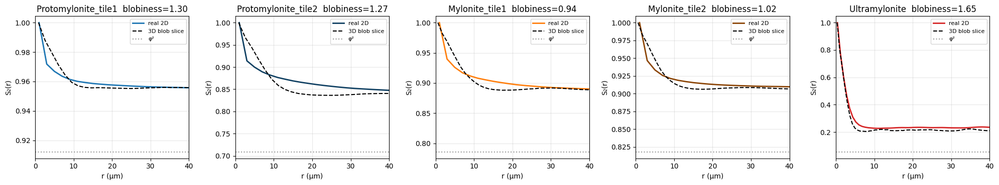

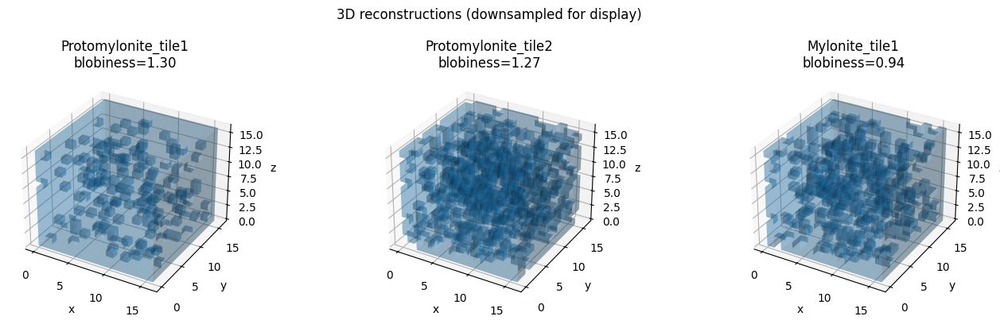

In [ ]:
# ──────────────────────────────────────────────────────────────────────
# Forward-match a 3D Gaussian-random-field blobs model to each KMZ sample.
# Target: the measured target-phase fraction φ and isotropic S₂(r).
# Generator: porespy.generators.blobs — a thresholded anisotropic noise
# field whose 'blobiness' parameter controls the characteristic feature
# size. Increasing blobiness shrinks features; decreasing it grows them.
# The 2D slice S₂(r) of the 3D volume should match the 2D S₂(r) of the
# original EBSD if the microstructure is reasonably isotropic.
# ──────────────────────────────────────────────────────────────────────
import porespy as ps
# Skip if any sample lacks a target_mask (no phase matched TARGET_PHASE_NAME)
_missing = [t for t, d in samples.items() if d.get('target_mask') is None]
if _missing:
    raise RuntimeError(f'No target phase set for {_missing}.  '
                        f'Edit TARGET_PHASE_NAME in cell 6 / 8 or call '
                        f'switch_target_phase(samples, "<phase>").')
from scipy import optimize


def tune_blobiness(target_phi, target_s2, target_r, shape=(128, 128, 128),
                    seed=0):
    def cost(b):
        im = ps.generators.blobs(shape=shape, porosity=target_phi,
                                  blobiness=float(b), seed=seed)
        # Central slice S₂
        s2 = ps.metrics.two_point_correlation(im[shape[0] // 2])
        # Interpolate to target r grid and compute L2 mismatch
        s2_interp = np.interp(target_r, s2.distance, s2.probability,
                               right=target_phi ** 2)
        return np.mean((s2_interp - target_s2) ** 2)
    res = optimize.minimize_scalar(cost, bounds=(0.2, 3.0), method='bounded',
                                    options={'xatol': 0.05})
    return float(res.x), float(res.fun)


recon_3d = {}
for name, d in samples.items():
    step = d['ebsd']['meta']['xstep']
    mask = d['target_mask']
    phi  = float(mask.mean())

    # Measured 2D S₂ of the real sample
    s2_2d = ps.metrics.two_point_correlation(mask)
    r_um = s2_2d.distance * step

    # Tune blobiness to match — units: all r in 'pixels' of the synthetic
    # volume. To match physical scales, rescale r_um to synthetic pixels
    # assuming the 128³ volume represents ~max(r_um) µm in each direction.
    max_r_um = np.quantile(r_um, 0.6)                # fit only bulk of S₂
    pix_um = max_r_um / 64                            # synthetic voxel size (µm)
    target_r_px = r_um[r_um < max_r_um] / pix_um
    target_s2   = s2_2d.probability[r_um < max_r_um]

    best_b, resid = tune_blobiness(phi, target_s2, target_r_px)

    # Generate final 3D with the tuned blobiness
    vol = ps.generators.blobs(shape=(128, 128, 128), porosity=phi,
                               blobiness=best_b, seed=0)
    recon_3d[name] = {'blobiness': best_b, 'residual': resid,
                       'pix_um': pix_um, 'volume': vol, 'phi': phi}
    print(f'{name:<22s}  φ={phi:.3f}  best blobiness={best_b:.2f}  '
          f'L2 mismatch={resid:.2e}  voxel={pix_um:.2f} µm')


# Diagnostic: compare real 2D S₂ to 3D slice S₂ for each sample
fig, axs = plt.subplots(1, len(recon_3d), figsize=(4 * len(recon_3d), 3.8),
                         squeeze=False)
for i, (name, r) in enumerate(recon_3d.items()):
    ax = axs[0, i]
    col, _ = sample_style(name)
    # Real S₂
    mask = samples[name]['target_mask']
    step = samples[name]['ebsd']['meta']['xstep']
    s2_real = ps.metrics.two_point_correlation(mask)
    ax.plot(s2_real.distance * step, s2_real.probability, '-',
            color=col, lw=2, label='real 2D')
    # 3D slice S₂
    vol = r['volume']
    slice_s2 = ps.metrics.two_point_correlation(vol[vol.shape[0] // 2])
    ax.plot(slice_s2.distance * r['pix_um'], slice_s2.probability, '--',
            color='k', lw=1.5, label='3D blob slice')
    ax.axhline(r['phi'] ** 2, ls=':', color='k', alpha=0.4, label='φ²')
    ax.set(xlabel='r (µm)', ylabel='S₂(r)',
           title=f'{name}  blobiness={r["blobiness"]:.2f}')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_xlim(0, 40)
fig.tight_layout()


# Quick 3D visualisation of one reconstruction
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(14, 4))
for i, (name, r) in enumerate(list(recon_3d.items())[:3]):
    ax = fig.add_subplot(1, 3, i + 1, projection='3d')
    vol = r['volume']
    # Show a triplet of orthogonal slices
    from skimage import measure
    # Just visualise three mid-planes as textured polygons
    ax.voxels(vol[::8, ::8, ::8], alpha=0.25, edgecolor='none', facecolors='C0')
    ax.set_title(f'{name}\nblobiness={r["blobiness"]:.2f}')
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
fig.suptitle('3D reconstructions (downsampled for display)')
fig.tight_layout()

Text(0.5, 1.0, 'Long-range correlation check: straight line = power-law = Hobbs-style')

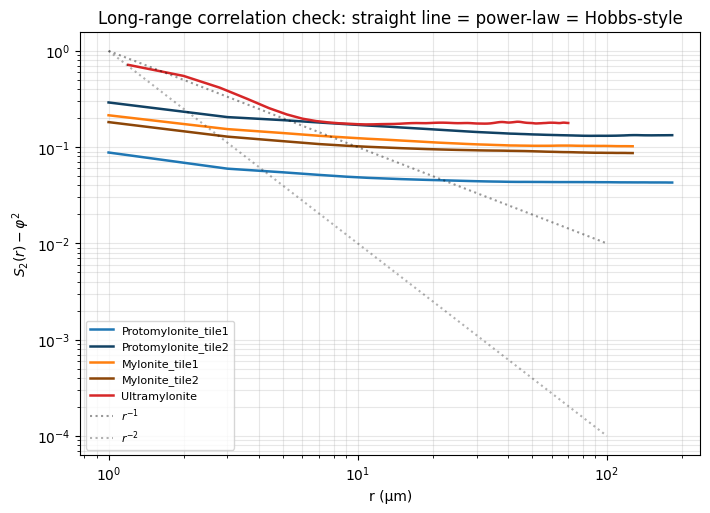

In [ ]:
# ===== S2(r) - φ² long-range power-law check (auto multiphase) =====
# Auto-iterate every (sample, phase) combo. Set ANALYSIS_TARGETS_MIN_PHI
# at the top to filter out tiny phases.
_total_targets = sum(len(d.get('analysis_targets', [])) for d in samples.values())
if _total_targets == 0:
    raise RuntimeError('No analysis_targets found.  Re-run loader (cell 6 or 8).')

fig, ax = plt.subplots(figsize=(8, 5.5))
for tag, t in iter_targets(samples):
    step = samples[tag]['ebsd']['meta']['xstep']
    s2 = ps.metrics.two_point_correlation(t['mask'])
    r_um = s2.distance * step
    delta = s2.probability - t['phi'] ** 2
    ok = (delta > 1e-6) & (r_um > 0.5)
    col = phase_color(t['phase_name'])
    ax.loglog(r_um[ok], delta[ok], '-', color=col, lw=1.5,
               label=pretty_label(tag, t))
ax.loglog([1, 100], [1, 1e-2], 'k:', alpha=0.4, label=r'$r^{-1}$')
ax.loglog([1, 100], [1, 1e-4], 'k:', alpha=0.3, label=r'$r^{-2}$')
ax.set(xlabel='r (µm)', ylabel=r'$S_2(r) - \varphi^2$')
ax.legend(fontsize=7, ncol=2); ax.grid(True, which='both', alpha=0.3)
ax.set_title('Long-range correlation: per (sample × phase)', fontsize=11)
plt.tight_layout(); plt.show()


### Cross-phase 2-point correlation S_AB(r)

For polymineralic aggregates, the 2-point cross-correlation
`S_AB(r) = Pr(point at x is A AND point at x+r is B)` characterizes the
spatial relationship between two different phases — feldspar–quartz
interfaces, mica–quartz proximity, omphacite–garnet contacts, etc.

S_AB has signature behaviours:
- **S_AB(0) = 0** (a pixel can't be in both phases simultaneously).
- **S_AB(r) → φ_A · φ_B as r → ∞** (uncorrelated at long range).
- **Initial rise** captures phase-pair affinity vs. avoidance.

The cross-correlation length where `S_AB` reaches its asymptote is the
characteristic length over which the two phases are spatially separated.
Useful for shear-zone partitioning analysis (e.g., does feldspar form
clumps surrounded by quartz, or are they interspersed?).

In [ ]:
# ===== Cross-phase 2-point correlation S_AB(r) =====
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, ifft2

def cross_2pt(mask_A, mask_B, max_r_frac=0.4):
    """FFT-based S_AB(r) = Pr(x in A AND x+r in B), radially binned."""
    A = mask_A.astype(np.float64)
    B = mask_B.astype(np.float64)
    ny, nx = A.shape
    # Cross-correlation via FFT: F_A(k) * conj(F_B(k))
    FA = fft2(A); FB = fft2(B)
    C = np.real(ifft2(FA * np.conj(FB))) / A.size  # phi_A * phi_B at large r
    C = np.fft.fftshift(C)
    cy, cx = ny // 2, nx // 2
    yy, xx = np.indices(C.shape)
    rr = np.hypot(yy - cy, xx - cx).astype(int)
    r_max = int(min(cy, cx) * max_r_frac)
    out_r = np.arange(r_max)
    out_S = np.zeros(r_max)
    for r in out_r:
        sel = (rr == r)
        if sel.any(): out_S[r] = C[sel].mean()
    return out_r, out_S

# Example: pick two phases by name, plot S_AB(r) per sample
PHASE_A_QUERY = 'quartz'         # change to your phase A
PHASE_B_QUERY = 'orthoclase'     # change to your phase B

def _resolve(info, q):
    for pid, nm in info['phase_names'].items():
        if str(q).lower() in nm.lower():
            return pid
    return None

if 'samples' in dir() and samples:
    fig, ax = plt.subplots(1, 1, figsize=(7, 5), dpi=110)
    for tag, info in samples.items():
        pid_A = _resolve(info, PHASE_A_QUERY)
        pid_B = _resolve(info, PHASE_B_QUERY)
        if pid_A is None or pid_B is None:
            print(f'  {tag}: missing phase ({PHASE_A_QUERY!r}: {pid_A}, '
                  f'{PHASE_B_QUERY!r}: {pid_B})')
            continue
        mA = info['phase_masks'][pid_A]
        mB = info['phase_masks'][pid_B]
        r, S_AB = cross_2pt(mA, mB)
        step = info['ebsd']['meta']['xstep']
        phi_A = info['phi_phases'][pid_A]
        phi_B = info['phi_phases'][pid_B]
        asymp = phi_A * phi_B
        ax.plot(r * step, S_AB, lw=1.5,
                label=f'{tag}  ({phi_A:.2f} x {phi_B:.2f} = {asymp:.4f})')
        ax.axhline(asymp, lw=0.5, ls=':', alpha=0.5)
    ax.set_xlabel('r (um)', fontsize=10)
    ax.set_ylabel(rf'$S_{{AB}}(r)$', fontsize=10)
    ax.set_title(f'Cross-phase: {PHASE_A_QUERY} x {PHASE_B_QUERY}', fontsize=11)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print('Load samples first via the picker above.')
